# Final Project — Phân loại ảnh nội soi tiêu hoá (GastroVision)

**Môn:** AIN501 — Deep Learning &nbsp;&nbsp;|&nbsp;&nbsp; **Nhóm:** 2 thành viên

---

## 1. Đề bài

> Chọn một bài toán có **baseline đã công bố**, tái lập baseline đó, rồi **đề xuất cải tiến vượt qua nó** —
> có bằng chứng thống kê, không phải một con số may mắn.

**Dataset:** [GastroVision](https://github.com/DebeshJha/GastroVision) — ~8.000 ảnh nội soi đường tiêu hoá,
27 lớp, dùng **22 lớp** (theo luật của bài báo: lớp có > 25 ảnh).
**Baseline đã công bố:** DenseNet-121 → macro-F1 **0,6504** (arXiv 2307.08140, Table 2).

## 2. Tóm tắt cách làm

| Bước | Nội dung |
| --- | --- |
| **Dữ liệu** | 22 lớp, chia **phân tầng 60:20:20** với `SPLIT_SEED = 42` cố định cho cả nhóm |
| **Kiểm định dữ liệu** | Phân bố long-tail, **audit rò rỉ** giữa 3 tập: trùng byte (MD5) + gần trùng (cosine trên embedding) |
| **2 baseline** | **DenseNet-121** (CNN — có số để khớp) và **Swin-T** (Transformer — bài báo không có, đóng góp của nhóm) |
| **Mô hình đề xuất** | **CoAtNet-0** (lai conv + attention) + công thức đã chứng minh có tín hiệu (độ phân giải, TTA, ensemble checkpoint) |
| **Chống nhiễu phép đo** | Giữ **top-3 checkpoint + checkpoint theo val trung bình trượt**, 3 seed, **bootstrap CI**, lưu **logits** để mọi phân tích sau đều không tốn GPU |
| **Chỉ số** | **macro-F1** (bắt buộc với dữ liệu mất cân bằng) + micro-F1 + F1 từng lớp + ma trận nhầm lẫn |
| **Triển khai** | Xuất ONNX, đo độ trễ và kích thước mô hình |

### Bốn cấu hình, **hai** baseline — bảng tra nhanh

| Mã | Mô hình | Vai trò | Có phải baseline? |
| --- | --- | --- | --- |
| `B0` | DenseNet-121 @224 | **Baseline 1** — CNN tham chiếu, phải khớp **0,6504** của bài báo | ✅ |
| `S0` | Swin-T @224 | **Baseline 2** — Transformer; bài báo **không có** nhánh này | ✅ |
| `P0` | CoAtNet-0 @224 | **bước trung gian** — để `P0` → `P1` chỉ đổi đúng *một* thứ: độ phân giải | ❌ |
| `P1` | CoAtNet-0 @288 | **mô hình đề xuất** (+ TTA + ensemble top-3 checkpoint) | ❌ |

**Chỉ có hai baseline.** Table 2 của bài báo liệt kê 6 mô hình (ResNet-50, ResNet-152,
EfficientNet-B0, DenseNet-169, ResNet-50 pretrained, DenseNet-121) — đó là **số công bố của họ**;
notebook này huấn luyện lại **đúng một** dòng trong số đó, DenseNet-121, vì nó là dòng mạnh nhất.

Mọi tên phương pháp khác xuất hiện phía dưới đều là **đòn bẩy**, không phải mô hình mới và không
phải baseline. Chúng chia làm hai nhóm, và **đừng lẫn hai nhóm này**:

* **Đo trong chính notebook này, trên đúng bốn cấu hình trên:** 3 quy tắc chọn checkpoint × 2 chế
  độ TTA (= 6 cột ở mục 16), hiệu chỉnh logit (mục 18 + 19b), 4 điều kiện transfer learning (mục 19d).
* **Đo ở vòng thí nghiệm đầu tiên, mã `B2`/`B3`/`B4`/`B5`, chỉ còn trong `RESULTS.md` §6:**
  augment mạnh, Balanced-Softmax, cRT, DenseNet-121 @288. **Notebook này không chạy lại chúng** —
  chúng chỉ được trích làm lý do cho các lựa chọn thiết kế ở mục 3 và mục 9. Hệ mã `B2`…`B5` **không**
  thuộc hệ mã `B0/S0/P0/P1` ở bảng trên; riêng `B0` là tên dùng lại nhưng số thì khác hẳn.

## 3. Bài học đã trả giá bằng thí nghiệm (đọc trước khi chạy)

Vòng thí nghiệm đầu tiên (ghi đầy đủ trong `RESULTS.md`) cho ra ba kết luận định hình toàn bộ notebook này:

1. **Ba kỹ thuật xử lý mất cân bằng đều không ăn thua** — Balanced-Softmax (−0,007), cRT (−0,013),
   công thức fine-tune 2 giai đoạn + augment mạnh (−0,035). Nút thắt **không** nằm ở hàm mất mát hay
   ở biên quyết định của classifier, mà ở **chất lượng biểu diễn đặc trưng**.
2. **Nhiễu giữa các lần chạy (~±0,02–0,05) LỚN HƠN mọi hiệu ứng đo được.** Vì vậy **không con số
   1-seed nào được trích vào báo cáo** — mọi thứ phải là trung bình ± độ lệch chuẩn trên 3 seed, kèm CI.
3. **Chọn checkpoint theo val tốt nhất là nguồn nhiễu thứ hai**: ở vòng thí nghiệm trước,
   DenseNet-121 @288 đạt val 0,689 — cao nhất trong mọi bậc — nhưng test chỉ 0,634. Khoảng cách
   val/test 0,055 trên một seed chính là chân dung của nhiễu. *(Cấu hình đó không có trong
   notebook này; đòn bẩy độ phân giải giờ được đo trên backbone đề xuất — xem mục 15b.)*
   Notebook này giữ **3 quy tắc chọn checkpoint cùng lúc trong một lần chạy**, mỗi quy tắc đo cả
   khi có và khi không có TTA (**= 6 cột ở mục 16**), để so sánh mà không tốn thêm epoch.

> Hệ quả thiết kế: mọi thứ tốn GPU chỉ chạy **một lần**, và mọi phân tích về sau (CI, ensemble,
> hiệu chỉnh logit, chọn quy tắc checkpoint) đọc lại từ **logits đã lưu** — 0 epoch.

---
## 4. Cách chạy

### Trên Google Colab (chế độ chạy thật)
1. `Runtime → Change runtime type → GPU` (**T4** đủ chạy; **A100** nhanh hơn ~3× nhờ bf16 + TF32 —
   batch **vẫn giữ 32** vì batch là một phần của giao thức, xem mục 5).
2. Đặt `SESSION` ở **mục 6b** cho đúng thứ định chạy trong phiên này (mặc định `0` = không huấn
   luyện gì, chỉ đọc lại kết quả cũ). Đây là **chỗ duy nhất** cần sửa giữa các phiên.
3. `Run all`. Lần đầu notebook tự tải `Gastrovision.zip` (~1,8 GB) và giải nén.
4. Checkpoint + logits được ghi vào Google Drive nên **mất kết nối không mất kết quả**.

> Bậc thang vòng 2 tốn ~8 giờ A100 nếu chạy hết một lượt, dài hơn một phiên Colab — nên nó được
> chia thành các phiên có điểm quyết định ở giữa. Xem **mục 6b**.

### Trên Kaggle Notebooks (khi Colab hết compute unit)
Kaggle cho ~30 giờ GPU miễn phí mỗi tuần (P100 hoặc T4), đủ cho cả bậc thang vòng 2. Notebook tự
nhận ra Kaggle và **không** gọi `drive.mount` (ở đó nó ném `NotImplementedError`).

> **Bẫy nhận diện môi trường:** Kaggle **cũng cài sẵn gói `google.colab`**, nên
> `try: from google.colab import drive` **thành công** ở cả hai nơi — dùng phép import làm dấu hiệu
> nhận diện Colab là sai, và nó sai một cách im lặng cho tới lúc `drive.mount()` nổ. Dấu hiệu đúng là
> `/var/colab/hostname`: đó chính là thứ `drive.mount()` kiểm tra bên trong trước khi chịu mount.
> Kaggle được nhận ra trước, bằng `KAGGLE_KERNEL_RUN_TYPE` hoặc `/kaggle/working`.

Khác biệt cốt lõi so với Colab: Kaggle **không có một thư mục vừa đọc vừa ghi và vừa sống qua các
phiên**. Nó có hai chỗ tách rời — `/kaggle/working` ghi được nhưng chỉ thành vĩnh viễn khi bấm
**Save Version**, còn `/kaggle/input/*` thì **chỉ đọc**. Nên `CKPT_DIR` (nơi ghi) và
`CKPT_READ_DIRS` (danh sách nơi đọc) được tách làm hai, và mọi chỗ đọc checkpoint đi qua
`ckpt_path()` / `ckpt_ls()`.

1. `Settings → Accelerator → GPU`, và **bật `Internet`** nếu muốn notebook tự tải dataset.
2. Ảnh: cách chắc ăn nhất là gắn sẵn GastroVision làm **Input dataset** — notebook tự phát hiện thư
   mục input nào có > 1000 ảnh và dùng luôn, khỏi tải lại 1,8 GB mỗi phiên. Không có thì nó `gdown`
   về `/kaggle/working`.
3. Đặt `SESSION` ở **mục 6b** rồi `Run all`.
4. **Xong thì bấm `Save Version`** — nếu không, `/kaggle/working` bay mất và phiên sau chạy lại từ đầu.
5. Phiên sau: đưa `.npz` của phiên trước vào `/kaggle/input`. Notebook tự quét `/kaggle/input/**`
   tìm `*_seed*.npz`, gộp cả `gpu_log.json` của các phiên, và in ra nó đang đọc lại từ đâu. Bản
   trong `/kaggle/working` luôn thắng bản cũ trong input.

   > ⚠️ **`Add Input → Your Work` KHÔNG dùng được cho chính notebook này.** Kaggle cấm một notebook
   > trỏ vào Output của chính nó. Đo được ngày 2026-08-31: `kernels push` với
   > `kernel_sources: ["khacbac/final-gastrovision-classification"]` trả về
   > `invalidKernelSources: ['khacbac/final-gastrovision-classification']` — **nhưng vẫn tạo version
   > mới và chạy**, lặng lẽ bỏ cái input không hợp lệ. Không có ngoại lệ nào báo ra. Vì vậy phải
   > dùng **Kaggle Dataset**: tải `.npz` từ Output về rồi `kaggle datasets version -p <thư mục>`,
   > và khai trong `dataset_sources` chứ không phải `kernel_sources`. `Your Work` chỉ đúng khi
   > nguồn là một notebook **khác**.

> ⚠️ Kaggle cấp **P100 hoặc T4**, còn kết quả vòng 1 chạy trên **A100**. Gate 0a (mục 14) đo được
> tính tất định **không** giữ giữa hai loại GPU, lệch ~0,010 — cùng bậc độ lớn với ngưỡng quyết định
> +0,02 của `P2`. Ô kiểm kê ở mục 6b sẽ cảnh báo. Chạy trước đã; chỉ khi kết quả rơi vào vùng tranh
> chấp (+0,015…+0,025) thì mới cần chạy lại `P1` trên **cùng** loại máy để có mỏ neo so sánh.

### Trên máy cá nhân không có GPU (chế độ kiểm thử)
Notebook tự nhận ra không có CUDA và chuyển sang hồ sơ **`cpu-smoke`**: vẫn **đủ 22 lớp, vẫn đúng
4 cấu hình** (`B0`/`S0`/`P0` ở 224 và `P1` ở 288), chỉ giới hạn số ảnh mỗi lớp và số epoch. Mục đích
là **bắt sạch lỗi trước khi lên Colab**, không phải để lấy số chính xác.

> ⚠️ Số đo ở `cpu-smoke` **không có giá trị khoa học** (mỗi lớp chỉ vài ảnh test). Notebook sẽ in cảnh
> báo này ở mọi bảng kết quả khi đang ở chế độ đó.

In [1]:
# Kiem tra GPU truoc khi lam bat cu viec gi khac.
# Khong co GPU van chay duoc: notebook se tu chuyen sang ho so "cpu-smoke".
!nvidia-smi || echo "KHONG THAY GPU -> se chay ho so cpu-smoke (chi de kiem thu code)"

Mon Aug 31 09:56:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%%capture
# timm  : nguon Swin-T / CoAtNet-0 (Colab khong cai san)
# onnx* : can cho phan xuat mo hinh o muc 20 (torch 2.9+ dung bo xuat dua tren torch.export)
# gradio: demo o muc 20b -- thieu no thi o do lang le bo qua UI, va rubric mat phan "san pham"
!pip install -q timm onnx onnxscript gradio

In [3]:
import os, sys, io, json, math, time, copy, random, shutil, hashlib, zipfile, subprocess, warnings, collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision as tv
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

try:
    import timm
except ModuleNotFoundError:
    timm = None
    print("CANH BAO: chua co timm -> chi chay duoc DenseNet-121")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU"

# Moc gio cua CA PHIEN. Muc 6b dung no de khong bat dau mot seed moi khi sap het gio -- dat o day
# chu khong o muc 6b vi phai la thoi diem SOM NHAT co the, truoc ca phan quet anh va kiem trung.
SESSION_T0 = time.time()

print("torch      :", torch.__version__)
print("torchvision:", tv.__version__)
print("timm       :", getattr(timm, "__version__", "khong co"))
print("device     :", DEVICE, "|", GPU_NAME)

torch      : 2.10.0+cu128
torchvision: 0.25.0+cu128
timm       : 1.0.26
device     : cuda | Tesla T4


---
## 5. Hồ sơ chạy (tự nhận diện phần cứng)

Một biến `PROFILE` duy nhất điều khiển toàn bộ quy mô thí nghiệm. **Code path giống hệt nhau ở cả ba hồ sơ** —
cùng 22 lớp, cùng 4 cấu hình (kể cả `P1` ở 288), cùng hàm huấn luyện/đánh giá. Chỉ **lượng dữ liệu và
số epoch** đổi.

| Hồ sơ | Kích hoạt khi | Dữ liệu | Epoch | Batch | Seed | Mục đích |
| --- | --- | --- | --- | --- | --- | --- |
| `cpu-smoke` | không có CUDA | 12/4/4 ảnh mỗi lớp | 2 | 8 | [0] | **kiểm thử code**, đo tốc độ, chạy audit dữ liệu |
| `gpu-t4` | CUDA, VRAM < 24 GB | toàn bộ | 30 | 32 | [0,1,2] | chạy thật (Colab miễn phí) |
| `gpu-a100` | CUDA, VRAM ≥ 24 GB | toàn bộ | 30 | **32** | [0,1,2] | chạy thật, nhanh hơn ~3× |

Kiểu số của AMP **không** do hồ sơ quyết định mà do **năng lực GPU**: máy nào hỗ trợ bf16
(Ampere trở lên — A100, L4) thì dùng **bf16 + TF32** và bỏ `GradScaler`; T4 không hỗ trợ nên
tự quay về **fp16 + GradScaler**. Nhờ vậy đổi loại GPU không phải sửa gì.

> ⚠️ **Cái bẫy đã dính (Kaggle/T4, torch 2.10, 2026-08-30) — và nó im lặng.** Phép kiểm cũ
> `torch.cuda.is_bf16_supported()` **trả về `True` trên T4**, nên nhánh fp16 ở trên không bao giờ
> chạy. Từ torch 2.6 hàm này có tham số `including_emulation=True` (mặc định): với compute
> capability < 8 nó chỉ **thử tạo một tensor bf16** — T4 tạo được → `True`. Nhưng cuDNN không có
> kernel conv bf16 cho sm75, nên mọi phép conv rơi xuống đường chậm. Hậu quả đo được:
> DenseNet-121 @224 mất **197 s/epoch** thay vì ~50 s, tức **110 phút/seed** thay vì ~20 —
> và nó **chậm gấp 2,2× Swin-T** dù chỉ bằng 1/4 số tham số (bảng latency T4 cũ ở `RESULTS.md`
> cho thứ tự ngược lại: DenseNet **nhanh hơn** Swin 1,47×). Càng nhiều conv càng chậm, càng
> nhiều attention càng ít ảnh hưởng — đúng chữ ký của lỗi này. Cách vá: hỏi **cả hai** điều kiện,
> `compute capability >= 8` **và** `is_bf16_supported(including_emulation=False)`.
>
> Bài học lặp lại đúng bài học của mục "hai cái bẫy khi chuyển sang Kaggle" (`RESULTS.md` §10):
> **một phép kiểm trả lời sai câu hỏi thì tệ hơn không có phép kiểm nào.** `is_bf16_supported()`
> trả lời "có chạy được bf16 không", còn thứ cần biết là "chạy bf16 có nhanh không". Dòng
> `amp=True (bfloat16)` in ra ngay dưới đây trên một máy T4 là dấu hiệu duy nhất, và nó đã bị đọc
> lướt qua suốt 12 giờ GPU.

**Vì sao A100 vẫn giữ batch 32 chứ không tăng lên 64:** batch size là **một phần của giao thức**.
Đổi nó là đổi cả tốc độ học hiệu dụng lẫn số bước cập nhật, và con số thu được sẽ không còn so sánh
được với 0,6504 của bài báo (batch 32) hay với lần chạy B0 cũ. Lợi thế của A100 được lấy bằng
**bf16** (dải số mũ bằng fp32 nên không cần `GradScaler`, ổn định hơn fp16 của T4) và **TF32**
cho conv/matmul — tức là cùng một phép thí nghiệm, chỉ chạy nhanh hơn.

Muốn ép thủ công thì sửa `PROFILE_OVERRIDE` (ví dụ chạy `"cpu-smoke"` ngay trên Colab để thử nhanh toàn bộ notebook trong ~5 phút trước khi chạy thật).

In [4]:
# --------------------------- CAU HINH THUC NGHIEM ---------------------------
PROFILE_OVERRIDE = None      # None = tu nhan dien | "cpu-smoke" | "gpu-t4" | "gpu-a100"

SPLIT_SEED   = 42            # CO DINH cho ca nhom -> moi nguoi chia du lieu giong het nhau
IMG_SIZE     = 224
MIN_PER_CLASS = 25           # luat cua bai bao: giu lop co > 25 anh -> 22 lop
SMOOTH_WIN   = 3             # cua so trung binh truot khi chon checkpoint (quy tac "smooth")
KEEP_TOP_K   = 3             # giu top-3 checkpoint theo val -> cho phep ensemble ma khong ton epoch


def detect_profile():
    if not torch.cuda.is_available():
        return "cpu-smoke"
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    return "gpu-a100" if vram_gb >= 24 else "gpu-t4"


PROFILES = {
    "cpu-smoke": dict(epochs=2,  batch=8,  seeds=[0],       cap=(12, 4, 4),
                      workers=0, amp=False, audit_cap=2000, latency_iters=10),
    "gpu-t4":    dict(epochs=30, batch=32, seeds=[0, 1, 2], cap=None,
                      workers=2, amp=True,  audit_cap=None, latency_iters=100),
    # A100 GIU NGUYEN batch 32 chu khong tang len 64: batch la mot phan cua giao thuc, doi no la
    # doi ca toc do hoc lan so buoc cap nhat -> khong con so sanh duoc voi 0,6504 cua bai bao (batch 32)
    # va voi lan chay B0 cu. Loi the cua A100 duoc lay bang bf16 + TF32 va thoi gian cho ngan hon.
    "gpu-a100":  dict(epochs=30, batch=32, seeds=[0, 1, 2], cap=None,
                      workers=4, amp=True,  audit_cap=None, latency_iters=100),
}

PROFILE = PROFILE_OVERRIDE or detect_profile()
CFG     = PROFILES[PROFILE]

EPOCHS      = CFG["epochs"]
BATCH_SIZE  = CFG["batch"]
SEEDS       = CFG["seeds"]
NUM_WORKERS = CFG["workers"]
USE_AMP     = CFG["amp"] and DEVICE == "cuda"
PIN_MEMORY  = DEVICE == "cuda"
IS_SMOKE    = PROFILE == "cpu-smoke"

# Kieu du lieu AMP quyet dinh theo NANG LUC GPU chu khong theo ho so:
#   - bf16 co dai so mu bang fp32 -> khong can GradScaler, khong bi tran so nhu fp16.
#     Can Ampere tro len (A100 SM80, L4 SM89). T4 (SM75) khong ho tro -> tu quay ve fp16.
#   - TF32 lam conv/matmul nhanh ~1,5-2x tren Ampere, van TAT DINH (cung phep tinh -> cung ket qua),
#     chi bot do chinh xac phan dinh tri.
# Nho vay notebook dung dtype toi uu cho ca T4, L4 lan A100 ma khong can sua tay.
#
# ! BAY DA DINH (Kaggle, torch 2.10, 2026-08-30): torch.cuda.is_bf16_supported() KHONG tra loi
# cau hoi "GPU nay chay bf16 co NHANH khong". Tu torch 2.6 no co tham so
# including_emulation=True (mac dinh), va khi compute capability < 8 no chi thu TAO MOT TENSOR
# bf16 -- T4 tao duoc -> True. Nhung cuDNN khong co kernel conv bf16 cho sm75, nen moi phep conv
# roi xuong duong cham. Do duoc tren T4 cua Kaggle: DenseNet-121 @224 mat 197 s/epoch (bf16) so
# voi ~50 s ky vong o fp16, va no CHAM GAP 2,2x Swin-T du chi bang 1/4 so tham so -- cang nhieu
# conv cang cham, dung chu ky cua loi nay. Vi vay phai hoi CA HAI: kien truc >= Ampere VA
# including_emulation=False.
IS_AMPERE = DEVICE == "cuda" and torch.cuda.get_device_capability(0)[0] >= 8


def _bf16_is_native():
    if not IS_AMPERE:
        return False
    try:                       # torch >= 2.6
        return torch.cuda.is_bf16_supported(including_emulation=False)
    except TypeError:          # torch cu: khong co gia lap, IS_AMPERE la du
        return torch.cuda.is_bf16_supported()


if USE_AMP and _bf16_is_native():
    AMP_DTYPE = torch.bfloat16
elif USE_AMP:
    AMP_DTYPE = torch.float16
else:
    AMP_DTYPE = torch.float32
USE_SCALER = USE_AMP and AMP_DTYPE is torch.float16

if IS_AMPERE:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

# Windows + Dataset dinh nghia trong notebook -> num_workers > 0 se loi pickle (spawn).
if os.name == "nt":
    NUM_WORKERS = 0

print(f"PROFILE = {PROFILE}   (device={DEVICE}, {GPU_NAME})")
print(f"  epochs={EPOCHS}  batch={BATCH_SIZE}  seeds={SEEDS}  workers={NUM_WORKERS}")
print(f"  amp={USE_AMP} ({str(AMP_DTYPE).replace('torch.', '')})  GradScaler={USE_SCALER}"
      + ("  TF32=bat" if IS_AMPERE else ""))
print(f"  gioi han anh moi lop (train/val/test) = {CFG['cap']}")
if IS_SMOKE:
    print("\n" + "!" * 78)
    print("!! CHE DO KIEM THU: moi con so macro-F1 duoi day KHONG co gia tri khoa hoc.")
    print("!! Muc dich duy nhat: chung minh notebook chay het khong loi truoc khi len Colab.")
    print("!" * 78)

PROFILE = gpu-t4   (device=cuda, Tesla T4)
  epochs=30  batch=32  seeds=[0, 1, 2]  workers=2
  amp=True (float16)  GradScaler=True
  gioi han anh moi lop (train/val/test) = None


In [5]:
# --- Tinh lap lai: seed + khoa nguon ngau nhien cua DataLoader ---
# Hai lan chay B0 CU (vong thi nghiem dau, khong phai B0_densenet121 o day) cung seed tung lech
# 0,024 macro-F1 -> do KHONG phai phuong sai giua cac seed.
# Nghi can: AMP + kernel CUDA khong co ban cai dat tat dinh, va DataLoader chua duoc gieo hat.
DATA_GEN = None


def seed_worker(worker_id):
    s = torch.initial_seed() % 2 ** 32
    np.random.seed(s); random.seed(s)


def set_seed(s=SPLIT_SEED):
    global DATA_GEN
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # warn_only=True: op nao khong co ban tat dinh thi canh bao roi chay tiep (thay vi bao loi).
    # -> DOC KY canh bao in ra: do chinh la danh sach nguon bat dinh con lai.
    torch.use_deterministic_algorithms(True, warn_only=True)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    DATA_GEN = torch.Generator(); DATA_GEN.manual_seed(s)


set_seed()
print("set_seed OK")

set_seed OK


---
## 6. Dữ liệu

Notebook tự lo phần lấy dữ liệu ở **cả hai môi trường**:

* **Colab:** tải `Gastrovision.zip` (~1,8 GB) bằng `gdown` từ Drive của tác giả, giải nén (kho lưu trữ là
  **zip lồng zip**), rồi quét thư mục lớp **theo đệ quy** — nên cấu trúc Upper-GI / Lower-GI lồng nhau
  không cần khai báo tay.
* **Máy cá nhân:** đọc từ `final-project/data/`, cũng tự giải nén zip lồng nếu có.

Ô kiểm tra toàn vẹn sẽ **dừng hẳn** nếu số ảnh không đạt ngưỡng — thà báo lỗi ngay còn hơn train trên
dữ liệu thiếu rồi báo cáo một con số sai.

In [6]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
GDRIVE_ZIP_ID = "1VV-gW0PqtykFfoA-1BswH8nYy9JByuxU"   # Gastrovision.zip chinh chu


def count_images(root):
    root = Path(root)
    if not root.exists():
        return 0
    return sum(1 for r, _, fs in os.walk(root)
               for f in fs if os.path.splitext(f)[1].lower() in IMG_EXT)


def extract_all_zips(base, max_rounds=6):
    '''Giai nen moi .zip duoi base, lap lai vi kho luu tru la ZIP LONG ZIP.

    Bay da dinh that: file ben trong Gastrovision.zip cung ten "Gastrovision.zip". Giai nen thang
    vao cung thu muc se GHI DE chinh file dang doc -> EOFError va mat luon ban tai ve 1,8 GB.
    Cach tranh: doi ten file nguon sang duoi tam thoi truoc khi giai nen.'''
    base = Path(base)
    for _ in range(max_rounds):
        if count_images(base) > 1000:
            return
        inner = list(base.rglob("*.zip"))
        if not inner:
            return
        for z in inner:
            print("giai nen zip long:", z.name)
            tmp = z.with_name(z.name + ".processing")
            z.rename(tmp)
            try:
                with zipfile.ZipFile(tmp) as f:
                    f.extractall(z.parent)
            except Exception:
                tmp.rename(z)      # tra lai ten cu de con chay lai duoc, dung xoa ban tai ve
                raise
            tmp.unlink()


def _kaggle_inputs():
    root = Path("/kaggle/input")
    return sorted(p for p in root.iterdir() if p.is_dir()) if root.exists() else []


# Kaggle CUNG cai san goi google.colab, nen `import google.colab` THANH CONG o ca hai noi ->
# tuyet doi khong dung phep import lam dau hieu nhan dien Colab. Chinh drive.mount() ben trong
# kiem tra /var/colab/hostname roi moi chiu mount, nen dung dung dau hieu do lam dieu kien.
IS_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE")) or Path("/kaggle/working").exists()

try:
    from google.colab import drive
    _HAS_COLAB_PKG = True
except ModuleNotFoundError:
    _HAS_COLAB_PKG = False

IS_COLAB = _HAS_COLAB_PKG and (not IS_KAGGLE) and Path("/var/colab/hostname").exists()
print(f"moi truong: {'Colab' if IS_COLAB else 'Kaggle' if IS_KAGGLE else 'may ca nhan'}"
      f"   (goi google.colab {'co' if _HAS_COLAB_PKG else 'khong'} cai)")

# Kaggle KHONG mount duoc Google Drive. No co hai cho, tach roi nhau:
#   /kaggle/working  ghi duoc, nhung chi song sot qua "Save Version" (thanh Output cua notebook)
#   /kaggle/input/*  CHI DOC -- cac Dataset da gan, ke ca Output cua mot phien truoc
# Nen tach lam hai: CKPT_DIR = noi GHI, CKPT_READ_DIRS = danh sach noi DOC (noi ghi dung dau).
# Muon resume o phien Kaggle sau thi gan Output cua phien truoc lam Input.
CKPT_READ_DIRS = []

if IS_COLAB:
    BASE = Path("/content/gastrovision")
    OUTPUT_DIR = Path("/content/outputs")
    try:
        drive.mount("/content/drive")
        CKPT_DIR = Path("/content/drive/MyDrive/gastrovision_ckpts")   # song sot khi Colab ngat
    except Exception as e:
        # Thay vi sap ca notebook: bao that ro roi chay tiep tren dia tam. Mat ket qua khi ngat
        # phien, nen phai la canh bao to chu khong phai mot dong log lang le.
        CKPT_DIR = Path("/content/gastrovision_ckpts")
        print()
        print(f"!! KHONG mount duoc Drive ({type(e).__name__}: {e})")
        print(f"   Luu tam vao {CKPT_DIR} -> MAT HET khi phien nay ngat.")
        print("   Chay xong phai tu copy .npz di cho khac, hoac dung Kaggle (xem muc 4).")
        print()
    BASE.mkdir(parents=True, exist_ok=True)
    if count_images(BASE) < 1000:
        zip_path = Path("/content/Gastrovision.zip")
        if (not zip_path.exists()) or zip_path.stat().st_size < 500_000_000:
            print("dang tai Gastrovision.zip (~1.8 GB, chi lan dau)...")
            subprocess.run(["pip", "install", "-q", "-U", "gdown"], check=True)
            subprocess.run(["gdown", f"https://drive.google.com/uc?id={GDRIVE_ZIP_ID}",
                            "-O", str(zip_path)], check=True)
        sz_mb = zip_path.stat().st_size / 1e6
        assert zip_path.stat().st_size > 500_000_000, (
            f"Gastrovision.zip chi co {sz_mb:.1f} MB -> gdown tra ve trang canh bao virus cua Drive. "
            "Xoa file roi thu lai, hoac tai tay tu OSF: https://osf.io/84e7f/")
        print(f"kich thuoc zip: {sz_mb:.0f} MB -> dang giai nen...")
        # BASE khac thu muc chua zip -> khong the tu ghi de chinh no
        with zipfile.ZipFile(zip_path) as f:
            f.extractall(BASE)
        extract_all_zips(BASE)
elif IS_KAGGLE:
    OUTPUT_DIR = Path("/kaggle/working/outputs")
    CKPT_DIR = Path("/kaggle/working/gastrovision_ckpts")
    # Bat ky thu muc input nao co chua *_seed*.npz deu la ket qua cua mot phien truoc.
    CKPT_READ_DIRS = sorted({p.parent for d in _kaggle_inputs()
                             for p in d.rglob("*_seed*.npz")})
    if CKPT_READ_DIRS:
        print("doc lai ket qua phien truoc tu:", ", ".join(str(p) for p in CKPT_READ_DIRS))
    else:
        print("!! KHONG thay *_seed*.npz nao trong /kaggle/input -> phien nay chay TU DAU.")
        print("   Muon resume: gan Kaggle Dataset chua *_seed*.npz (Add Input -> Datasets).")
        print("   LUU Y: 'Your Work' KHONG tro vao chinh notebook nay duoc -- Kaggle cam tu tro,")
        print("   va no bo im lang cai input do chu khong bao loi. Phai di duong Dataset.")

    _imgs = [p for p in _kaggle_inputs() if count_images(p) > 1000]
    if _imgs:
        BASE = _imgs[0]                      # dataset da gan san: khong tai lai 1,8 GB
        print(f"dung dataset anh da gan: {BASE}")
    else:
        BASE = Path("/kaggle/working/gastrovision")
        BASE.mkdir(parents=True, exist_ok=True)
        zip_path = Path("/kaggle/working/Gastrovision.zip")
        if (not zip_path.exists()) or zip_path.stat().st_size < 500_000_000:
            print("dang tai Gastrovision.zip (~1.8 GB)... can BAT Internet trong Notebook options.")
            subprocess.run(["pip", "install", "-q", "-U", "gdown"], check=True)
            subprocess.run(["gdown", f"https://drive.google.com/uc?id={GDRIVE_ZIP_ID}",
                            "-O", str(zip_path)], check=True)
        sz_mb = zip_path.stat().st_size / 1e6
        assert zip_path.stat().st_size > 500_000_000, (
            f"Gastrovision.zip chi co {sz_mb:.1f} MB -> gdown tra ve trang canh bao virus cua Drive, "
            "hoac Internet dang TAT trong Notebook options. Cach chac an hon tren Kaggle: tai zip ve "
            "may, tao mot Kaggle Dataset tu no, roi Add Input dataset do vao notebook nay.")
        print(f"kich thuoc zip: {sz_mb:.0f} MB -> dang giai nen...")
        with zipfile.ZipFile(zip_path) as f:
            f.extractall(BASE)
        extract_all_zips(BASE)
else:
    _cwd = Path.cwd()
    REPO = _cwd.parent if _cwd.name == "notebooks" else _cwd
    BASE = REPO / "data"
    CKPT_DIR = REPO / "checkpoints"
    OUTPUT_DIR = REPO / "outputs"
    extract_all_zips(BASE)

CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Noi GHI luon duoc uu tien doc truoc: mot seed vua chay xong trong phien nay phai thang ban cu.
CKPT_READ_DIRS = [CKPT_DIR] + [p for p in CKPT_READ_DIRS if p != CKPT_DIR]


def ckpt_path(name):
    '''Duong dan cua mot file checkpoint. Tim trong CKPT_READ_DIRS theo thu tu (noi ghi truoc,
    roi cac thu muc chi doc); khong thay o dau thi tra ve duong dan GHI trong CKPT_DIR.

    Co mat vi Kaggle: phien truoc ghi vao /kaggle/working, phien sau doc lai no o /kaggle/input
    duoi mot duong dan HOAN TOAN KHAC. Tren Colab va may ca nhan chi co dung mot thu muc nen ham
    nay tro thanh phep noi chuoi binh thuong.'''
    for d in CKPT_READ_DIRS:
        p = d / name
        if p.exists():
            return p
    return CKPT_DIR / name


def ckpt_ls(pattern="*_seed*.npz"):
    '''Liet ke file khop pattern tren MOI thu muc doc duoc, moi ten file lay ban dau tien thay.'''
    seen = {}
    for d in CKPT_READ_DIRS:
        for p in sorted(d.glob(pattern)):
            seen.setdefault(p.name, p)
    return [seen[k] for k in sorted(seen)]


n_img = count_images(BASE)
assert BASE.exists() and n_img > 1000, (
    f"Chi thay {n_img} anh duoi {BASE}. Colab: kiem tra gdown. "
    f"May ca nhan: giai nen Gastrovision.zip vao {BASE}.")

DATA_DIR = BASE
print(f"\nDATA_DIR = {DATA_DIR}  | tong so anh: {n_img}")
print(f"CKPT_DIR = {CKPT_DIR}   (ghi)")
if len(CKPT_READ_DIRS) > 1:
    print("           doc them:", ", ".join(str(p) for p in CKPT_READ_DIRS[1:]))

moi truong: Kaggle   (goi google.colab co cai)
doc lai ket qua phien truoc tu: /kaggle/input/gastrovision-ckpts-t4, /kaggle/input/notebooks/khacbac/final-gastrovision-classification/gastrovision_ckpts
dung dataset anh da gan: /kaggle/input/notebooks

DATA_DIR = /kaggle/input/notebooks  | tong so anh: 8006
CKPT_DIR = /kaggle/working/gastrovision_ckpts   (ghi)
           doc them: /kaggle/input/gastrovision-ckpts-t4, /kaggle/input/notebooks/khacbac/final-gastrovision-classification/gastrovision_ckpts


In [7]:
# --- Quet thu muc lop theo DE QUY + loc theo luat cua bai bao (> 25 anh) ---
def scan_class_folders(root):
    '''Thu muc nao chua truc tiep >= 1 anh thi do la mot lop; ten thu muc = ten lop.'''
    out = {}
    for r, _, fs in os.walk(root):
        imgs = [f for f in fs if os.path.splitext(f)[1].lower() in IMG_EXT]
        if imgs:
            name = Path(r).name
            out.setdefault(name, []).extend(str(Path(r) / f) for f in imgs)
    return out


raw = scan_class_folders(DATA_DIR)
counts_all = {k: len(v) for k, v in sorted(raw.items(), key=lambda x: -len(x[1]))}
print(f"So thu muc lop tim thay: {len(raw)}  | tong anh: {sum(counts_all.values())}")

CLASSES = sorted([c for c, n in counts_all.items() if n > MIN_PER_CLASS])
NUM_CLASSES = len(CLASSES)
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}

samples = [(p, CLS2IDX[c]) for c in CLASSES for p in sorted(raw[c])]
labels = np.array([y for _, y in samples])
print(f"Sau khi loc > {MIN_PER_CLASS} anh: {NUM_CLASSES} lop, {len(samples)} anh")

dropped = {c: n for c, n in counts_all.items() if n <= MIN_PER_CLASS}
if dropped:
    print("Lop bi loai (qua it anh):", dropped)

assert NUM_CLASSES == 22, (
    f"Ky vong 22 lop theo bai bao nhung tim thay {NUM_CLASSES}. "
    "Kiem tra lai buoc giai nen truoc khi chay tiep.")

So thu muc lop tim thay: 29  | tong anh: 8006
Sau khi loc > 25 anh: 22 lop, 7930 anh
Lop bi loai (qua it anh): {'Resection margins': 25, 'Angiectasia': 17, 'Erythema': 15, 'Esophageal varices': 7, 'Ulcer': 6, 'outputs': 3, '__results___files': 3}


In [8]:
# --- Chia phan tang 60:20:20, CO DINH SPLIT_SEED cho ca nhom ---
idx = np.arange(len(samples))
train_idx, tmp_idx = train_test_split(idx, test_size=0.40, stratify=labels,
                                      random_state=SPLIT_SEED)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.50, stratify=labels[tmp_idx],
                                     random_state=SPLIT_SEED)
FULL_SPLIT = dict(train=train_idx.copy(), val=val_idx.copy(), test=test_idx.copy())
print(f"Toan bo du lieu: train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")


def cap_per_class(indices, k, seed=SPLIT_SEED):
    '''Giu toi da k anh moi lop (tat dinh) -> tap con nho cho ho so cpu-smoke.'''
    rng = np.random.default_rng(seed)
    by_cls = collections.defaultdict(list)
    for i in indices:
        by_cls[labels[i]].append(i)
    keep = []
    for c in sorted(by_cls):
        arr = np.array(sorted(by_cls[c]))
        rng.shuffle(arr)
        keep.extend(arr[:k].tolist())
    return np.array(sorted(keep))


if CFG["cap"] is not None:
    k_tr, k_va, k_te = CFG["cap"]
    train_idx = cap_per_class(train_idx, k_tr)
    val_idx = cap_per_class(val_idx, k_va)
    test_idx = cap_per_class(test_idx, k_te)
    print(f"[{PROFILE}] tap con: train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}"
          f"  (van du {NUM_CLASSES} lop)")

# So anh moi lop trong tap TRAIN -> dung cho Balanced-Softmax va hieu chinh logit
TRAIN_CLASS_COUNTS = np.bincount(labels[train_idx], minlength=NUM_CLASSES)
print("So anh train it nhat / nhieu nhat:", TRAIN_CLASS_COUNTS.min(), "/", TRAIN_CLASS_COUNTS.max())

Toan bo du lieu: train=4758  val=1586  test=1586
So anh train it nhat / nhieu nhat: 17 / 880


---
## 6b. Công tắc phiên Colab

Bậc thang vòng 2 (`P2`…`P5`) tốn **~8 giờ A100 / ~22 giờ T4** nếu chạy hết một lượt — dài hơn một
phiên Colab. Nhưng chạy hết cũng **không cần thiết**: kết quả của `P2` mới quyết định `P3` có đáng
chạy hay không. Vì vậy chỉ có **đúng một biến** cần đổi giữa các phiên, thay vì phải nhớ sửa 6 chỗ
rải rác khắp notebook.

| `SESSION` | Chạy gì | A100 | T4 | Vì sao chạy phiên này |
| --- | --- | --- | --- | --- |
| `0` | không huấn luyện gì — đọc lại các run cũ từ Drive rồi tính mục 16b | ~10 phút | ~10 phút | Bậc **M** không tốn một epoch nào mà có thể biến các dòng *"CI chồng nhau → chưa kết luận được"* ở mục 9 thành kết luận thật |
| `1` | `P2` + `P2b` | ~2 giờ | **~7 giờ** *(đo thật)* | Đo đòn bẩy **công thức**; kết quả quyết định có chạy `P3` không |
| `2` | `P4` | ~2,5 giờ | ~8,8 giờ | Bậc duy nhất chạm được 7 lớp yếu — đúng chỗ chẩn đoán chỉ ra |
| `3` | `P3` + `P5` | ~3,5 giờ | **~12,3 giờ ⚠️** | Chỉ chạy nếu `P2` cho thấy công thức đúng là đòn bẩy — **không vừa một phiên Kaggle**, phải tách `P3` và `P5` ra hai phiên |
| **`4`** | **`P2c` + `P2b` đủ 3 seed + `A1`/`A2`** | ~1,4 giờ | **~5,0 giờ** | **Không nhằm nâng con số** — lấp ba lỗ trong *lập luận* mà phiên 1 để lại (xem ngay dưới) |
| `"all"` | tất cả, kể cả Gate 0a | ~9,4 giờ | ~33 giờ | Tái lập lại từ đầu |
| `"manual"` | không đụng vào cờ nào | — | — | Mỗi ô tự giữ mặc định của nó |

Cột T4 **từng sai gần một nửa**: nó ghi 5,5 giờ cho `SESSION = 1` vì suy ra từ A100 bằng hệ số 2,75×
đoán bừa. Phiên Kaggle ngày 2026-08-30 đo thật, T4 fp16, batch 32, 149 bước/epoch:

| run | s/epoch | phút/seed | × số seed |
| --- | --- | --- | --- |
| `B0` DenseNet-121 @224, 30 ep | 32 | 21,3 | 1,07 giờ |
| `S0` Swin-T @224, 30 ep | 35 | 23,3 | 1,17 giờ |
| `P0` CoAtNet-0 @224, 30 ep | 36 | 23,4 | 1,17 giờ |
| `P1` CoAtNet-0 @288, 30 ep | 56 | 34,1 | 1,71 giờ |
| `P2` CoAtNet-0 @288 **công thức mới**, 80 ep | 65 | 118,2 | **5,91 giờ** |
| `P2b` DenseNet-121 @224 công thức mới, 80 ep | 50 | ~67 | 1,11 giờ |

⇒ `SESSION = 1` = 5,91 + 1,11 = **7,0 giờ T4**, tức hệ số A100→T4 thật là **~3,5×** chứ không phải
2,75×. Các phiên còn lại chưa đo được nên nhân 3,5× từ cột A100 — và ghi rõ là *suy ra*, không phải
*đo*, để lần sau không ai lại tưởng đó là số thật.

### `SESSION = 4` — phiên duy nhất không nhằm nâng điểm

Ba hạng mục của phiên này đều **không** làm macro-F1 cao hơn. Chúng biến ba câu *"chưa kết luận
được"* trong báo cáo thành câu có bằng chứng, và cả ba đang là hạn chế được ghi tên ở mục 9 của
`report/BAO_CAO.md`:

| Hạng mục | Giờ T4 | Lỗ nó lấp |
| --- | --- | --- |
| **`P2c`** CoAtNet-0 @224 + công thức mới, 1 seed | ~1,1 | **Ô còn trống của bảng 2×2.** Hiện `P2`/`P1` so ở 288 còn `P2b`/`B0` so ở 224, nên đòn bẩy +0,0443 vẫn lẫn giữa *công thức × kiến trúc* và *công thức × độ phân giải*. `P2c` đặt hybrid ở **đúng 224 của `P2b`** → `P2c − P0` so trực tiếp được với `P2b − B0`. Đây là lỗ **logic** trong tuyên bố mạnh nhất của báo cáo (hạn chế 2) |
| **`P2b`** seed 1 + 2 | ~3,1 | Kết quả **âm** quan trọng nhất của báo cáo (−0,0024) hiện chỉ có **1 seed**, nên chỉ đọc được ở mức *"không có dấu hiệu dương"*. Rubric đòi *"negative results included"*, và một kết quả âm có σ đáng giá hơn nhiều một kết quả âm không có (hạn chế 3) |
| **`A2`** Balanced-Softmax, 1 seed | ~0,4 | Ablation **cân bằng lớp** — thuộc hạng mục **30%**, nặng điểm nhất. Số hiện dùng là nhóm A: 1 seed, quy tắc cũ, trọng số **không còn tồn tại**, và §2 tự ghi *"đừng trích các số này"* (hạn chế 5) |
| **`A1`** Swin-T in22k, 1 seed | ~0,4 | Ablation *"nguồn pretrain mạnh hơn mua thêm bao nhiêu"* — được hứa ở mục 5.1 của báo cáo và **chưa từng chạy** |

Bốn dòng dùng đúng cùng split / seed / quy tắc chấm điểm với mọi bảng khác, nên chúng **cộng vào**
báo cáo chứ không tạo ra một giao thức thứ tư phải cảnh báo.

**Vì sao không phải `SESSION = 2` hay `3`.** `P3` chạy *dưới* công thức của `P2` nên nó chỉ đổi
backbone — đúng đòn bẩy vừa đo được là +0,0034, tức trong nhiễu. `P4` (~8,8 giờ) phục vụ hạng mục
Kiến trúc 15% vốn đã xong. `P5` thì đã lấy lại lý do tồn tại (RESULTS.md mục 10.9 phát hiện 3) nhưng
nó *nâng con số*, mà con số thì đã đủ và phép đo không phân giải nổi mức tăng tiếp theo.

Ba con số trên **giả định các run nền đã có `.npz` để đọc lại**. Nếu quên gắn checkpoint vào
`/kaggle/input` thì cộng thêm **5,1 giờ** train lại `B0`+`S0`+`P0`+`P1` — đúng khoản đã làm phiên
2026-08-30 vượt trần 12 giờ. Ô ngay dưới in ngân sách và ô mục 7 in nguồn checkpoint: đọc cả hai
**trước khi** bấm *Save & Run All*.

`P1` **luôn bật** ở mọi phiên: nó là mô hình đề xuất hiện tại, đã có `.npz` trên Drive nên chỉ tốn
vài giây đọc lại, mà các ô so sánh ở mục 15c, 16 và 19 đều trỏ tới nó.

**Điểm quyết định sau `SESSION = 1`** (đọc ở ô tóm tắt cuối mục 15c):

| Kết quả | Phiên tiếp theo |
| --- | --- |
| `P2 − P1 ≥ +0,02` **và** `P2b − B0` tăng tương đương | đòn bẩy là **công thức** chứ không phải kiến trúc → `SESSION = 2`, **bỏ `P3`** |
| `P2 − P1 ≥ +0,02` **nhưng** `P2b − B0 ≈ 0` | công thức hợp riêng với hybrid → `P3` đáng chạy (`SESSION = 3`) |
| `P2 − P1 < +0,02` | công thức không phải nút thắt → `SESSION = 2`, bỏ luôn `P3` |

Ngưỡng `+0,02` không chọn bừa: CI bootstrap của bộ test 1.586 ảnh là **±0,035** (mục 9), nên mức tăng
nhỏ hơn thế **không chứng minh được** bằng bộ test này, dù có chạy bao nhiêu seed đi nữa.

> ⚠️ **Cái bẫy tốn nhiều giờ nhất: đừng trộn loại GPU trong cùng một cấu hình.** Gate 0a (mục 14) đã
> đo: cùng seed, A100 cho `[0.428608, 0.549646, 0.551532]` còn T4 cho `[0.430615, 0.540379, 0.541930]`
> — tính tất định giữ **trong một loại GPU**, không giữ **giữa hai loại**. Nếu seed 0–1 của `P2` chạy
> trên A100 rồi phiên sau Colab cấp T4 và chạy nốt seed 2, thì `σ` của `P2` **trộn hai loại phần cứng**
> — mà `σ` chính là thứ toàn bộ lập luận ở mục 9 dựa vào. Ô dưới ghi loại GPU của từng seed vào
> `gpu_log.json` trên Drive và **tự cảnh báo** khi phát hiện trộn, nên không phải nhớ bằng đầu.

> ⚠️ **Cái bẫy đắt thứ hai: phiên chết giữa một seed.** Kaggle cắt cứng ở **12 giờ**. Phiên
> 2026-08-30 chết ở `P2b` epoch 29/80 sau 11,6 giờ — code không sai một dòng nào, chỉ là **không ai
> đếm giờ**, và 24 phút cuối cùng bay theo phiên vì `.npz` chỉ được ghi khi một seed *chạy xong*.
> `SESSION_BUDGET_H` bên dưới biến việc đếm giờ đó thành một phép kiểm: `run_seeds` **không bắt đầu**
> một seed mới nếu quỹ giờ đã cạn, và khi đã đo được giờ/seed của chính bậc đó ở seed trước thì nó
> còn kiểm cả *"có đủ giờ cho trọn seed sắp tới không"*. Seed bị bỏ được in ra rõ ràng và bị trừ khỏi
> mẫu tính `σ`, nên một phiên thiếu giờ trả về **ít seed hơn nhưng vẫn đúng**, thay vì trả về một
> phiên hỏng. Đọc lại `.npz` thì **không bao giờ bị chặn** — nó không tốn giờ GPU.

In [9]:
# --------------------------- CONG TAC PHIEN COLAB ---------------------------
# Doi DUNG MOT SO nay giua cac phien Colab. Bang giai thich o o markdown ngay tren.
# LUU Y: day la gia tri MAC DINH cua build_notebook.py. Sua SESSION trong file .ipynb roi
# chay lai build_notebook.py se bi ghi de -> doi o DAY neu muon no dinh qua cac lan dung lai.
SESSION = 4

_ALL_FLAGS = ("RUN_DETERMINISM_CHECK", "RUN_P1_288", "RUN_P2", "RUN_P2_RECIPE_CHECK",
              "RUN_P2C", "RUN_P2B_FULL", "RUN_ABLATIONS",
              "RUN_P3", "RUN_P4", "RUN_P5")


def _plan(label, a100, t4, **on):
    # Mac dinh TAT het roi bat lai tung cai: mai sau them mot bac moi vao _ALL_FLAGS thi cac phien
    # cu tu dong khong chay no, thay vi lang le dai them vai gio.
    f = {k: False for k in _ALL_FLAGS}
    f["RUN_P1_288"] = True          # P1 = mo hinh de xuat hien tai, chi doc lai tu .npz
    f.update(on)
    return dict(label=label, a100=a100, t4=t4, flags=f)


SESSION_PLANS = {
    0: _plan("doc lai cac run cu tu Drive + muc 16b (KHONG huan luyen gi)", 0.2, 0.2),
    # Cot T4: 7.0 la SO DO THAT tren Kaggle 2026-08-30 (P2 5.91 + P2b 1.11 gio). Cac phien con lai
    # chua do duoc nen nhan 3.5x tu cot A100 -- he so suy ra TU chinh phep do do, khong doan bua nhu
    # he so 2.75x cu. Bang so o o markdown ngay tren.
    1: _plan("P2 (cong thuc hien dai) + P2b (tach don bay cong thuc / kien truc)", 2.0, 7.0,
             RUN_P2=True, RUN_P2_RECIPE_CHECK=True),
    2: _plan("P4 (pretrain dung modality tren HyperKvasir)", 2.5, 8.8, RUN_P4=True),
    3: _plan("P3 (backbone pretrain manh hon) + P5 (dau cosine)", 3.5, 12.3,
             RUN_P3=True, RUN_P5=True),
    # Phien 4 KHONG nham nang con so -- no lap cac lo trong trong LAP LUAN ma phien 1 de lai, tuc
    # dung cac han che 2/3/5 o muc 9 cua bao cao. Cot T4 suy ra TU so do that cua phien 1:
    #   P2c  ~1,1 h  80 ep CoAtNet @224. P2 @288 do duoc 64,6 s/ep -> @224 nhan (224/288)^2 = 0,605
    #                -> ~39 s/ep -> 52 phut train, cong he so overhead eval 1,37x do duoc cua P2.
    #   P2b  ~3,1 h  2 seed x 94 phut (SO DO THAT cua seed 0 o phien 1).
    #   A1   ~0,4 h  30 ep Swin-T, do duoc 23,2 phut/seed.
    #   A2   ~0,4 h  30 ep DenseNet, do duoc 21,3 phut/seed.
    4: _plan("lap lo lap luan: P2c (o con trong bang 2x2) + P2b du 3 seed + A1/A2", 1.4, 5.0,
             RUN_P2=True, RUN_P2_RECIPE_CHECK=True, RUN_P2C=True, RUN_P2B_FULL=True,
             RUN_ABLATIONS=True),
    "all": _plan("chay het mot luot, ke ca Gate 0a", 9.4, 33.0,
                 RUN_DETERMINISM_CHECK=True, RUN_P2=True, RUN_P2_RECIPE_CHECK=True,
                 RUN_P2C=True, RUN_P2B_FULL=True, RUN_ABLATIONS=True,
                 RUN_P3=True, RUN_P4=True, RUN_P5=True),
    # "manual": flags rong -> moi o dung dung gia tri mac dinh viet ngay trong o do.
    "manual": dict(label="moi o tu giu mac dinh cua no", a100=None, t4=None, flags={}),
}

assert SESSION in SESSION_PLANS, \
    f"SESSION khong hop le: {SESSION!r}. Chon mot trong {list(SESSION_PLANS)}"

_P = SESSION_PLANS[SESSION]
SESSION_FLAGS = _P["flags"]   # cac o sau doc bang SESSION_FLAGS.get("RUN_Px", <mac dinh cua o do>)

print(f"SESSION = {SESSION!r}  ->  {_P['label']}")
if _P["a100"] is None:
    print("  che do thu cong: cong tac nay khong ghi de o nao")
else:
    _on = [k for k, v in SESSION_FLAGS.items() if v and k != "RUN_P1_288"]
    print(f"  bac bat trong phien nay: {', '.join(_on) if _on else '(khong bac nao - chi doc lai)'}")
    print(f"  uoc tinh: ~{_P['a100']} gio A100  /  ~{_P['t4']} gio T4", end="")
    if DEVICE == "cuda":
        _h = _P["a100"] if "A100" in GPU_NAME.upper() else _P["t4"]
        print(f"   -> may nay ({GPU_NAME}): ~{_h} gio")
    else:
        print()

# --- Tran thoi gian cua phien ---------------------------------------------------------------- #
# Kaggle cat cung o 12 gio. Phien 2026-08-30 chet o P2b epoch 29/80 sau 11,6 gio: code dung, chi la
# khong ai dem gio. Hai moc duoi bien viec dem gio do thanh mot phep kiem trong run_seeds:
#   - khong BAT DAU mot seed moi khi da vuot SESSION_BUDGET_H;
#   - neu da do duoc gio/seed cua chinh tag do o seed truoc, con phai DU GIO cho tron seed sap toi.
# Phan chenh giua 12 gio va moc nay danh cho cac muc phan tich phia sau (16-29, khong train) chay
# not va cho Kaggle kip ghi Output. Dat None de tat han (may khong gioi han gio).
SESSION_BUDGET_H = None if IS_SMOKE else 9.0


def session_left_h():
    # Con bao nhieu gio truoc khi cham SESSION_BUDGET_H. inf khi tat chan.
    if SESSION_BUDGET_H is None:
        return float("inf")
    return SESSION_BUDGET_H - (time.time() - SESSION_T0) / 3600


if SESSION_BUDGET_H is None:
    print("  ngan sach gio: TAT (SESSION_BUDGET_H = None)")
else:
    print(f"  ngan sach gio: {SESSION_BUDGET_H} gio -> khong bat dau seed moi sau moc nay"
          f"  (con {session_left_h():.2f} gio)")
    if _P["a100"] is not None and DEVICE == "cuda":
        _h = _P["a100"] if "A100" in GPU_NAME.upper() else _P["t4"]
        if _h > SESSION_BUDGET_H:
            print(f"  !! phien nay uoc ~{_h} gio > ngan sach {SESSION_BUDGET_H} gio:"
                  f" mot so seed SE BI BO QUA va phai chay tiep o phien sau.")

SESSION = 4  ->  lap lo lap luan: P2c (o con trong bang 2x2) + P2b du 3 seed + A1/A2
  bac bat trong phien nay: RUN_P2, RUN_P2_RECIPE_CHECK, RUN_P2C, RUN_P2B_FULL, RUN_ABLATIONS
  uoc tinh: ~1.4 gio A100  /  ~5.0 gio T4   -> may nay (Tesla T4): ~5.0 gio
  ngan sach gio: 9.0 gio -> khong bat dau seed moi sau moc nay  (con 8.99 gio)


In [10]:
# --- Nhat ky loai GPU: chong tron phan cung trong CUNG MOT cau hinh (xem canh bao o tren) ---
GPU_LOG = CKPT_DIR / "gpu_log.json"          # noi GHI


def gpu_log_read():
    '''Gop nhat ky tu MOI thu muc doc duoc. Tren Kaggle, nhat ky cua phien truoc nam trong
    /kaggle/input chu khong phai /kaggle/working -> khong gop thi moi phien deu thay "khong ro".
    Doc theo thu tu nguoc lai roi ghi de, de ban trong CKPT_DIR (moi nhat) thang.'''
    out = {}
    for d in reversed(CKPT_READ_DIRS):
        try:
            for tag, seeds in json.loads((d / "gpu_log.json").read_text(encoding="utf-8")).items():
                out.setdefault(tag, {}).update(seeds)
        except Exception:
            pass           # chua co file, hoac file hong -> bo qua thu muc do
    return out


def gpu_log_note(tag, seed):
    '''Goi NGAY sau khi mot seed huan luyen xong, chu khong doi ca tag chay het: phien Colab hay
    dut giua chung, va dung luc do thu can biet nhat lai la seed nao da chay tren may nao.'''
    d = gpu_log_read()
    d.setdefault(tag, {})[str(seed)] = GPU_NAME
    try:
        GPU_LOG.write_text(json.dumps(d, indent=1, ensure_ascii=False), encoding="utf-8")
    except Exception as e:
        print(f"   (khong ghi duoc {GPU_LOG.name}: {e})")


def gpu_log_check(tag, verbose=True):
    '''Tra ve cac loai GPU da dung cho tag. Nhieu hon 1 loai = sigma cua tag do tron phan cung.'''
    d = gpu_log_read().get(tag, {})
    kinds = sorted(set(d.values()))
    if verbose and len(kinds) > 1:
        print(f"\n!! CANH BAO: {tag} da chay tren {len(kinds)} loai GPU khac nhau:")
        for s in sorted(d, key=lambda x: int(x)):
            print(f"     seed {s}: {d[s]}")
        print("   -> sigma cua cau hinh nay TRON PHAN CUNG (Gate 0a, muc 14). Hoac chay lai ca 3 seed")
        print("      tren cung mot loai GPU, hoac phai noi ro dieu do trong bao cao.")
    return kinds


# --- Kiem ke nhung gi da co tren Drive, TRUOC khi phien nay huan luyen them ---
_log = gpu_log_read()
_all_npz = ckpt_ls()
_npz_tags = sorted({p.name.rsplit("_seed", 1)[0] for p in _all_npz})
if not _npz_tags:
    print(f"chua co ket qua nao trong {CKPT_DIR} -> phien nay chay tu dau")
else:
    print(f"da co san trong {CKPT_DIR}:")
    for t in _npz_tags:
        ks = sorted(set(_log.get(t, {}).values()))
        n = sum(1 for p in _all_npz if p.name.startswith(f"{t}_seed"))
        print(f"  {t:<30} {n} seed   GPU: "
              + (", ".join(ks) if ks else "khong ro (chay truoc khi co nhat ky)"))

    _mixed = [t for t in _npz_tags if len(set(_log.get(t, {}).values())) > 1]
    if _mixed:
        print(f"\n!! {len(_mixed)} cau hinh da bi tron loai GPU: {_mixed}")
        for t in _mixed:
            gpu_log_check(t)

    # GPU cua phien nay khac loai GPU da dung cho cau hinh nao? Chi canh bao chu khong chan:
    # doc lai .npz cu thi khong sao ca, chi cam huan luyen THEM seed cho dung cau hinh do.
    _other = [t for t in _npz_tags if DEVICE == "cuda" and _log.get(t)
              and GPU_NAME not in set(_log[t].values())]
    if _other:
        print(f"\n!! May nay ({GPU_NAME}) KHAC loai GPU da dung cho: {_other}")
        print("   Doc lai ket qua cu thi khong sao. Nhung neu dinh huan luyen THEM seed cho mot")
        print("   trong cac cau hinh do thi DUNG LAI: doi may cung loai, hoac chay lai ca 3 seed.")

da co san trong /kaggle/working/gastrovision_ckpts:
  B0_densenet121                 3 seed   GPU: khong ro (chay truoc khi co nhat ky)
  P0_coatnet0                    3 seed   GPU: khong ro (chay truoc khi co nhat ky)
  P1_coatnet0_288                3 seed   GPU: khong ro (chay truoc khi co nhat ky)
  P2_coatnet0_288_modern         3 seed   GPU: khong ro (chay truoc khi co nhat ky)
  P2b_densenet121_modern         1 seed   GPU: Tesla T4
  S0_swin_t                      3 seed   GPU: khong ro (chay truoc khi co nhat ky)
  T1_linear_probe                1 seed   GPU: Tesla T4
  T2_partial_unfreeze            1 seed   GPU: Tesla T4
  T3_progressive_lr              1 seed   GPU: Tesla T4


---
## 7. Phân tích dữ liệu (EDA)

Phần này **luôn chạy trên toàn bộ dữ liệu**, kể cả ở hồ sơ `cpu-smoke` — vì nó gần như không tốn tính toán
mà lại cho ra những con số **dùng thẳng được trong báo cáo**.

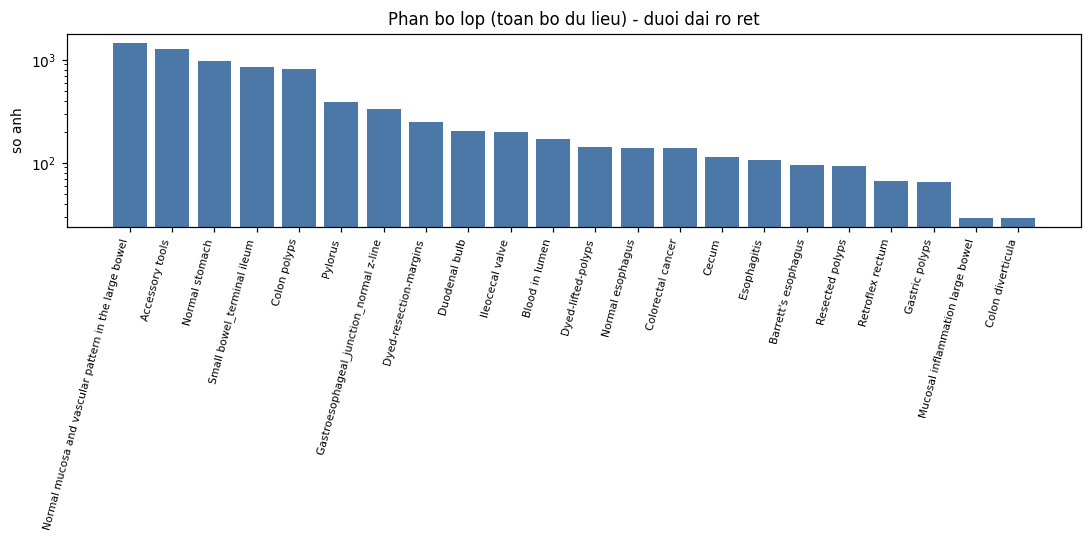

                                                  lop  tong  train  val  test
Normal mucosa and vascular pattern in the large bowel  1467    880  293   294
                                      Accessory tools  1266    760  253   253
                                       Normal stomach   969    581  194   194
                           Small bowel_terminal ileum   846    508  169   169
                                         Colon polyps   820    492  164   164
                                              Pylorus   393    236   78    79
              Gastroesophageal_junction_normal z-line   330    198   66    66
                               Dyed-resection-margins   246    148   49    49
                                        Duodenal bulb   205    123   41    41
                                      Ileocecal valve   200    120   40    40
                                       Blood in lumen   171    103   34    34
                                   Dyed-lifted-polyps   141     

In [11]:
cnt_full = np.bincount(labels, minlength=NUM_CLASSES)
order = np.argsort(-cnt_full)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(NUM_CLASSES), cnt_full[order], color="#4C78A8")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([CLASSES[i] for i in order], rotation=75, ha="right", fontsize=7)
ax.set_ylabel("so anh"); ax.set_title("Phan bo lop (toan bo du lieu) - duoi dai ro ret")
ax.set_yscale("log")
plt.tight_layout(); plt.savefig(OUTPUT_DIR / "eda_class_distribution.png", dpi=130); plt.show()

eda = pd.DataFrame({
    "lop": [CLASSES[i] for i in order],
    "tong": cnt_full[order],
    "train": [int((labels[FULL_SPLIT['train']] == i).sum()) for i in order],
    "val":   [int((labels[FULL_SPLIT['val']] == i).sum()) for i in order],
    "test":  [int((labels[FULL_SPLIT['test']] == i).sum()) for i in order],
})
print(eda.to_string(index=False))
print(f"\nTy le mat can bang (lop lon nhat / nho nhat): {cnt_full.max() / cnt_full.min():.1f}x")
print(f"So lop co < 10 anh TEST: {(eda['test'] < 10).sum()} / {NUM_CLASSES}")
print("\n-> Day chinh la ly do macro-F1 rat nhieu: mot lop hiem chi co vai anh test,")
print("   doan dung them 1 anh la F1 cua lop do nhay ~0.15, keo ca trung binh 22 lop.")

---
## 8. Audit rò rỉ dữ liệu giữa 3 tập

Dữ liệu nội soi rất dễ chứa **nhiều khung hình của cùng một ca bệnh**. Nếu hai khung gần như giống nhau
rơi vào train và test thì mọi con số — kể cả 0,6504 của bài báo — đều bị thổi phồng.

Hai lớp kiểm tra:
1. **Trùng byte** — băm MD5 toàn bộ file. Rẻ, chạy trên **toàn bộ** dữ liệu ở mọi hồ sơ.
2. **Gần trùng** — cosine trên embedding của một mạng đã pretrain. Ở `cpu-smoke` giới hạn số ảnh cho nhanh.

Tìm ra rò rỉ → đó là đóng góp mạnh nhất của phần Dữ liệu. Không tìm ra → báo cáo vẫn được quyền viết câu
*"đã kiểm tra rò rỉ, không phát hiện"*, và đó là câu người chấm hỏi đầu tiên.

In [12]:
# --- Lop 1: trung byte (MD5) ---
def md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()


split_of = {}
for name, ids in FULL_SPLIT.items():
    for i in ids:
        split_of[i] = name

t0 = time.time()
by_hash = collections.defaultdict(list)
for i, (p, y) in enumerate(samples):
    by_hash[md5(p)].append(i)

dup_groups = {h: v for h, v in by_hash.items() if len(v) > 1}
cross = [v for v in dup_groups.values() if len({split_of[i] for i in v}) > 1]
n_dup_imgs = sum(len(v) for v in dup_groups.values())

print(f"MD5 tren {len(samples)} anh trong {time.time() - t0:.0f}s")
print(f"  nhom trung byte          : {len(dup_groups)}  ({n_dup_imgs} anh)")
print(f"  nhom VAT QUA cac tap chia: {len(cross)}   <-- day moi la ro ri that su")
for v in cross[:5]:
    print("   *", [(split_of[i], CLASSES[labels[i]], Path(samples[i][0]).name) for i in v])
MD5_LEAK = len(cross)

MD5 tren 7930 anh trong 67s
  nhom trung byte          : 1  (2 anh)
  nhom VAT QUA cac tap chia: 1   <-- day moi la ro ri that su
   * [('val', 'Colon polyps', 'ba615bcd-2f99-4a12-884d-d9cd2c04c2a1.jpg'), ('train', 'Colon polyps', 'ckda1fpc5000l3a5s17a45xql.jpg')]


In [13]:
# --- Lop 2: gan trung (cosine tren embedding da pretrain) ---
# Dung MobileNetV3-Small: du tot de do "giong nhau", va re gap nhieu lan DenseNet tren CPU.
AUDIT_SIZE, AUDIT_TH = 160, 0.98

_emb_net = tv.models.mobilenet_v3_small(weights=tv.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
_emb_net.classifier = nn.Identity()
_emb_net = _emb_net.eval().to(DEVICE)

_emb_tf = transforms.Compose([
    transforms.Resize((AUDIT_SIZE, AUDIT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

audit_ids = np.arange(len(samples))
if CFG["audit_cap"] and len(audit_ids) > CFG["audit_cap"]:
    audit_ids = np.random.default_rng(0).choice(audit_ids, CFG["audit_cap"], replace=False)
    audit_ids.sort()
    print(f"[{PROFILE}] gioi han audit gan-trung o {len(audit_ids)} anh (chay that se lam toan bo)")


@torch.no_grad()
def embed(ids, bs=64):
    out = []
    for s in range(0, len(ids), bs):
        batch = torch.stack([_emb_tf(Image.open(samples[i][0]).convert("RGB"))
                             for i in ids[s:s + bs]]).to(DEVICE)
        out.append(F.normalize(_emb_net(batch), dim=1).cpu())
    return torch.cat(out)


t0 = time.time()
E = embed(audit_ids)
print(f"embedding {len(audit_ids)} anh trong {time.time() - t0:.0f}s  -> shape {tuple(E.shape)}")

# Nhan ma tran theo khoi de khong no bo nho khi chay toan bo ~8000 anh.
near, BS = [], 512
for s in range(0, len(E), BS):
    sim = E[s:s + BS] @ E.T
    for r in range(sim.shape[0]):
        i_global = s + r
        sim[r, :i_global + 1] = -1                       # chi lay nua tren, bo duong cheo
        hits = torch.nonzero(sim[r] >= AUDIT_TH).flatten().tolist()
        for j in hits:
            a, b = audit_ids[i_global], audit_ids[j]
            if split_of[a] != split_of[b]:
                near.append((a, b, float(sim[r, j])))

print(f"\nCap GAN TRUNG (cosine >= {AUDIT_TH}) nam o HAI tap khac nhau: {len(near)}")
for a, b, s in sorted(near, key=lambda x: -x[2])[:5]:
    print(f"   {s:.4f}  {split_of[a]}/{CLASSES[labels[a]]}/{Path(samples[a][0]).name}"
          f"   <->   {split_of[b]}/{CLASSES[labels[b]]}/{Path(samples[b][0]).name}")

NEAR_LEAK = len(near)

# Dem cap khong chi de bao "co ro ri" ma con de tra loi cau hoi nguoi cham chac chan se hoi:
# ro ri do lam sai lech con so test bao nhieu?
LEAK_TEST_IDS = sorted({i for a, b, _ in near for i in (a, b) if split_of[i] == "test"}
                       | {i for v in cross for i in v if split_of[i] == "test"})
n_test_full = len(FULL_SPLIT["test"])
# Cap gan trung NHUNG KHAC NHAN khong phai ro ri ma la NHIEU NHAN cua bo du lieu: cung mot khung
# hinh duoc gan hai ten benh khac nhau -> khong mo hinh nao co the dung ca hai. Day la mot phat
# hien ve chat luong du lieu, dang mot doan trong bao cao.
mislabel = [(a, b, sc) for a, b, sc in near if labels[a] != labels[b]]

print("\n=== KET LUAN AUDIT ===")
print(f"trung byte vat qua cac tap : {MD5_LEAK}")
print(f"gan trung vat qua cac tap  : {NEAR_LEAK} (nguong {AUDIT_TH}"
      f"{', tren tap con' if CFG['audit_cap'] else ', toan bo du lieu'})")
print(f"anh TEST bi anh huong      : {len(LEAK_TEST_IDS)} / {n_test_full} "
      f"= {100 * len(LEAK_TEST_IDS) / max(1, n_test_full):.2f}%  (muc 19b tinh lai macro-F1 khi bo chung)")
print(f"cap gan trung KHAC NHAN    : {len(mislabel)}  <-- nhieu nhan cua bo du lieu, khong phai ro ri")
for a, b, sc in sorted(mislabel, key=lambda x: -x[2])[:3]:
    print(f"   {sc:.4f}  {CLASSES[labels[a]]} ({split_of[a]})  vs  {CLASSES[labels[b]]} ({split_of[b]})")
del _emb_net

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 89.3MB/s]


embedding 7930 anh trong 79s  -> shape (7930, 576)

Cap GAN TRUNG (cosine >= 0.98) nam o HAI tap khac nhau: 9
   1.0000  val/Colon polyps/ba615bcd-2f99-4a12-884d-d9cd2c04c2a1.jpg   <->   train/Colon polyps/ckda1fpc5000l3a5s17a45xql.jpg
   1.0000  val/Esophagitis/N2DaTmFs.jpg   <->   test/Normal esophagus/WdSYgDiw.jpg
   0.9998  test/Gastroesophageal_junction_normal z-line/02a7a210-f047-4852-94f9-b0d844a131d7.jpg   <->   val/Gastroesophageal_junction_normal z-line/asUGeYOA.jpg
   0.9998  train/Accessory tools/ckcbq0gs703hv0y4h735ha581.jpg   <->   val/Gastric polyps/8f5dae06-df66-49e5-8a07-8447daf122e7.jpg
   0.9995  train/Pylorus/04c2bbc5-1ffe-4014-91bc-eabb9295af48.jpg   <->   test/Pylorus/pT8eFgiY.jpg

=== KET LUAN AUDIT ===
trung byte vat qua cac tap : 1
gan trung vat qua cac tap  : 9 (nguong 0.98, toan bo du lieu)
anh TEST bi anh huong      : 6 / 1586 = 0.38%  (muc 19b tinh lai macro-F1 khi bo chung)
cap gan trung KHAC NHAN    : 2  <-- nhieu nhan cua bo du lieu, khong phai ro ri
   

---
## 9. Dataset, phép biến đổi ảnh và bộ nạp dữ liệu

Augment được chọn **theo miền nội soi**, không phải bê nguyên công thức ImageNet:

* **Lật ngang** — hợp lệ: ảnh nội soi không có chiều trái/phải cố định.
* **Không lật dọc** — nội soi có hướng (trên/dưới), lật dọc tạo ảnh không tồn tại trong thực tế.
* **Xoay ≤ 10°, jitter màu nhẹ** — mô phỏng rung tay và khác biệt nguồn sáng giữa các máy nội soi.
* **Không augment mạnh** ở **bốn cấu hình chính** `B0`/`S0`/`P0`/`P1`. Cấu hình duy nhất từng dùng
  nó — `B2` của vòng thí nghiệm đầu, `RESULTS.md` §6 — tụt **−0,035**, nhưng chính `RESULTS.md` quy
  nguyên nhân cho **công thức bị under-train** (LR backbone thấp gấp 10 lần), *không* cho bản thân
  augment. Vậy câu đúng để viết vào báo cáo là **"chưa đo được lợi ích, và lần thử duy nhất bị hỏng
  vì một lỗi tinh chỉnh"** — không phải *"augment mạnh làm hỏng kết quả"*.
  `train_tf_strong` / `use_aug(True)` vẫn nằm trong code làm định nghĩa của điều kiện đó, nhưng
  **không lần chạy nào trong bốn cấu hình chính gọi tới**.
* **Ngoại lệ: `train_tf_modern` / `use_aug("modern")`** — chỉ dùng cho bậc `P2` ở **mục 15c**, và nó
  khác `train_tf_strong` ở đúng một chỗ có ý nghĩa: **có `RandomResizedCrop`**. Nghĩa là phép augment
  quan trọng nhất cho dữ liệu nhỏ — biến đổi **tỷ lệ** — chưa từng được bật trong bất kỳ lần chạy
  nào trước đó, kể cả ở `B2`. Đó là lý do câu *"augment mạnh đã thử rồi"* không bao trùm `P2`.

In [14]:
IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]


def build_transforms(sz):
    plain = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    strong = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(0.15, 0.15, 0.15, 0.0),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.1),
    ])
    ev = transforms.Compose([
        transforms.Resize((sz, sz)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    return plain, strong, ev


def build_modern_tf(sz):
    '''Augment cua cong thuc P2 (muc 15c).

    NGUON Y TUONG: cong thuc huan luyen "hien dai" chuan cua timm -- Wightman, Touvron & Jegou,
    "ResNet strikes back" (arXiv 2110.00476), va cong thuc DeiT cho du lieu nho (arXiv 2012.12877).
    Y chinh cua ca hai: phan lon khoang cach giua mot kien truc cu va mot kien truc moi hoa ra la
    khoang cach giua hai CONG THUC HUAN LUYEN, khong phai giua hai kien truc.

    KHAC VOI train_tf_strong (cua B2) o dung mot cho quan trong: co RandomResizedCrop. B2 chi
    Resize co dinh + xoay + jitter, tuc khong he co bien doi TY LE. Day la phep augment ma
    mot backbone du lieu nho can nhat, va cung la phep duy nhat B2 bo sot.

    Bien the RIENG cho anh noi soi (khong bung nguyen cong thuc ImageNet):
      * scale=(0.65, 1.0) chu khong phai (0.08, 1.0) nhu ImageNet -- anh noi soi co vien den hinh
        tron, cat qua manh se roi vao vung den khong mang thong tin.
      * ratio hep (0.85-1.18) -- giu hinh dang ton thuong, khong keo gian phi sinh ly.
      * KHONG lat doc, khong RandAugment day du: giu dung ky luat da ghi o muc 9.
    '''
    modern = transforms.Compose([
        transforms.RandomResizedCrop(sz, scale=(0.65, 1.0), ratio=(0.85, 1.18)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.02),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
    ])
    return modern


train_tf_plain, train_tf_strong, eval_tf = build_transforms(IMG_SIZE)
train_tf_modern = build_modern_tf(IMG_SIZE)
train_tf = train_tf_plain


def set_img_size(sz):
    '''Doi do phan giai dau vao. make_loaders() doc bien toan cuc luc goi -> goi TRUOC run_seeds.'''
    global IMG_SIZE, train_tf, train_tf_plain, train_tf_strong, train_tf_modern, eval_tf
    IMG_SIZE = sz
    train_tf_plain, train_tf_strong, eval_tf = build_transforms(sz)
    train_tf_modern = build_modern_tf(sz)
    train_tf = train_tf_plain
    print(f"IMG_SIZE -> {sz} (dung augment 'plain')")


def use_aug(mode=True):
    '''mode: False -> plain (B0/S0/P0/P1) | True -> strong (dinh nghia cua B2) | "modern" -> P2.'''
    global train_tf
    name = {False: "plain", True: "strong", "modern": "modern"}[mode]
    train_tf = {"plain": train_tf_plain, "strong": train_tf_strong,
                "modern": train_tf_modern}[name]
    print("augment ->", name)


class GastroDataset(Dataset):
    def __init__(self, indices, transform):
        self.items = [samples[i] for i in indices]
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        path, y = self.items[i]
        return self.transform(Image.open(path).convert("RGB")), y


def make_loaders(batch=None):
    '''generator + worker_init_fn: khong co chung thi thu tu tron va RNG cua worker khong bam theo
    seed -> hai lan chay "cung seed" van lech nhau. Nho goi set_seed() truoc.'''
    b = batch or BATCH_SIZE
    common = dict(batch_size=b, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                  worker_init_fn=seed_worker)
    tr = DataLoader(GastroDataset(train_idx, train_tf), shuffle=True, generator=DATA_GEN, **common)
    va = DataLoader(GastroDataset(val_idx, eval_tf), shuffle=False, **common)
    te = DataLoader(GastroDataset(test_idx, eval_tf), shuffle=False, **common)
    return tr, va, te


print("so anh:", len(train_idx), len(val_idx), len(test_idx), "| IMG_SIZE =", IMG_SIZE)

so anh: 4758 1586 1586 | IMG_SIZE = 224


---
## 10. Bộ đánh giá dùng chung

Mọi kiến trúc đều đi qua **đúng những hàm này** — đó là điều khiến so sánh CNN vs Transformer vs Hybrid
có giá trị.

Điểm mấu chốt của thiết kế: `evaluate()` trả về **logits**, không chỉ nhãn dự đoán.
Nhờ đó những thứ sau **không tốn thêm một epoch nào**:

* khoảng tin cậy bootstrap,
* ensemble nhiều checkpoint / nhiều seed / nhiều kiến trúc,
* hiệu chỉnh logit theo tần suất lớp (`logit adjustment`) — dò tham số τ trên tập val,
* đổi quy tắc chọn checkpoint sau khi đã train xong.

In [15]:
ALL_LABELS = list(range(NUM_CLASSES))


def macro_f1(y_true, y_pred, labels=None):
    '''labels=None -> 22 lop cua GastroVision (mac dinh, dung cho MOI con so bao cao).
    Chi truyen labels khac khi cham mot bai toan khac -- vi du giai doan pretrain 23 lop
    HyperKvasir o muc 15e; neu de mac dinh thi no se trung binh tren nham tap lop.'''
    return f1_score(y_true, y_pred, labels=labels or ALL_LABELS,
                    average="macro", zero_division=0)


def softmax_np(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


@torch.no_grad()
def evaluate(model, loader, tta=False, labels=None):
    '''Tra ve macro-F1, micro-F1, nhan that, nhan doan VA logits (float32).

    labels: chi truyen khi cham mot bai toan KHAC 22 lop GastroVision (muc 15e).'''
    model.eval()
    ys, ls = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
            out = model(x).float()
            if tta:                                   # TTA = trung binh voi anh lat ngang
                out = (out + model(torch.flip(x, dims=[3])).float()) / 2
        ls.append(out.cpu().numpy()); ys.append(y.numpy())
    logits = np.concatenate(ls).astype(np.float32)
    y_true = np.concatenate(ys)
    y_pred = logits.argmax(1)
    lab = labels or ALL_LABELS
    return dict(macro_f1=macro_f1(y_true, y_pred, lab),
                micro_f1=f1_score(y_true, y_pred, labels=lab, average="micro", zero_division=0),
                y_true=y_true, y_pred=y_pred, logits=logits)


def report_per_class(res, title=""):
    print(f"--- F1 tung lop {title} ---")
    print(classification_report(res["y_true"], res["y_pred"], labels=ALL_LABELS,
                                target_names=CLASSES, zero_division=0, digits=3))


def plot_confusion(res, title="", fname=None):
    cm = confusion_matrix(res["y_true"], res["y_pred"], labels=ALL_LABELS)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    plt.xlabel("du doan"); plt.ylabel("that"); plt.title(f"Ma tran nham lan {title}")
    plt.xticks(rotation=75, ha="right", fontsize=6); plt.yticks(fontsize=6)
    plt.tight_layout()
    if fname:
        plt.savefig(OUTPUT_DIR / fname, dpi=130)
    plt.show()


def bootstrap_ci(y_true, y_pred, n_boot=1000, alpha=0.05, seed=0, verbose=True):
    '''Khoang tin cay 95% cho macro-F1 bang cach lay lai mau anh test co hoan lai. 0 epoch.'''
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rng = np.random.default_rng(seed)
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        i = rng.integers(0, n, n)
        # Chi trung binh tren cac lop CO MAT trong mau lay lai. Neu ep labels=ALL_LABELS thi mot lop
        # hiem (~6 anh test) vang mat se bi tinh F1=0 va keo trung binh xuong ~1/22 -- do la loi cua
        # phep lay mau, khong phai cua mo hinh.
        present = np.unique(y_true[i])
        stats.append(f1_score(y_true[i], y_pred[i], labels=present, average="macro", zero_division=0))
    lo, hi = np.percentile(stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    point = macro_f1(y_true, y_pred)
    if verbose:
        print(f"macro-F1 = {point:.4f}   CI 95% [{lo:.4f}, {hi:.4f}]")
    return dict(point=float(point), lo=float(lo), hi=float(hi))


def ensemble_logits(list_of_logits, weights=None):
    '''Trung binh XAC SUAT (softmax) chu khong phai logits tho: cac kien truc khac nhau co thang
    logit khac nhau, cong thang se de mo hinh "tu tin" nhat lan at.'''
    probs = [softmax_np(l) for l in list_of_logits]
    w = np.ones(len(probs)) if weights is None else np.asarray(weights, dtype=float)
    w = w / w.sum()
    return sum(wi * p for wi, p in zip(w, probs))


def logit_adjust(logits, counts=None, tau=1.0):
    '''Hieu chinh logit theo tan suat lop (Menon et al. 2021): tru di tau*log(prior).
    Ap luc SUY LUAN nen khong ton epoch nao -- doi lap voi Balanced-Softmax (luc huan luyen).'''
    counts = TRAIN_CLASS_COUNTS if counts is None else counts
    prior = np.asarray(counts, dtype=np.float64)
    prior = prior / prior.sum()
    return logits - tau * np.log(prior + 1e-12)[None, :]


def tune_tau(val_logits, val_y, taus=np.arange(0.0, 1.01, 0.1)):
    '''Do tau tren tap VAL (khong bao gio tren test) roi tra ve tau tot nhat.'''
    scores = [(float(t), macro_f1(val_y, logit_adjust(val_logits, tau=t).argmax(1))) for t in taus]
    best = max(scores, key=lambda x: x[1])
    return best[0], scores


print("bo danh gia san sang | so lop =", NUM_CLASSES)

bo danh gia san sang | so lop = 22


---
## 11. Vòng huấn luyện — và cách chống nhiễu khi chọn checkpoint

`train_one` giữ **ba ứng viên checkpoint trong cùng một lần chạy**:

| Quy tắc | Nội dung | Vì sao có mặt |
| --- | --- | --- |
| `best` | trạng thái có val macro-F1 cao nhất | quy tắc cũ, giữ để so sánh |
| `smooth` | trạng thái tại đỉnh của **trung bình trượt 3 epoch** của val | val quá nhỏ nên một đỉnh đơn lẻ thường là may mắn |
| `top3` | **ensemble xác suất của 3 checkpoint val tốt nhất** | giảm phương sai — đúng bệnh của bài này |

Cả ba đều tính được từ **một** lần huấn luyện, nên việc chọn quy tắc nào **không tốn thêm GPU**.
Đây chính là hạng mục 3a + 3b trong Gate 0 của `README.md`.

In [16]:
class Tracker:
    '''Ghi lai lich su val + giu cac trang thai can thiet cho 3 quy tac chon checkpoint.'''

    def __init__(self, keep_top_k=KEEP_TOP_K, smooth_win=SMOOTH_WIN):
        self.keep_top_k, self.smooth_win = keep_top_k, smooth_win
        self.history, self.top = [], []
        self.smooth = (-1.0, -1, None)

    def update(self, model, vf1, ep):
        self.history.append(float(vf1))
        state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        self.top.append((float(vf1), ep, state))
        self.top.sort(key=lambda t: -t[0])
        del self.top[self.keep_top_k:]
        sm = float(np.mean(self.history[-self.smooth_win:]))
        if sm > self.smooth[0]:
            self.smooth = (sm, ep, state)

    def finalize(self, model):
        model.load_state_dict(self.top[0][2])
        return dict(best_val=self.top[0][0], best_epoch=self.top[0][1],
                    history=self.history, top=self.top, smooth=self.smooth)


def train_one(model, tr, va, epochs=None, lr=1e-4, criterion=None, class_weights=None,
              freeze_bn=False, verbose=True):
    '''Fine-tune don gian (AdamW + AMP). Day la cong thuc chuan cua ca 4 cau hinh chinh
    (B0/S0/P0/P1); so cu the xem bang o muc 16 va 19.
    freeze_bn=True: moi lop BatchNorm nam trong phan DA DONG BANG duoc dua ve che do eval
    (chi can khi lam linear probe / dong bang mot phan -- xem _freeze_bn_of_frozen_part).'''
    epochs = epochs or EPOCHS
    crit = criterion if criterion is not None else nn.CrossEntropyLoss(weight=class_weights)
    # Loc theo requires_grad: khi backbone bi dong bang thi AdamW khong nen giu state cho chung.
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=1e-4)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_SCALER)
    tk, dt = Tracker(), float("nan")
    for ep in range(epochs):
        model.train()
        if freeze_bn:
            _freeze_bn_of_frozen_part(model)
        t0 = time.time()
        for x, y in tr:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        dt = time.time() - t0
        vf1 = evaluate(model, va)["macro_f1"]
        tk.update(model, vf1, ep)
        if verbose:
            print(f"  ep {ep + 1:02d}/{epochs}  val_macroF1={vf1:.4f}  "
                  f"(best={tk.top[0][0]:.4f})  {dt:.0f}s/epoch")
    out = tk.finalize(model)
    out["sec_per_epoch"] = dt
    return out


def _head_attr(model):
    for a in ("fc", "classifier", "head"):
        if hasattr(model, a):
            return a
    raise AttributeError("khong tim thay lop phan loai cuoi cung")


def train_advanced(model, tr, va, criterion=None, probe_epochs=3, epochs=None, base_lr=1e-4,
                   backbone_mult=0.5, weight_decay=1e-4, warmup_epochs=2, label_smoothing=0.05,
                   verbose=True):
    '''Cong thuc 2 giai doan: linear probe -> fine-tune toan mang, LR phan biet + cosine warmup.
    LUU Y: da do va THUA baseline don gian (B2 = -0,035) khi backbone_mult=0.1. Giu lai de lam
    phan "transfer learning" cua bao cao, khong phai de chay mac dinh.'''
    epochs = epochs or EPOCHS
    crit = criterion if criterion is not None else nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    head = _head_attr(model)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_SCALER)
    tk = Tracker()

    def run(opt, sched, n, name, ep0):
        for ep in range(n):
            model.train()
            # Khong lam gi khi ca mang deu trainable (giai doan ft); chi co tac dung o giai doan
            # probe, luc backbone dang bi dong bang -> giu BatchNorm khong troi theo du lieu moi.
            _freeze_bn_of_frozen_part(model)
            for x, y in tr:
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
                    loss = crit(model(x), y)
                scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            if sched is not None:
                sched.step()
            vf1 = evaluate(model, va)["macro_f1"]
            tk.update(model, vf1, ep0 + ep)
            if verbose:
                print(f"  {name} ep {ep + 1:02d}/{n}  val_macroF1={vf1:.4f}  (best={tk.top[0][0]:.4f})")

    if probe_epochs > 0:
        for p in model.parameters():
            p.requires_grad = False
        for p in getattr(model, head).parameters():
            p.requires_grad = True
        opt = torch.optim.AdamW(getattr(model, head).parameters(), lr=1e-3, weight_decay=weight_decay)
        run(opt, None, probe_epochs, "probe", 0)
        for p in model.parameters():
            p.requires_grad = True

    head_params = set(getattr(model, head).parameters())
    backbone = [p for p in model.parameters() if p not in head_params]
    opt = torch.optim.AdamW([{"params": backbone, "lr": base_lr * backbone_mult},
                             {"params": list(head_params), "lr": base_lr}], weight_decay=weight_decay)

    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / max(1, warmup_epochs)
        p = (ep - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * p))

    run(opt, torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda), epochs, "ft", probe_epochs)
    out = tk.finalize(model)
    out["sec_per_epoch"] = float("nan")
    return out


# ==================== P2: cong thuc huan luyen hien dai (muc 15c) ====================
# NGUON CUA TUNG THANH PHAN -- de nguoi doc bao cao truy nguoc duoc, va de chinh minh khong
# nham "y tuong tu nghi ra" voi "y tuong doc duoc o dau do":
#
#   | Thanh phan            | Lay tu dau                                                        |
#   |-----------------------|-------------------------------------------------------------------|
#   | Y tuong tong the      | Wightman et al., "ResNet strikes back" (arXiv 2110.00476): doi     |
#   |                       | cong thuc huan luyen an nhieu hon doi kien truc. Khop voi do thi   |
#   |                       | do duoc cua CHINH DU AN (RESULTS.md muc 9): don bay quy tac        |
#   |                       | checkpoint (+0,018..+0,032) ngang don bay doi kien truc (+0,014).  |
#   | cosine + warmup       | Loshchilov & Hutter, SGDR (arXiv 1608.03983); warmup tu Goyal      |
#   |                       | et al. (arXiv 1706.02677). Da co san trong train_advanced.         |
#   | LLRD (layer decay)    | Howard & Ruder, ULMFiT (arXiv 1801.06146) - discriminative         |
#   |                       | fine-tuning. RESULTS.md muc 19d da tu ghi nhan diem yeu: T3 chi la |
#   |                       | LLRD 2 NHOM, khong phai theo tung tang. Day la cho vá lai.         |
#   | mixup                 | Zhang et al. (arXiv 1710.09412)                                    |
#   | cutmix                | Yun et al. (arXiv 1905.04899)                                      |
#   | label smoothing 0,1   | Szegedy et al. (arXiv 1512.00567); Muller et al. (arXiv 1906.02629)|
#   | AdamW + wd 0,05       | Loshchilov & Hutter (arXiv 1711.05101); muc wd 0,05 lay tu cong    |
#   |                       | thuc DeiT (arXiv 2012.12877) cho du lieu nho.                      |
#   | EMA trong so          | Polyak averaging; Mean Teacher (arXiv 1703.01780); ban cai dat     |
#   |                       | theo timm ModelEmaV2. NHUNG decay thi KHONG lay so cua timm       |
#   |                       | (0,9998 -- do la cho ImageNet, hang nghin buoc/epoch): o day chi   |
#   |                       | ~149 buoc/epoch nen decay duoc SUY RA de cua so ~5 epoch.         |
#   | 80 epoch (khong 30)   | DO DUOC TAI CHO: report/tables/24_duong_hoc_val.txt -- P1 dat dinh |
#   |                       | val o epoch 27/30, do lech 5 epoch cuoi chi 0,0021 => chua hoi tu, |
#   |                       | bi cat ngan boi ngan sach chu khong phai da het hoc.               |
#
# VI SAO EMA quan trong hon ve mat CHI PHI chu khong chi diem so: top3_tta dang lay
# 3 checkpoint x 2 lat = 6 luot suy luan moi anh (RESULTS.md muc 20). EMA cho cung loai loi ich
# (giam phuong sai, lam min quy dao trong so) trong MOT bo trong so duy nhat. Neu EMA giu duoc
# phan lon muc tang do thi chi phi suy luan giam 6 lan -- day la mot ket qua dang bao cao rieng.


def _one_hot(y, nc, smoothing=0.0):
    off = smoothing / nc
    t = torch.full((y.size(0), nc), off, device=y.device, dtype=torch.float32)
    return t.scatter_(1, y.unsqueeze(1), 1.0 - smoothing + off)


def mixup_cutmix(x, y, num_classes, alpha_mix=0.2, alpha_cut=1.0, prob=0.5,
                 switch_prob=0.5, smoothing=0.1):
    '''Tra ve (anh da tron, nhan MEM). Khi khong tron van tra nhan mem -> mot duong code duy nhat.

    Luu y ve tinh lap lai: np.random / torch RNG deu da duoc set_seed() gieo hat, va phep tron
    chay o TIEN TRINH CHINH (khong phai trong worker), nen khong pha tinh tat dinh cua Gate 0a.'''
    t = _one_hot(y, num_classes, smoothing)
    if prob <= 0 or float(torch.rand(1)) >= prob:
        return x, t
    idx = torch.randperm(x.size(0), device=x.device)
    if float(torch.rand(1)) < switch_prob:                      # --- CutMix ---
        lam = float(np.random.beta(alpha_cut, alpha_cut))
        h, w = x.shape[-2:]
        cut = math.sqrt(1.0 - lam)
        ch, cw = int(h * cut), int(w * cut)
        cy, cx = int(torch.randint(0, h, (1,))), int(torch.randint(0, w, (1,)))
        y1, y2 = max(cy - ch // 2, 0), min(cy + ch // 2, h)
        x1, x2 = max(cx - cw // 2, 0), min(cx + cw // 2, w)
        x = x.clone()
        x[:, :, y1:y2, x1:x2] = x[idx][:, :, y1:y2, x1:x2]
        # lam phai tinh lai theo dien tich THUC SU bi cat (o bien, hop bi xen) -- neu dung lam
        # ban dau thi nhan va anh lech nhau, mot loi rat de bo qua.
        lam = 1.0 - ((y2 - y1) * (x2 - x1) / float(h * w))
    else:                                                        # --- Mixup ---
        lam = float(np.random.beta(alpha_mix, alpha_mix))
        x = lam * x + (1.0 - lam) * x[idx]
    return x, lam * t + (1.0 - lam) * t[idx]


def soft_target_ce(logits, target):
    '''Cross-entropy voi nhan mem -- bat buoc khi dung mixup/cutmix + label smoothing.'''
    return torch.sum(-target * F.log_softmax(logits, dim=-1), dim=-1).mean()


class ModelEma(nn.Module):
    '''Trung binh truot mu cua trong so (theo timm ModelEmaV2).

    warmup: nhung buoc dau EMA gan nhu bang trong so goc, neu khong no se keo dai giai doan
    "chua hoc duoc gi" va val cua EMA se te suot chuc epoch dau.'''

    def __init__(self, model, decay=0.9998, warmup=True):
        super().__init__()
        self.module = copy.deepcopy(model).eval()
        for p in self.module.parameters():
            p.requires_grad_(False)
        self.decay, self.warmup, self.n = decay, warmup, 0

    @torch.no_grad()
    def update(self, model):
        self.n += 1
        d = min(self.decay, (1 + self.n) / (10 + self.n)) if self.warmup else self.decay
        for ev, mv in zip(self.module.state_dict().values(), model.state_dict().values()):
            if ev.is_floating_point():
                ev.mul_(d).add_(mv.detach().to(ev.device), alpha=1.0 - d)
            else:
                ev.copy_(mv)          # num_batches_tracked va cac buffer nguyen -> chep thang

    def forward(self, x):
        return self.module(x)


def param_groups_llrd(model, base_lr, weight_decay=0.05, layer_decay=0.75, n_buckets=12):
    '''LR giam dan theo do sau: tang cang gan dau vao thi LR cang nho.

    GIOI HAN PHAI NOI RO TRONG BAO CAO: day la xap xi theo VI TRI tham so trong
    model.named_parameters() chia thanh n_buckets, khong phai do sau tang that su. Voi
    DenseNet-121 / Swin-T / CoAtNet-0 thu tu khai bao module trung voi thu tu do sau nen xap xi
    nay dung; voi mot kien truc khai bao lung tung thi khong. Ban "dung bai" cho model timm la
    timm.optim.param_groups_layer_decay() (dua vao model.group_matcher), nhung DenseNet-121 lay
    tu torchvision nen khong co group_matcher -> chon ban xap xi de CA BA kien truc dung chung
    mot ham, vi so sanh cong bang quan trong hon do tinh vi.

    weight decay = 0 cho bias va tham so 1 chieu (norm) -- quy uoc chuan, quan trong khi wd=0,05.
    '''
    head = _head_attr(model)
    head_ids = {id(p) for p in getattr(model, head).parameters()}
    body = [(n, p) for n, p in model.named_parameters()
            if id(p) not in head_ids and p.requires_grad]
    nb, groups = max(1, n_buckets), []
    for i, (n, p) in enumerate(body):
        b = min(nb - 1, int(i * nb / max(1, len(body))))
        groups.append({"params": [p], "lr": base_lr * (layer_decay ** (nb - 1 - b)),
                       "weight_decay": 0.0 if p.ndim <= 1 else weight_decay})
    for n, p in getattr(model, head).named_parameters():
        if p.requires_grad:
            groups.append({"params": [p], "lr": base_lr,
                           "weight_decay": 0.0 if p.ndim <= 1 else weight_decay})
    return groups


def train_modern(model, tr, va, epochs=None, base_lr=3e-4, weight_decay=0.05, layer_decay=0.75,
                 warmup_epochs=5, label_smoothing=0.1, mixup_prob=0.5, ema_decay=None,
                 ema_window_epochs=5, track="ema", num_classes=None, verbose=True):
    '''Cong thuc P2. Van tra ve dung dinh dang cua Tracker -> cam thang vao run_seeds va
    huong nguyen bo may 6-quy-tac / bootstrap / resume co san, khong sua gi phia sau.

    track="ema": Tracker giu trang thai cua EMA (day la thu se duoc cham diem tren test).
    track="raw": giu trang thai goc -- de lam ablation "EMA dong gop bao nhieu".'''
    epochs = epochs or EPOCHS
    # nc: mixup phai one-hot theo so lop cua BAI TOAN dang chay. Giai doan pretrain HyperKvasir
    # (muc 15e) co 23 lop, de mac dinh NUM_CLASSES=22 thi scatter_ se nem IndexError.
    nc = num_classes or NUM_CLASSES
    lab = list(range(nc))
    warmup_epochs = min(warmup_epochs, max(1, epochs // 10))

    # EMA decay KHONG duoc dat cung mot con so ma phai suy ra tu SO BUOC. Cua so nho cua EMA la
    # ~1/(1-decay) buoc; 0,9998 quen thuoc cua timm la cho ImageNet (hang nghin buoc moi epoch).
    # O day 4.758 anh / batch 32 = ~149 buoc/epoch, nen 0,9998 se cho cua so ~5.000 buoc = ~34
    # epoch, tuc EMA tre gan nua qua trinh huan luyen va se te hon trong so tho suot phan lon
    # thoi gian. Neo theo epoch thay vi theo con so: cua so = ema_window_epochs epoch.
    steps_per_epoch = max(1, len(tr))
    if ema_decay is None:
        ema_decay = 1.0 - 1.0 / (ema_window_epochs * steps_per_epoch)
    opt = torch.optim.AdamW(param_groups_llrd(model, base_lr, weight_decay, layer_decay))
    scaler = torch.amp.GradScaler("cuda", enabled=USE_SCALER)
    ema = ModelEma(model, decay=ema_decay) if track == "ema" else None
    tk, dt = Tracker(), float("nan")
    if verbose:
        print(f"  [cong thuc P2] {epochs} epoch | warmup {warmup_epochs} | LLRD {layer_decay} | "
              f"{steps_per_epoch} buoc/epoch | EMA decay {ema_decay:.6f} "
              f"(cua so ~{ema_window_epochs} epoch)")

    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / max(1, warmup_epochs)
        p = (ep - warmup_epochs) / max(1, epochs - warmup_epochs)
        return 0.5 * (1 + math.cos(math.pi * p))

    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

    for ep in range(epochs):
        model.train()
        t0 = time.time()
        for x, y in tr:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            x, soft_y = mixup_cutmix(x, y, nc, prob=mixup_prob, smoothing=label_smoothing)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
                loss = soft_target_ce(model(x), soft_y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            if ema is not None:
                ema.update(model)
        sched.step()
        dt = time.time() - t0

        vf1_raw = evaluate(model, va, labels=lab)["macro_f1"]
        if ema is not None:
            vf1_ema = evaluate(ema.module, va, labels=lab)["macro_f1"]
            tk.update(ema.module, vf1_ema, ep)
        else:
            vf1_ema = float("nan")
            tk.update(model, vf1_raw, ep)
        if verbose:
            print(f"  ep {ep + 1:02d}/{epochs}  val raw={vf1_raw:.4f}  ema={vf1_ema:.4f}  "
                  f"(best={tk.top[0][0]:.4f})  lr={opt.param_groups[-1]['lr']:.2e}  {dt:.0f}s/epoch")

    out = tk.finalize(model)
    out["sec_per_epoch"] = dt
    return out


# ==================== Transfer learning: freeze vs trainable ====================
# Muc 6 cua rubric trong de bai (10%) doi dung mot BANG SO SANH giua cac muc do dong bang.
# Ba ham duoi day tao ra ba dieu kien; dieu kien thu tu (fine-tune toan mang) chinh la B0.


def _freeze_bn_of_frozen_part(model):
    '''Dua moi lop BatchNorm nam trong phan da dong bang ve che do eval.

    Khong lam buoc nay thi 'linear probe' van chua thuc su dong bang: model.train() de BatchNorm
    tiep tuc cap nhat running mean/var theo du lieu noi soi, nen dac trung van dich chuyen qua tung
    epoch du khong co gradient nao chay vao backbone. Voi DenseNet-121 (dac ~120 lop BN) sai lech
    nay khong nho, va no lam mo dung thu ma muc nay muon do.
    '''
    n = 0
    for m in model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
            own = list(m.parameters(recurse=False))
            if own and all(not p.requires_grad for p in own):
                m.eval(); n += 1
    return n


def freeze_backbone(model, frac=1.0):
    '''Dong bang `frac` dau tien cua backbone (theo thu tu named_parameters, tuc theo do sau).

    frac=1.0 -> dong bang toan bo backbone (linear probe). frac=0.5 -> dong bang nua duoi.
    Lop phan loai cuoi LUON duoc hoc. Tra ve (so tham so hoc duoc, tong so tham so).
    LUU Y: thu tu named_parameters chi XAP XI thu tu do sau -- dung duoc cho DenseNet/timm o day,
    nhung day la mot xap xi va phai noi ro trong bao cao.
    '''
    head = _head_attr(model)
    head_ids = {id(p) for p in getattr(model, head).parameters()}
    body = [p for p in model.parameters() if id(p) not in head_ids]
    cut = int(round(len(body) * frac))
    for i, p in enumerate(body):
        p.requires_grad = i >= cut
    for p in getattr(model, head).parameters():
        p.requires_grad = True
    train_n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_n = sum(p.numel() for p in model.parameters())
    print(f"  dong bang {cut}/{len(body)} tensor cua backbone -> hoc "
          f"{train_n / 1e6:.2f}M / {total_n / 1e6:.2f}M tham so ({100 * train_n / total_n:.1f}%)")
    return train_n, total_n


def train_linear_probe(model, tr, va, lr=1e-3, **kw):
    '''T1 -- linear probe: dong bang TOAN BO backbone, chi hoc lop phan loai.

    LR cao hon (1e-3 thay vi 1e-4) vi chi con mot lop linear phai hoc; dung 1e-4 o day la
    tu lam yeu dieu kien nay roi so sanh khong cong bang.
    '''
    freeze_backbone(model, frac=1.0)
    return train_one(model, tr, va, lr=lr, freeze_bn=True, **kw)


def train_partial_unfreeze(model, tr, va, frac=0.5, lr=1e-4, **kw):
    '''T2 -- dong bang mot phan: giu nua duoi backbone, mo nua tren + lop phan loai.'''
    freeze_backbone(model, frac=frac)
    return train_one(model, tr, va, lr=lr, freeze_bn=True, **kw)


class BalancedSoftmaxLoss(nn.Module):
    '''Balanced Softmax (Ren et al. 2020): cong log(tan suat lop) vao logit luc HUAN LUYEN.
    DA DO TREN GASTROVISION: -0,007 so voi baseline -> phang. Giu lai lam ket qua am trong bao cao.'''

    def __init__(self, class_counts, label_smoothing=0.0):
        super().__init__()
        p = torch.tensor(np.asarray(class_counts, dtype=np.float32))
        self.register_buffer("log_prior", torch.log(p / p.sum() + 1e-12))
        self.ls = label_smoothing

    def forward(self, logits, target):
        return F.cross_entropy(logits + self.log_prior.to(logits.device), target,
                               label_smoothing=self.ls)


print("ham huan luyen san sang")

ham huan luyen san sang


---
## 12. Ba kiến trúc

| Vai trò | Mô hình | Nguồn trọng số | Yêu cầu đặt **trước** khi chạy |
| --- | --- | --- | --- |
| **Baseline tham chiếu** (bắt buộc) | DenseNet-121 | torchvision `IMAGENET1K_V1` | khớp **0,6504** của bài báo |
| **Baseline mới** (đóng góp của nhóm) | Swin-T | `timm` `swin_tiny_patch4_window7_224.ms_in1k` | bài báo không có số — "tái lập" nghĩa là **train đúng giao thức** |
| **Mô hình đề xuất** | CoAtNet-0 | `timm` `coatnet_0_rw_224.sw_in1k` | phải vượt **cả hai** dòng trên |

⚠️ **Cột cuối là kỳ vọng, không phải kết quả — và không kỳ vọng nào đạt theo cách đã dự đoán.** Đọc
bảng này rồi nhảy xuống bảng số là rất dễ tưởng cả ba yêu cầu đã đạt. Thực tế (số vòng T4, quy tắc
chốt `top3`):

* DenseNet-121 **tái lập được**: 0,6686 ± 0,0234 dưới quy tắc `best` — đúng giao thức bài báo — so
  với 0,6504, tức chênh +0,0182 = 0,78 σ.
* CoAtNet-0 **không** tách được khỏi Swin-T ở cùng 224: `P0` = 0,6814 so với `S0` = 0,6813, chênh
  0,0001. Thêm đòn bẩy độ phân giải thì `P1` @288 = 0,6855 — vẫn nằm trong σ của cả hai baseline.
* Và ngay cả `P1` cũng **không tách được** khỏi hai baseline về mặt thống kê ở 3 seed — CI bootstrap
  chồng lấn. Mục 21 mổ xẻ đúng chỗ này; đó là kết quả âm phải viết vào báo cáo, không phải chỗ để
  làm tròn lên.
* ⚠️ **Nên dòng "mô hình đề xuất" của bảng trên đã đổi nội dung:** không còn là CoAtNet-0 trần, mà
  là `P2` = CoAtNet-0 @288 **+ công thức huấn luyện hiện đại** (mục 15c). Chính công thức — chứ không
  phải kiến trúc hay độ phân giải — mới là đòn bẩy vượt ngưỡng phân giải của phép đo (`RESULTS.md`
  §10.9, §10.10). Bảng trên giữ nguyên vì nó ghi lại **kỳ vọng đặt trước khi chạy**, không phải kết quả.

**Swin-T dùng trọng số ImageNet-1k, không dùng in22k** ở dòng baseline: DenseNet-121 cũng là in1k,
đổi sang in22k là phá vỡ thế cân bằng khiến phép so sánh CNN vs Transformer mất giá trị.
Trọng số in22k được để dành làm **một dòng ablation riêng** (mục 19c) — ⚠️ ablation đó **mặc định
tắt và chưa từng chạy** trong bản notebook này, nên đừng đi tìm con số in22k ở phía dưới.

`check_forward()` chạy một lượt truyền xuôi giả trước khi huấn luyện — nếu một mô hình `timm`
không nhận độ phân giải hiện tại thì hỏng **ngay lập tức với thông báo rõ ràng**, thay vì hỏng
sau 20 phút huấn luyện trên Colab.

In [17]:
def build_densenet121(nc):
    m = tv.models.densenet121(weights=tv.models.DenseNet121_Weights.IMAGENET1K_V1)
    m.classifier = nn.Linear(m.classifier.in_features, nc)
    return m.to(DEVICE)


def _timm_build(name, nc):
    assert timm is not None, "can cai timm: pip install timm"
    kw = dict(pretrained=True, num_classes=nc)
    if IMG_SIZE != 224:
        try:
            return timm.create_model(name, img_size=IMG_SIZE, **kw).to(DEVICE)
        except Exception as e:
            # CANH BAO CU O DAY GHI "-> dung 224" VA NO SAI. Mot model toan tich chap
            # (ConvNeXt, DenseNet) tu choi THAM SO img_size nhung van chay binh thuong o moi do
            # phan giai — da kiem: convnext_small nem TypeError roi forward 288 van dung. Nguoc
            # lai mot ViT co the nhan tham so nhung noi suy sai. Vay ket luan duy nhat dung o day
            # la "khong doc duoc do phan giai tu ten model", va thu quyet dinh su that la
            # check_forward() ngay sau do — no forward that o IMG_SIZE va assert dau ra.
            print(f"[{name}] khong nhan tham so img_size ({type(e).__name__}) -> tao mac dinh; "
                  f"check_forward() se kiem tra that o {IMG_SIZE}x{IMG_SIZE}")
    return timm.create_model(name, **kw).to(DEVICE)


def build_swin_t(nc):        return _timm_build("swin_tiny_patch4_window7_224.ms_in1k", nc)
def build_swin_t_in22k(nc):  return _timm_build("swin_tiny_patch4_window7_224.ms_in22k_ft_in1k", nc)
def build_coatnet0(nc):      return _timm_build("coatnet_0_rw_224.sw_in1k", nc)


# ---------- P3: cac backbone pretrain "manh hon" (muc 15d) ----------
# Moi ung vien di kem DO PHAN GIAI RIENG, khong dung chung 288 — vi hai ly do da kiem tra tay:
#   * EVA-02 chia anh theo patch 14 nen canh anh phai chia het cho 14: 224/336/448 duoc, 288 KHONG.
#   * Swin dung cua so 7 tren luoi patch 4 nen 224 la kich thuoc "chinh chu".
# Da thu forward tat ca o do phan giai ghi duoi day truoc khi dua vao notebook.
P3_CANDIDATES = {
    "eva02_s_336":   ("eva02_small_patch14_336.mim_in22k_ft_in1k", 336),   # MIM in22k, 21.8M
    "convnext_s_288": ("convnext_small.in12k_ft_in1k", 288),               # in12k, 49.5M
    "convnextv2_t_288": ("convnextv2_tiny.fcmae_ft_in22k_in1k", 288),      # FCMAE + in22k, 27.9M
    "caformer_s18_288": ("caformer_s18.sail_in22k_ft_in1k", 288),          # in22k, 24.3M
}


def make_timm_builder(model_name):
    def _b(nc):
        return _timm_build(model_name, nc)
    _b.__name__ = f"build_{model_name.split('.')[0]}"
    return _b


# ---------- P5: dau phan loai cosine + khoi tao bang prototype (muc 15f) ----------
class CosineHead(nn.Module):
    '''Thay nn.Linear cuoi bang tich vo huong DA CHUAN HOA, co he so scale hoc duoc.

    NGUON: Chen et al., "A Closer Look at Few-shot Classification" (arXiv 1904.04232) va
    Qi et al., "Low-shot learning with imprinted weights" (arXiv 1712.07136).

    VI SAO no KHONG phai la B3/B4 lam lai: Balanced-Softmax va cRT sua TRONG SO CUA HAM MAT MAT
    (hoac train lai dau tren du lieu can bang) — ca hai da do va PHANG (RESULTS.md muc 6). Cai nay
    sua HINH HOC KHONG GIAN DAC TRUNG: bo chuan cua vector lop ra khoi phep quyet dinh, nen mot lop
    17 anh khong con bi thua chi vi vector cua no ngan hon. Do la mot co che khac, khong phai mot
    lan thu lai co che cu.'''

    def __init__(self, in_features, num_classes, scale=20.0):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(num_classes, in_features))
        nn.init.normal_(self.weight, std=0.01)
        self.scale = nn.Parameter(torch.tensor(float(scale)))

    def forward(self, x):
        return self.scale * F.linear(F.normalize(x, dim=-1), F.normalize(self.weight, dim=-1))


def swap_in_cosine_head(model, scale=20.0):
    '''Doi dau phan loai cuoi cung sang CosineHead. Tra ve chinh model (da sua tai cho).'''
    attr = _head_attr(model)
    head = getattr(model, attr)
    # timm goi dau la `head` nhung do thuong la mot module boc (co .fc ben trong) chu khong phai Linear
    if isinstance(head, nn.Linear):
        setattr(model, attr, CosineHead(head.in_features, head.out_features, scale).to(DEVICE))
        return model
    for sub in ("fc", "fc2", "linear"):
        inner = getattr(head, sub, None)
        if isinstance(inner, nn.Linear):
            setattr(head, sub, CosineHead(inner.in_features, inner.out_features, scale).to(DEVICE))
            return model
    raise AttributeError(f"khong tim thay nn.Linear trong dau '{attr}' ({type(head).__name__})")


def with_cosine_head(build_fn, scale=20.0):
    '''Boc mot builder san co -> builder cung kien truc nhung dung dau cosine.'''
    def _b(nc):
        return swap_in_cosine_head(build_fn(nc), scale)
    return _b


def check_forward(model, name=""):
    '''Kiem tra shape truoc khi ton mot epoch nao.'''
    model.eval()
    with torch.no_grad():
        out = model(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE))
    assert out.shape == (2, NUM_CLASSES), \
        f"{name}: dau ra {tuple(out.shape)} != (2, {NUM_CLASSES}) o do phan giai {IMG_SIZE}"
    n_par = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  {name:12s} OK | {n_par:5.1f}M tham so | dau vao {IMG_SIZE}x{IMG_SIZE}")
    return n_par


BUILDERS = {"densenet121": build_densenet121}
if timm is not None:
    BUILDERS.update({"swin_t": build_swin_t, "coatnet0": build_coatnet0})

PARAM_COUNTS = {}
for _k, _f in BUILDERS.items():
    _m = _f(NUM_CLASSES)
    PARAM_COUNTS[_k] = check_forward(_m, _k)
    del _m
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 139MB/s]


  densenet121  OK |   7.0M tham so | dau vao 224x224


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  swin_t       OK |  27.5M tham so | dau vao 224x224


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

  coatnet0     OK |  26.7M tham so | dau vao 224x224


---
## 13. Bộ chạy đa seed — một lần huấn luyện, sáu con số

`run_seeds` là **cửa duy nhất** dẫn tới GPU. Mỗi seed huấn luyện **một lần** rồi rút ra
**3 quy tắc chọn checkpoint × 2 chế độ (có/không TTA) = 6 điểm số**, và ghi ra đĩa:

* `logits` của tập test cho từng quy tắc → mọi phân tích về sau đều 0 epoch,
* `logits` của tập **val** → để dò tham số τ mà không bao giờ chạm vào test,
* lịch sử val từng epoch → vẽ đường học, chẩn đoán overfit,
* thời gian huấn luyện thực đo → dùng để lập ngân sách cho Colab.

**Tự khôi phục:** nếu file `.npz` của một seed đã tồn tại thì seed đó **không train lại**.
Colab rớt mạng giữa chừng → chạy lại `Run all` là tiếp tục từ chỗ dở, không mất giờ GPU nào.
Đặt `FORCE_RERUN = True` nếu muốn huấn luyện lại từ đầu.

> ⚠️ **Vì sao bản notebook bạn đang đọc không có log của một lần huấn luyện chính nào.** Mọi ô ở mục
> 15, 15b và 19d đều in `doc lai tu ..._seed*.npz (bo qua huan luyen)`: đây là **lần chạy A100 thứ tư**,
> và toàn bộ các lần huấn luyện chính được nạp lại từ Drive thay vì train lại. Số trong output là số
> thật của những lần train trước đó, **không phải** số của một lần chạy rỗng. Nhật ký của các vòng
> train gốc nằm ở `RESULTS.md` §9.
>
> Ngoại lệ duy nhất là **Gate 0a ở mục 14** — nó *có* train thật 2 × 3 epoch, vì phép kiểm tất định
> không có gì để nạp lại.

In [18]:
SELECTION_RULE = "best"     # gia tri khoi dau; MUC 16 do ca 6 cot (3 quy tac x 2 che do TTA) roi chot lai
FORCE_RERUN    = False      # True = train lai ke ca da co ket qua luu tren dia
RESULTS_STORE  = {}         # tag -> ket qua tong hop

# --- Ngan sach gio (muc 6b) ---
SKIPPED_SEEDS = []          # (tag, seed) bi bo qua vi het gio -> in lai ngay duoi con so bi anh huong
_SEED_COST_H  = {}          # tag -> gio THUC TE cua mot seed, do o seed truoc CUA CHINH TAG DO

# Gio du doan cho SEED DAU TIEN cua mot bac, khi chua co so do nao de dua vao. Day chinh la lo hong
# da giet phien 2026-08-30: P2b seed 0 khoi dong luc con ~1,5 gio, roi can 1,1 gio + phan cham diem
# -> chet giua chung va mat trang. Hai loai sai lam o day KHONG can nhau:
#   - chan nham mot bac le ra chay kip  -> mat vai gio, phien sau chay lai la xong;
#   - cho chay mot bac khong kip        -> mat CA phan da chay cua seed do, khong cuu duoc.
# Nen nghieng han ve phia than trong: khong mo mot bac CHUA BIET GIA khi con it hon nguong nay.
SEED_COST_FALLBACK_H = 2.0


def _npz(tag, seed):
    # ckpt_path: uu tien ban trong CKPT_DIR, roi moi den cac thu muc chi doc (Kaggle input).
    return ckpt_path(f"{tag}_seed{seed}.npz")


def run_seeds(build_fn, tag, seeds=None, train_fn=train_one, post_fn=None, resume=True,
              seed_cost_h=None, **train_kw):
    # seed_cost_h: gio/seed uoc tinh cho SEED DAU TIEN, dung khi da biet truoc bac nay re (vi du
    # T1/T2/T3 chi ~0,35 gio) de no khong bi SEED_COST_FALLBACK_H chan oan. Tu seed thu hai tro di
    # con so DO DUOC luon thang gia tri nay.
    seeds = SEEDS if seeds is None else seeds
    per_seed, done_seeds = [], []

    for s in seeds:
        path = _npz(tag, s)
        if resume and path.exists() and not FORCE_RERUN:
            d = np.load(path, allow_pickle=True)
            sc = json.loads(str(d["scores_json"]))
            print(f"[{tag} seed {s}] doc lai tu {path.name} (bo qua huan luyen)")
            if path.parent != CKPT_DIR:
                # Copy ve NOI GHI de Output cua phien nay la mot anh chup DAY DU. Khong co hai dong
                # nay thi Output chi chua nhung seed VUA train, nen dataset checkpoint dung lai tu
                # Output do se TEO DAN qua moi lan noi: phien 3 mat het nhung file ma phien 2 chi
                # doc chu khong ghi lai. ~800 KB/file, khong dang ke.
                # KHONG copy file .pt di kem (~100 MB/file): resume khong can no, chi muc 29 (demo)
                # can dung MOT cai. Neu noi chuoi du xa de no roi khoi Output thi muc 29 se bao
                # FileNotFoundError kem duong dan -- mot loi ON AO, sua bang cach gan them version
                # da sinh ra file do.
                try:
                    shutil.copy2(path, CKPT_DIR / path.name)
                except Exception as e:
                    print(f"   (khong copy duoc {path.name} ve noi ghi: {e})")
        else:
            # Chan ngan sach gio. Chi chan nhanh TRAIN -- doc lai .npz khong ton gio GPU nen khong
            # bao gio bi chan. Uoc luong lay tu chinh tag nay o seed truoc: giua cac tag, gio/seed
            # lech toi 5 lan (21 phut cho B0 vs 118 phut cho P2), nen mot con so chung se sai.
            _left = session_left_h()
            _measured = tag in _SEED_COST_H
            _need = _SEED_COST_H.get(
                tag, SEED_COST_FALLBACK_H if seed_cost_h is None else seed_cost_h)
            if _left <= 0 or _need > _left:
                SKIPPED_SEEDS.append((tag, s))
                _why = (f"con {_left:.2f} gio, seed nay can ~{_need:.2f} gio"
                        + ("" if _measured else " (uoc luong, chua do bac nay bao gio)"))

                print(f"[{tag} seed {s}] BO QUA vi het ngan sach gio ({_why};"
                      f" SESSION_BUDGET_H = {SESSION_BUDGET_H}).")
                print("   -> phien sau: cap nhat dataset checkpoint tu Output cua phien nay"
                      " (kaggle datasets version), seed nay se tu chay tiep.")
                continue

            _seed_t0 = time.time()
            set_seed(s)
            tr, va, te = make_loaders()
            model = build_fn(NUM_CLASSES)
            check_forward(model, tag)
            # doc so epoch THUC SU tu train_kw: P2 (muc 15c) chay 80 epoch chu khong 30, in EPOCHS
            # o day se bao sai.
            print(f"[{tag} seed {s}] bat dau huan luyen "
                  f"({train_kw.get('epochs') or EPOCHS} epoch, batch {BATCH_SIZE})")
            t0 = time.time()
            r = train_fn(model, tr, va, **train_kw)
            train_sec = time.time() - t0
            if post_fn is not None:
                post_fn(model)

            # Ung vien checkpoint: top-K theo val, cong them trang thai "smooth" neu no khong nam trong top-K
            cand = list(r["top"])
            smooth_state = r["smooth"][2]
            smooth_i = next((i for i, (_, _, st) in enumerate(cand) if st is smooth_state), None)
            if smooth_i is None:
                cand.append((r["smooth"][0], r["smooth"][1], smooth_state))
                smooth_i = len(cand) - 1

            L, y_true = {}, None
            for i, (_, _, st) in enumerate(cand):
                model.load_state_dict(st)
                for tta in (False, True):
                    e = evaluate(model, te, tta=tta)
                    L[(i, tta)] = e["logits"]
                    y_true = e["y_true"]

            # logits tren VAL cua checkpoint chinh -> dung de do tau (khong bao gio do tren test)
            model.load_state_dict(cand[0][2])
            ev = evaluate(model, va)
            n_top = min(KEEP_TOP_K, len(r["top"]))

            sc, store = {}, {}
            for tta in (False, True):
                sfx = "_tta" if tta else ""
                ens = ensemble_logits([L[(i, tta)] for i in range(n_top)])
                store[f"logits_best{sfx}"] = L[(0, tta)]
                store[f"logits_smooth{sfx}"] = L[(smooth_i, tta)]
                store[f"probs_top{n_top}{sfx}"] = ens
                sc[f"best{sfx}"]   = macro_f1(y_true, L[(0, tta)].argmax(1))
                sc[f"smooth{sfx}"] = macro_f1(y_true, L[(smooth_i, tta)].argmax(1))
                sc[f"top3{sfx}"]   = macro_f1(y_true, ens.argmax(1))

            sc["best_val"] = r["best_val"]
            sc["train_sec"] = train_sec
            sc["sec_per_epoch"] = r.get("sec_per_epoch", float("nan"))

            np.savez_compressed(
                path, y_true=y_true, val_y=ev["y_true"], val_logits=ev["logits"],
                history=np.array(r["history"], dtype=np.float32),
                scores_json=json.dumps(sc), **store)
            torch.save(cand[0][2], CKPT_DIR / f"{tag}_seed{s}.pt")
            # Gio CA SEED, khong phai rieng train_sec: phan cham diem 6 checkpoint x 2 che do TTA
            # tren bo test cong them vai phut, va chinh vai phut do la thu lam tran phien.
            _SEED_COST_H[tag] = (time.time() - _seed_t0) / 3600
            print(f"[{tag} seed {s}] xong sau {train_sec / 60:.1f} phut -> {path.name}"
                  f"   (ca seed {_SEED_COST_H[tag] * 60:.1f} phut,"
                  f" ngan sach con {session_left_h():.2f} gio)")
            gpu_log_note(tag, s)   # muc 6b: chong tron loai GPU giua cac seed cua cung tag

        done_seeds.append(s)
        per_seed.append(sc)
        print("   " + "  ".join(f"{k}={sc[k]:.4f}" for k in
                                ("best", "best_tta", "smooth", "smooth_tta", "top3", "top3_tta")))

    if not per_seed:
        # KHONG ghi vao RESULTS_STORE: mot muc rong se lam vo cac o phan tich phia sau
        # (chung doc seeds[0]), con mot muc toan nan thi te hon nua -- no se lang le chay
        # thang vao bang ket qua ma khong ai thay.
        print(f"\n!! {tag}: khong seed nao chay duoc trong phien nay (het ngan sach gio)."
              f" Bac nay bi BO KHOI bao cao; chay tiep o phien sau.")
        return None

    gpu_log_check(tag)   # muc 6b: canh bao neu cac seed cua tag nay khong cung mot loai GPU

    rules = ["best", "best_tta", "smooth", "smooth_tta", "top3", "top3_tta"]
    agg = {r: (float(np.mean([d[r] for d in per_seed])), float(np.std([d[r] for d in per_seed])))
           for r in rules}
    RESULTS_STORE[tag] = dict(tag=tag, seeds=done_seeds, per_seed=per_seed, agg=agg)
    m, sd = agg[SELECTION_RULE]
    print(f"\n>>> {tag}  TEST macro-F1 (quy tac '{SELECTION_RULE}') = {m:.4f} +/- {sd:.4f}"
          f"   tren {len(done_seeds)} seed")
    _sk = [x for t, x in SKIPPED_SEEDS if t == tag]
    if _sk:
        # In ngay duoi con so chu khong gom vao mot bang cuoi phien: sigma o tren vua duoc
        # tinh tren MAU NHO HON du dinh, va nguoi doc phai biet dieu do ngay tai cho.
        print(f"    !! THIEU seed {_sk} (het ngan sach gio) -> sigma tren day tinh tren"
              f" {len(done_seeds)}/{len(seeds)} seed, DUNG trich vao bao cao"
              f" nhu ket qua du seed.")
    if IS_SMOKE:
        print("    (che do cpu-smoke: con so nay chi de chung minh code chay, khong co y nghia)")
    return RESULTS_STORE[tag]


def load_run(tag, seed):
    d = np.load(_npz(tag, seed), allow_pickle=True)
    out = {k: d[k] for k in d.files if k != "scores_json"}
    out["scores"] = json.loads(str(d["scores_json"]))
    return out


# Ten mang luu tren dia KHONG trung ten quy tac: quy tac "top3" nam duoi khoa "probs_top3" (la
# XAC SUAT da trung binh) chu khong phai "logits_top3". Ep hai the gioi nay khop nhau o dung mot
# cho, neu khong moi o phan tich phia sau se lang le doc nham ve logits_best.
RULE_KEY = {"best": "logits_best",     "best_tta": "logits_best_tta",
            "smooth": "logits_smooth", "smooth_tta": "logits_smooth_tta",
            "top3": "probs_top3",      "top3_tta": "probs_top3_tta"}


def _top_key(d, tta):
    '''Khoa cua ensemble checkpoint mang so luong THUC TE giu duoc: chay 30 epoch thi la
    "probs_top3", nhung ho so cpu-smoke chi co 2 epoch nen chi la "probs_top2". Do tim thay vi
    viet cung "top3" -> mot file .npz cu hay mot lan chay ngan deu khong lam vo phan phan tich.'''
    for k in d:
        if k.startswith("probs_top") and k.endswith("_tta") == tta:
            return k
    return None


def sel_scores(d, rule=None):
    '''Diem so tren tap test ung voi quy tac chon checkpoint dang dung.
    Thieu khoa thi BAO LOI TO, tuyet doi khong am tham quay ve logits_best.'''
    rule = rule or SELECTION_RULE
    key = RULE_KEY[rule]
    if key not in d and key.startswith("probs_top"):
        key = _top_key(d, rule.endswith("_tta")) or key
    if key not in d:
        raise KeyError(f"file .npz thieu '{key}' (quy tac '{rule}'). "
                       "File ghi boi phien ban cu -> chay lai voi FORCE_RERUN = True.")
    return d[key]


def as_logits(a):
    '''probs_top3 la xac suat (moi hang tong = 1), khong phai logit. Muon tru log-prior hay dem
    di ensemble tiep thi phai lay log truoc -- softmax(log p) = p nen phep nay khong lam meo gi.'''
    a = np.asarray(a, dtype=np.float64)
    if a.min() >= 0 and np.allclose(a.sum(axis=1), 1.0, atol=1e-3):
        return np.log(a + 1e-12)
    return a


# --- Chot quy tac chon checkpoint: MOT cai dat duy nhat, dung chung cho muc 15c..15f va muc 16 ---
# CHI BON CAU HINH GOC duoc bo phieu. Cac bac P2..P5 van duoc CHAM duoi quy tac da chot nhung
# khong duoc THAM GIA chon no: neu cho chung bo phieu thi chi can them mot cau hinh moi la quy tac
# co the lat, va MOI con so da bao cao lech di ma khong ai thay.
RULE_VOTERS = ["B0_densenet121", "S0_swin_t", "P0_coatnet0", "P1_coatnet0_288"]
RULES_6     = ["best", "best_tta", "smooth", "smooth_tta", "top3", "top3_tta"]


def vote_rule(store=None, voters=None):
    '''Bo phieu chon quy tac -> (quy_tac_thang, hang_TB, macro_f1_TB, thu_tu, nguoi_bo_phieu).

    Vi sao phai la mot HAM chu khong phai doan code nam trong o muc 16: phien SESSION = 4 da in
    bang 2x2 o muc 15c duoi quy tac 'best' thay vi 'top3'. Muc 15c doc SELECTION_RULE, ma bien do
    luc ay VAN con gia tri khoi dau, vi muc 16 -- noi chot no -- chay SAU. Ghim cung ten quy tac
    (loi cu, RESULTS.md muc 10.9) va doc mot bien CHUA duoc gan (loi moi) la cung mot benh: bang
    so va ket luan rut ra tu no khong sinh ra tu cung mot nguon. Chua bang cach cho moi noi goi
    CHUNG mot ham.'''
    store  = RESULTS_STORE if store is None else store
    voters = RULE_VOTERS if voters is None else voters
    vs = [t for t in voters if t in store]
    if not vs:
        return SELECTION_RULE, {}, {}, list(RULES_6), []

    f1 = {t: {c: store[t]["agg"][c][0] for c in RULES_6} for t in vs}
    rank_sum = {c: 0.0 for c in RULES_6}
    for t in vs:
        order = sorted(RULES_6, key=lambda c: -f1[t][c])
        i = 0
        while i < len(order):        # hoa diem -> chia deu hang, giong pandas.rank(method="average")
            j = i
            while j + 1 < len(order) and f1[t][order[j + 1]] == f1[t][order[i]]:
                j += 1
            for k in range(i, j + 1):
                rank_sum[order[k]] += (i + j) / 2.0 + 1.0
            i = j + 1
    avg_rank = {c: rank_sum[c] / len(vs) for c in RULES_6}
    mean_f1  = {c: sum(f1[t][c] for t in vs) / len(vs) for c in RULES_6}
    # Hoa hang thi phan dinh bang macro-F1 trung binh -> tat dinh, khong phu thuoc thu tu cot.
    order = sorted(RULES_6, key=lambda c: (avg_rank[c], -mean_f1[c]))
    return order[0], avg_rank, mean_f1, order, vs


def locked_rule():
    '''Quy tac dung de DOC ket qua o bat ky o nao, ke ca o chay TRUOC muc 16.'''
    return SELECTION_RULE if IS_SMOKE else vote_rule()[0]


print("run_seeds san sang | thu muc luu:", CKPT_DIR)

run_seeds san sang | thu muc luu: /kaggle/working/gastrovision_ckpts


---
## 14. Gate 0a — kiểm tra tính tất định

Hai lần chạy `B0` **cũ** — vòng thí nghiệm đầu, **không** phải `B0_densenet121` của notebook này (xem
cảnh báo về hệ mã ở mục 2) — **cùng seed** từng lệch nhau 0,024 macro-F1. Phương sai giữa các seed
**không** giải thích được điều đó, nên chỉ còn hai khả năng: hai lần chạy thực ra khác cấu hình, hoặc
pipeline **thực sự bất định** (AMP + kernel CUDA không có bản cài đặt tất định + DataLoader chưa gieo hạt).

Phép kiểm rẻ và dứt khoát: chạy **cùng một cấu hình hai lần, chỉ 3 epoch**, rồi so **toàn bộ đường val** —
chứ không chỉ so con số cuối. Nếu hai đường trùng khít từng epoch thì pipeline là tất định **trên đúng
GPU đó**, và ta được quyền gọi mọi chênh lệch còn lại là phương sai giữa các seed.

> ⚠️ **"Tất định" ở đây chỉ đúng trong phạm vi MỘT loại GPU.** Phép kiểm này đã chạy ba lần và cho
> một kết luận không nằm trong kế hoạch ban đầu: trên A100 hai lần đều ra
> `[0.428608, 0.549646, 0.551532]` (và lần chạy thứ tư lặp lại y hệt), nhưng **cùng seed, cùng code,
> trên T4 lại ra `[0.430615, 0.540379, 0.541930]`**. Cùng một hạt giống + cùng một đoạn code + GPU
> khác = **một mô hình khác**.
>
> Hệ quả bắt buộc phải tuân: **không được trộn phần cứng trong cùng một σ.** Cả 12 lần chạy chính của
> notebook này đều trên A100 vì lý do đó; nếu sau này thêm seed trên GPU khác thì phương sai phần cứng
> sẽ lẫn vào σ và phải khai báo rõ. Chi tiết ở `RESULTS.md` §3 (Gate 0a).

In [19]:
RUN_DETERMINISM_CHECK = SESSION_FLAGS.get("RUN_DETERMINISM_CHECK", True)   # ~3 epoch x 2 lan; T4 ~5-7 phut
DET_EPOCHS = 3

if RUN_DETERMINISM_CHECK:
    curves = []
    for rep in range(2):
        set_seed(0)
        tr, va, _ = make_loaders()
        m = build_densenet121(NUM_CLASSES)
        r = train_one(m, tr, va, epochs=DET_EPOCHS, verbose=False)
        curves.append([round(v, 6) for v in r["history"]])
        print(f"lan {rep + 1}: val macro-F1 tung epoch = {curves[-1]}")
        del m
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    same = curves[0] == curves[1]
    print("\n=== KET QUA GATE 0a ===")
    print("hai duong val TRUNG KHIT" if same else "hai duong val KHAC NHAU")
    if same:
        print("-> pipeline tat dinh o cung seed. Moi chenh lech con lai la phuong sai GIUA CAC SEED,")
        print("   va trung binh 3 seed la cach do dung.")
        if DEVICE == "cpu":
            print("")
            print("   !! Phep kiem nay vua chay tren CPU nen CHUA ket luan duoc gi ve GPU:")
            print("      AMP va cac kernel cuDNN la nguon bat dinh HOAN TOAN KHAC.")
            print("      Phai chay lai chinh o nay tren Colab truoc khi tin so do GPU.")
    else:
        d = max(abs(a - b) for a, b in zip(*curves))
        print(f"-> con bat dinh, lech toi da {d:.4f} moi epoch. Doc lai canh bao cua")
        print("   use_deterministic_algorithms o tren: do la danh sach op chua co ban tat dinh.")
        print("   Khi do phai bao cao trung binh nhieu lan chay, khong duoc trich mot lan chay.")
else:
    print('bo qua Gate 0a (bat bang SESSION = "all" o muc 6b)')

bo qua Gate 0a (bat bang SESSION = "all" o muc 6b)


---
## 15. Ba thí nghiệm ở 224 — **hai baseline + một hybrid**

Chạy theo đúng **một giao thức**: cùng tập chia, cùng seed, cùng số epoch, cùng bộ tối ưu, cùng
224×224, cùng augment. Sự công bằng đó mới là thứ làm cho so sánh CNN vs Transformer vs Hybrid
có ý nghĩa — không phải việc mô hình nào được tinh chỉnh kỹ hơn.

| Mã | Mô hình | Vai trò | Baseline? |
| --- | --- | --- | --- |
| `B0` | DenseNet-121 @224 | baseline tham chiếu — phải khớp 0,6504 | ✅ |
| `S0` | Swin-T @224 | baseline mới (Transformer) | ✅ |
| `P0` | CoAtNet-0 @224 | hybrid ở **cùng độ phân giải** — đây là dòng so sánh *thuần kiến trúc* | ❌ |

⚠️ **`P0` chưa phải mô hình đề xuất.** Mô hình đề xuất là `P1` ở mục 15b (CoAtNet-0 @288 + TTA +
ensemble top-3 checkpoint). `P0` tồn tại để phép so `P0` → `P1` chỉ đổi **đúng một thứ** là độ
phân giải; không có nó thì đòn bẩy 288 không tách được khỏi đòn bẩy kiến trúc.

**Đo thật trên A100: ~9,5–10,5 phút/seed**, tức cả **bốn** cấu hình × 3 seed gọn trong ~2 giờ
(bảng phân phiên ở mục 21). Nhờ cơ chế tự khôi phục, vẫn có thể chia thành nhiều phiên Colab.

In [20]:
set_img_size(224)
use_aug(False)

res_b0 = run_seeds(build_densenet121, tag="B0_densenet121")

IMG_SIZE -> 224 (dung augment 'plain')
augment -> plain
[B0_densenet121 seed 0] doc lai tu B0_densenet121_seed0.npz (bo qua huan luyen)
   best=0.7008  best_tta=0.6789  smooth=0.6625  smooth_tta=0.6740  top3=0.6878  top3_tta=0.6936
[B0_densenet121 seed 1] doc lai tu B0_densenet121_seed1.npz (bo qua huan luyen)
   best=0.6461  best_tta=0.6493  smooth=0.6652  smooth_tta=0.6640  top3=0.6703  top3_tta=0.6806
[B0_densenet121 seed 2] doc lai tu B0_densenet121_seed2.npz (bo qua huan luyen)
   best=0.6589  best_tta=0.6732  smooth=0.6777  smooth_tta=0.6929  top3=0.6758  top3_tta=0.6848

>>> B0_densenet121  TEST macro-F1 (quy tac 'best') = 0.6686 +/- 0.0234   tren 3 seed


In [21]:
res_s0 = run_seeds(build_swin_t, tag="S0_swin_t") if timm is not None else None

[S0_swin_t seed 0] doc lai tu S0_swin_t_seed0.npz (bo qua huan luyen)
   best=0.6497  best_tta=0.6602  smooth=0.6861  smooth_tta=0.6824  top3=0.6774  top3_tta=0.6748
[S0_swin_t seed 1] doc lai tu S0_swin_t_seed1.npz (bo qua huan luyen)
   best=0.6542  best_tta=0.6521  smooth=0.6366  smooth_tta=0.6247  top3=0.6739  top3_tta=0.6772
[S0_swin_t seed 2] doc lai tu S0_swin_t_seed2.npz (bo qua huan luyen)
   best=0.6760  best_tta=0.6734  smooth=0.6760  smooth_tta=0.6734  top3=0.6926  top3_tta=0.7010

>>> S0_swin_t  TEST macro-F1 (quy tac 'best') = 0.6599 +/- 0.0115   tren 3 seed


In [22]:
res_p0 = run_seeds(build_coatnet0, tag="P0_coatnet0") if timm is not None else None

[P0_coatnet0 seed 0] doc lai tu P0_coatnet0_seed0.npz (bo qua huan luyen)
   best=0.6638  best_tta=0.6701  smooth=0.6513  smooth_tta=0.6593  top3=0.6718  top3_tta=0.6590
[P0_coatnet0 seed 1] doc lai tu P0_coatnet0_seed1.npz (bo qua huan luyen)
   best=0.6825  best_tta=0.6728  smooth=0.6419  smooth_tta=0.6490  top3=0.6773  top3_tta=0.6739
[P0_coatnet0 seed 2] doc lai tu P0_coatnet0_seed2.npz (bo qua huan luyen)
   best=0.6936  best_tta=0.6968  smooth=0.6858  smooth_tta=0.6746  top3=0.6951  top3_tta=0.6968

>>> P0_coatnet0  TEST macro-F1 (quy tac 'best') = 0.6800 +/- 0.0123   tren 3 seed


---
## 15b. Đòn bẩy độ phân giải và **mô hình đề xuất dạng hệ thống**

Vòng thí nghiệm trước cho thấy độ phân giải là đòn bẩy có tín hiệu mạnh nhất trên tập val
(DenseNet-121 @288 đạt val 0,689 — cao nhất trong mọi bậc), dù test khi đó thấp vì nhiễu.

**Ở vòng chạy này chỉ CoAtNet-0 thực sự được chạy ở 288** — vì đó là backbone của mô hình đề xuất, và
mục đích là cô lập đòn bẩy độ phân giải trên đúng một backbone thay vì nhân ba chi phí GPU. Về nguyên
tắc cả ba kiến trúc đều nhận được 288×288 (`timm` nội suy bảng vị trí tương đối cho Swin/CoAtNet), nên
đòn bẩy này không riêng gì DenseNet — *nhưng đó là suy luận, chưa phải phép đo, và đừng trích nó như
một điều đã kiểm chứng cho cả ba.* Chỉ CoAtNet-0 từng đi qua `check_forward` ở 288; hơn nữa
`_timm_build` có nhánh `try/except` **in cảnh báo rồi quay về 224** nếu model từ chối `img_size`, nên
một cấu hình 288 hỏng vẫn chạy tiếp ở 224 — phải đọc dòng `IMG_SIZE -> ...` trong output để biết độ
phân giải thật sự đã dùng.

**Mô hình đề xuất không phải là một kiến trúc, mà là một hệ thống:**

> CoAtNet-0 @ 288 + TTA lật ngang + ensemble top-3 checkpoint

Lý do nói thẳng trong báo cáo: CoAtNet-0 và Swin-T chênh nhau ~1 điểm ImageNet, nhỏ hơn nhiễu
của phép đo này (±0,02–0,05), nên **đặt toàn bộ luận điểm cải tiến lên một lần đổi kiến trúc là
một canh bạc**. Ba thành phần trên tấn công đúng hai bệnh đã chẩn đoán được: biểu diễn đặc trưng
yếu (backbone + độ phân giải) và phương sai do lớp hiếm (TTA + ensemble).

Vì vậy báo cáo phải có **hai** bảng, không được trộn:

| Bảng | So cái gì | Dùng để |
| --- | --- | --- |
| **a. Thuần kiến trúc** | B0 vs S0 vs P0, đều 224 | so sánh CNN / Transformer / Hybrid công bằng tuyệt đối |
| **b. Hệ thống** | P1 (đề xuất đầy đủ) vs hai baseline | nơi đặt tuyên bố vượt 0,6504 |

> Cả hai bảng phải đọc dưới **cùng một** quy tắc chọn checkpoint — quy tắc được chốt ở mục 16 và
> áp cho mọi dòng phía sau. **Trộn hai quy tắc trong một phép so là lỗi rất dễ mắc**, và nó dẫn
> thẳng tới một kết luận sai về đòn bẩy kiến trúc (mục 21 mổ xẻ đúng ca đó); bảng ở mục 16 in ra cả
> sáu cột chính là để phép so nào cũng có thể đọc trong cùng một cột.

⚠️ **Chi phí:** 288×288 có ~1,65× số pixel của 224. **Đo thật:** ~10,5 phút/seed trên A100 (so với
~9,5 của `P0`), và ở lúc suy luận batch 32 thì đúng **1,68×** ms/ảnh — khớp tỉ lệ pixel (mục 20).
Đặt `RUN_P1_288 = False` nếu phiên Colab không đủ giờ; khi đó dùng `P0` + TTA + top-3 làm mô hình
đề xuất rút gọn và ghi rõ trong báo cáo là đã cắt đòn bẩy độ phân giải.

In [23]:
RUN_P1_288 = SESSION_FLAGS.get("RUN_P1_288", True)   # False = bo don bay do phan giai (~2 gio T4)

if RUN_P1_288 and timm is not None:
    set_img_size(288)
    use_aug(False)
    res_p1 = run_seeds(build_coatnet0, tag="P1_coatnet0_288")
    set_img_size(224)          # tra ve mac dinh cho cac o phia sau
else:
    res_p1 = None
    print("bo qua P1 (do phan giai 288)")

IMG_SIZE -> 288 (dung augment 'plain')
augment -> plain
[P1_coatnet0_288 seed 0] doc lai tu P1_coatnet0_288_seed0.npz (bo qua huan luyen)
   best=0.6509  best_tta=0.6466  smooth=0.6509  smooth_tta=0.6466  top3=0.6837  top3_tta=0.6883
[P1_coatnet0_288 seed 1] doc lai tu P1_coatnet0_288_seed1.npz (bo qua huan luyen)
   best=0.6174  best_tta=0.6221  smooth=0.6523  smooth_tta=0.6569  top3=0.6782  top3_tta=0.6676
[P1_coatnet0_288 seed 2] doc lai tu P1_coatnet0_288_seed2.npz (bo qua huan luyen)
   best=0.6589  best_tta=0.6705  smooth=0.6589  smooth_tta=0.6705  top3=0.6945  top3_tta=0.6964

>>> P1_coatnet0_288  TEST macro-F1 (quy tac 'best') = 0.6424 +/- 0.0180   tren 3 seed
IMG_SIZE -> 224 (dung augment 'plain')


---
## 15c. `P2` — đổi **công thức huấn luyện**, giữ nguyên kiến trúc

### Vì sao bậc này tồn tại

Đọc lại `train_one` — công thức của **cả bốn** cấu hình `B0`/`S0`/`P0`/`P1` — thì nó thiếu gần hết
những thứ đã thành mặc định của một công thức fine-tune hiện đại:

| Thành phần | `train_one` (B0…P1) | `train_modern` (P2) |
| --- | --- | --- |
| Lịch học (LR schedule) | **không có** — AdamW 1e-4 hằng số suốt 30 epoch | cosine + warmup 5 epoch |
| Augment | `Resize` + lật ngang, **hết** | `RandomResizedCrop(0.65–1.0)` + xoay 15° + jitter + erasing |
| Mixup / CutMix | không | có (p = 0,5, mixup 0,2 / cutmix 1,0) |
| Label smoothing | 0,0 | 0,1 |
| LR theo độ sâu | không | LLRD 0,75 (12 nhóm) |
| EMA trọng số | không | có (cửa sổ ~5 epoch, decay suy ra từ số bước) |
| Số epoch | 30 | **80** |

> ⚠️ Đọc kỹ hàng "Augment": `train_tf_strong` của `B2` **cũng không có `RandomResizedCrop`** — nó chỉ
> `Resize` cố định rồi xoay/jitter, tức chưa bao giờ có biến đổi **tỷ lệ**. Vậy câu *"augment mạnh đã
> thử rồi và thua"* trong `RESULTS.md` §6 chỉ đúng với đúng cái công thức đó, và phép augment quan
> trọng nhất cho dữ liệu nhỏ thì chưa từng được bật lần nào.

### Nguồn của từng ý tưởng (để báo cáo truy nguyên được)

| Thành phần | Lấy từ đâu |
| --- | --- |
| **Ý tưởng tổng thể** — sửa công thức trước khi đổi kiến trúc | Wightman, Touvron & Jégou, *ResNet strikes back* ([arXiv 2110.00476](https://arxiv.org/abs/2110.00476)): phần lớn khoảng cách giữa kiến trúc cũ và mới thực ra là khoảng cách giữa hai **công thức huấn luyện**. Trùng khớp với số **đo được của chính dự án này** (`RESULTS.md` §9): đòn bẩy quy tắc checkpoint (+0,018…+0,032) ngang đòn bẩy đổi kiến trúc (+0,014…+0,018) |
| cosine + warmup | SGDR, Loshchilov & Hutter ([1608.03983](https://arxiv.org/abs/1608.03983)); warmup từ Goyal et al. ([1706.02677](https://arxiv.org/abs/1706.02677)) |
| LLRD theo tầng | ULMFiT, Howard & Ruder ([1801.06146](https://arxiv.org/abs/1801.06146)). §19d của chính notebook này đã tự ghi nhận điểm yếu *"T3 chỉ là LLRD 2 nhóm, không phải theo từng tầng"* — đây là chỗ vá lại |
| mixup | Zhang et al. ([1710.09412](https://arxiv.org/abs/1710.09412)) |
| CutMix | Yun et al. ([1905.04899](https://arxiv.org/abs/1905.04899)) |
| label smoothing 0,1 | Szegedy et al. ([1512.00567](https://arxiv.org/abs/1512.00567)); Müller et al. ([1906.02629](https://arxiv.org/abs/1906.02629)) |
| AdamW, weight decay 0,05 | Loshchilov & Hutter ([1711.05101](https://arxiv.org/abs/1711.05101)); mức 0,05 lấy theo công thức DeiT ([2012.12877](https://arxiv.org/abs/2012.12877)) cho dữ liệu nhỏ |
| EMA trọng số | Polyak averaging; Mean Teacher ([1703.01780](https://arxiv.org/abs/1703.01780)); bản cài đặt theo `timm.utils.ModelEmaV2` |
| **80 epoch thay vì 30** | **đo được tại chỗ**, không phải đọc ở đâu: `report/tables/24_duong_hoc_val.txt` — `P1` đạt đỉnh val ở **epoch 27/30**, độ lệch 5 epoch cuối chỉ **0,0021** ⇒ nó bị **cắt ngang vì hết ngân sách**, không phải vì đã học xong |
| `RandomResizedCrop` scale 0,65 (không phải 0,08 như ImageNet) | **quyết định riêng cho ảnh nội soi**: ảnh có viền đen hình tròn, cắt quá mạnh rơi vào vùng không mang thông tin |

### Vì sao EMA đáng giá hơn cả điểm số

`top3_tta` đang tốn **3 checkpoint × 2 lượt lật = 6 lượt suy luận mỗi ảnh** (§20). EMA cho **cùng
loại lợi ích** — làm mượt quỹ đạo trọng số, giảm phương sai — nhưng gói trong **một** bộ trọng số.
Nếu EMA giữ được phần lớn mức tăng đó thì chi phí suy luận giảm 6 lần, và đó là một kết quả đáng
báo cáo tách riêng khỏi macro-F1.

### Kỷ luật so sánh — đọc trước khi chạy

`P2` đổi **hai** thứ so với `P1`: công thức *và* số epoch. Nên nó **không** phải một phép so sánh
sạch, và bản thân nó **không** chứng minh được điều gì về kiến trúc. Vì vậy ô dưới chạy thêm
`P2b_densenet121` (**1 seed**, cùng công thức, backbone của baseline): nếu công thức mới cũng nhấc
DenseNet-121 lên tương đương thì đòn bẩy là **công thức**, không phải **kiến trúc** — đúng cái bẫy
mà §21 đã mắc một lần rồi. Bật `RUN_P2_RECIPE_CHECK = False` nếu hết giờ GPU, nhưng khi đó báo cáo
phải ghi rõ là đã **không** tách được hai đòn bẩy này.

⚠️ **Chi phí đo ước tính** (quy từ số đo thật ở §21: `P1` 10,5 phút/seed, `B0` 9,7 phút/seed cho
30 epoch): 80 epoch là **2,67×** số epoch, cộng ~10% cho EMA và cho việc chấm val hai lần mỗi epoch
⇒ **~30 phút/seed** cho `P2` (**~1,5 giờ cho 3 seed**) và **~26 phút** cho `P2b` 1 seed @224.
**Tổng ~2 giờ A100.** Đặt `RUN_P2 = False` để bỏ qua toàn bộ.

> 📌 **Một bất đối xứng phải nhớ khi đọc đường học val ở §19b:** với `P2`, `history` lưu val của
> **bản EMA** (vì EMA mới là thứ được chấm trên test), còn `B0`…`P1` lưu val của trọng số **thô**.
> Đường EMA bao giờ cũng mượt hơn — đừng đọc độ mượt đó như bằng chứng rằng `P2` ổn định hơn.
> Ô huấn luyện in **cả hai** (`val raw=… ema=…`) chính là để so được đúng thứ với đúng thứ.

In [24]:
RUN_P2               = SESSION_FLAGS.get("RUN_P2", True)               # False = bo qua bac P2
RUN_P2_RECIPE_CHECK  = SESSION_FLAGS.get("RUN_P2_RECIPE_CHECK", True)  # P2b: cung cong thuc tren
                                     # backbone cua baseline -> tach cong thuc khoi kien truc
RUN_P2C              = SESSION_FLAGS.get("RUN_P2C", False)             # P2c: o CON TRONG cua bang
                                     # 2x2 (xem markdown tren). Bat bang SESSION = 4.
RUN_P2B_FULL         = SESSION_FLAGS.get("RUN_P2B_FULL", False)        # True = P2b chay du 3 seed
                                     # -> ket qua AM co sigma, thay vi chi co dau
EPOCHS_P2            = 2 if IS_SMOKE else 80

# P2b 1 seed thi chi doc duoc DAU (am hay duong), khong xep hang duoc -- day dung la han che 3 o
# muc 9 cua bao cao. Ba seed lam no thanh mot ket qua am CO sigma, va do la thu rubric doi.
SEEDS_P2B = SEEDS if RUN_P2B_FULL else [0]

res_p2 = res_p2b = res_p2c = None
if RUN_P2 and timm is not None:
    set_img_size(288)
    use_aug("modern")
    res_p2 = run_seeds(build_coatnet0, tag="P2_coatnet0_288_modern",
                       train_fn=train_modern, epochs=EPOCHS_P2)

    if RUN_P2_RECIPE_CHECK:
        # Cung cong thuc, backbone cua baseline, 224 (dung do phan giai cua B0 de phep so
        # P2b-vs-B0 chi doi DUNG MOT THU la cong thuc).
        set_img_size(224)
        use_aug("modern")
        res_p2b = run_seeds(build_densenet121, tag="P2b_densenet121_modern", seeds=SEEDS_P2B,
                            train_fn=train_modern, epochs=EPOCHS_P2)

    if RUN_P2C:
        # P2c = CoAtNet-0 @224 + cong thuc hien dai. Day la o thu tu cua bang 2x2
        # (kien truc x do phan giai) x (cong thuc cu / moi). Khong co no thi don bay cua P2
        # con lan giua "cong thuc x KIEN TRUC" va "cong thuc x DO PHAN GIAI": P2/P1 so o 288
        # con P2b/B0 so o 224, nen hai phep so khong chia se do phan giai.
        #   P2c - P0  = don bay cong thuc tren hybrid, O DUNG 224 cua P2b/B0
        #             -> so sanh duoc TRUC TIEP voi P2b - B0, cung do phan giai.
        # 1 seed la du cho muc dich nay: cau hoi la DAU va DO LON THO, khong phai xep hang.
        set_img_size(224)
        use_aug("modern")
        res_p2c = run_seeds(build_coatnet0, tag="P2c_coatnet0_224_modern", seeds=[0],
                            train_fn=train_modern, epochs=EPOCHS_P2)

    set_img_size(224)
    use_aug(False)                 # tra ve mac dinh cho cac o phia sau
else:
    print("bo qua P2 - cong thuc huan luyen hien dai (bat bang SESSION = 1 hoac 4 o muc 6b)")

IMG_SIZE -> 288 (dung augment 'plain')
augment -> modern
[P2_coatnet0_288_modern seed 0] doc lai tu P2_coatnet0_288_modern_seed0.npz (bo qua huan luyen)
   best=0.7113  best_tta=0.7205  smooth=0.7113  smooth_tta=0.7205  top3=0.7166  top3_tta=0.7241
[P2_coatnet0_288_modern seed 1] doc lai tu P2_coatnet0_288_modern_seed1.npz (bo qua huan luyen)
   best=0.7245  best_tta=0.7191  smooth=0.7260  smooth_tta=0.7233  top3=0.7335  top3_tta=0.7271
[P2_coatnet0_288_modern seed 2] doc lai tu P2_coatnet0_288_modern_seed2.npz (bo qua huan luyen)
   best=0.7307  best_tta=0.7201  smooth=0.7438  smooth_tta=0.7415  top3=0.7392  top3_tta=0.7424

>>> P2_coatnet0_288_modern  TEST macro-F1 (quy tac 'best') = 0.7222 +/- 0.0081   tren 3 seed
IMG_SIZE -> 224 (dung augment 'plain')
augment -> modern
[P2b_densenet121_modern seed 0] doc lai tu P2b_densenet121_modern_seed0.npz (bo qua huan luyen)
   best=0.6910  best_tta=0.6877  smooth=0.6814  smooth_tta=0.6866  top3=0.6835  top3_tta=0.6839
  P2b_densenet121_modern

In [25]:
# --- Doc ket qua P2: tach don bay CONG THUC ra khoi KIEN TRUC / DO PHAN GIAI ---
# Quy tac doc lay tu locked_rule() -- CHINH ham ma muc 16 dung de chot SELECTION_RULE. Hai cach
# lam sai da mac o day, moi cach mot lan: ghim cung "top3_tta" (RESULTS.md muc 10.9) va doc thang
# SELECTION_RULE (muc 10.10) -- ma o nay chay TRUOC muc 16 nen bien do van con gia tri khoi dau
# 'best'. Ca hai deu khien bang so va ket luan rut ra tu no khong cung mot nguon.
if res_p2 is not None:
    rule = locked_rule()
    NAN = float("nan")

    def _m(tag):
        return RESULTS_STORE[tag]["agg"][rule] if tag in RESULTS_STORE else (NAN, NAN)

    def _n(tag):
        return len(RESULTS_STORE[tag]["seeds"]) if tag in RESULTS_STORE else 0

    # Bang 2x2 (thuc ra 3x2): moi dong la MOT cau hinh, hai cot la cong thuc cu / moi.
    CELLS = [("CoAtNet-0 @288", "P1_coatnet0_288", "P2_coatnet0_288_modern"),
             ("CoAtNet-0 @224", "P0_coatnet0", "P2c_coatnet0_224_modern"),
             ("DenseNet-121 @224", "B0_densenet121", "P2b_densenet121_modern")]

    print("Quy tac doc: '" + rule + "'   (kien truc/do phan giai  x  cong thuc cu/moi)")
    print("  (quy tac lay tu vote_rule() -- dung ham ma muc 16 dung, nen hai muc luon khop)")
    print()
    print("  {:20s} {:>14s} {:>14s} {:>10s}  seed".format(
        "cau hinh", "cong thuc cu", "cong thuc moi", "don bay"))
    lev = {}
    for label, tag_old, tag_new in CELLS:
        o, n = _m(tag_old), _m(tag_new)
        d = n[0] - o[0]
        lev[label] = d
        f_old = "{:.4f}".format(o[0]) if o[0] == o[0] else "  --  "
        f_new = "{:.4f}".format(n[0]) if n[0] == n[0] else "  --  "
        f_lev = "{:+.4f}".format(d) if d == d else "   --   "
        print("  {:20s} {:>14s} {:>14s} {:>10s}  {} vs {}".format(
            label, f_old, f_new, f_lev, _n(tag_old), _n(tag_new)))

    print()
    print("  Doc ket qua:")
    d288 = lev["CoAtNet-0 @288"]
    d224h = lev["CoAtNet-0 @224"]
    d224c = lev["DenseNet-121 @224"]

    if d224h != d224h:
        print("   ! CHUA CHAY P2c -> o con trong cua bang. Chua tach duoc 'cong thuc x KIEN TRUC'")
        print("     khoi 'cong thuc x DO PHAN GIAI', vi phep so P2-P1 nam o 288 con phep so")
        print("     P2b-B0 nam o 224 -> hai phep so khong chia se do phan giai.")
        print("     Bat bang SESSION = 4 (~1,1 gio T4, 1 seed).")
    else:
        # P2c va P2b CUNG o 224 -> hieu cua hai don bay nay co lap dung bien KIEN TRUC.
        print("   [1] Tai CUNG do phan giai 224:  hybrid {:+.4f}  vs  CNN {:+.4f}   -> chenh {:+.4f}"
              .format(d224h, d224c, d224h - d224c))
        if abs(d224h - d224c) < 0.02:
            print("       -> XAP XI nhau: don bay KHONG co thanh phan 'cong thuc x kien truc'.")
            print("          Vay muc tang cua P2 den tu DO PHAN GIAI x cong thuc.")
        else:
            print("       -> KHAC nhau ro: don bay CO thanh phan 'cong thuc x kien truc'.")
            print("          Day la o duy nhat trong bang cho phep noi cau do.")
        # Cung kien truc hybrid, chi doi do phan giai -> co lap bien DO PHAN GIAI.
        print("   [2] Tai cung kien truc hybrid:  288 {:+.4f}  vs  224 {:+.4f}   -> chenh {:+.4f}"
              .format(d288, d224h, d288 - d224h))
        print("       -> day la thanh phan DO PHAN GIAI x cong thuc.")

    n_p2b = _n("P2b_densenet121_modern")
    if res_p2b is not None and n_p2b < 3:
        print()
        print("   ! P2b chi {} seed -> chi doc duoc DAU (am hay duong), khong xep hang duoc.".format(n_p2b))
        print("     Bat RUN_P2B_FULL (SESSION = 4) de ket qua am nay co sigma.")

    print()
    print("  Nguong phan giai cua phep do nay: CI bootstrap ~ +/-0,035 (RESULTS.md muc 9), nen muc")
    print("  tang duoi ~0,02 KHONG chung minh duoc bang bo test 1.586 anh. Hai phep TRU HAI DON BAY")
    print("  o tren con nhieu hon the (sai so cong don) -- doc chung nhu DAU + DO LON THO.")
else:
    print("chua co P2")

Quy tac doc: 'best'   (kien truc/do phan giai  x  cong thuc cu/moi)

  cau hinh               cong thuc cu  cong thuc moi    don bay  seed
  CoAtNet-0 @288               0.6424         0.7222    +0.0798  3 vs 3
  CoAtNet-0 @224               0.6800         0.7071    +0.0271  3 vs 1
  DenseNet-121 @224            0.6686         0.6611    -0.0075  3 vs 3

  Doc ket qua:
   [1] Tai CUNG do phan giai 224:  hybrid +0.0271  vs  CNN -0.0075   -> chenh +0.0346
       -> KHAC nhau ro: don bay CO thanh phan 'cong thuc x kien truc'.
          Day la o duy nhat trong bang cho phep noi cau do.
   [2] Tai cung kien truc hybrid:  288 +0.0798  vs  224 +0.0271   -> chenh +0.0526
       -> day la thanh phan DO PHAN GIAI x cong thuc.

  Nguong phan giai cua phep do nay: CI bootstrap ~ +/-0,035 (RESULTS.md muc 9), nen muc
  tang duoi ~0,02 KHONG chung minh duoc bang bo test 1.586 anh. Hai phep TRU HAI DON BAY
  o tren con nhieu hon the (sai so cong don) -- doc chung nhu DAU + DO LON THO.


---
## 15d. `P3` — backbone có **pretrain mạnh hơn**, dưới công thức của `P2`

`P0`/`P1` dùng CoAtNet-0 pretrain **ImageNet-1k**. Bậc này hỏi: nguồn pretrain tốt hơn (in22k /
in12k / masked-image-modeling) mua thêm được bao nhiêu?

**Thứ tự bắt buộc: `P3` chạy sau `P2`, và chạy dưới công thức của `P2`.** Backbone lớn hơn trên
4.758 ảnh sẽ overfit nếu không có mixup + LLRD + label smoothing — đúng cái đã xảy ra với `B2`. Chạy
`P3` dưới công thức cũ là lặp lại y nguyên sai lầm đó, chỉ tốn tiền hơn.

### Bốn ứng viên và **vì sao mỗi cái có độ phân giải riêng**

| Mã | Model | Pretrain | Độ phân giải | Tham số |
| --- | --- | --- | --- | --- |
| `eva02_s_336` | EVA-02-S | MIM in22k (EVA-CLIP làm thầy) | **336** | 21,8 M |
| `convnext_s_288` | ConvNeXt-S | in12k → in1k | 288 | 49,5 M |
| `convnextv2_t_288` | ConvNeXt V2-T | FCMAE → in22k → in1k | 288 | 27,9 M |
| `caformer_s18_288` | CaFormer-S18 | in22k → in1k | 288 | 24,3 M |

EVA-02 **không** chạy ở 288 vì nó cắt ảnh theo patch 14, mà 288 không chia hết cho 14 — nên nó lấy
336, kích thước gốc của checkpoint. Đây không phải chi tiết vụn: `_timm_build` có nhánh `try/except`,
và **trước đây nó in "-> dùng 224"** khi model từ chối tham số `img_size`, khiến một lần chạy sai độ
phân giải vẫn trôi qua im lặng. Câu cảnh báo đó giờ đã sửa, và **`check_forward()` mới là thứ quyết
định**: nó forward thật ở `IMG_SIZE` rồi `assert` hình dạng đầu ra, nên một cấu hình sai độ phân giải
sẽ chết **trước khi** tốn một epoch nào.

> Nhân tiện, phép thử ấy vừa trả lời một câu bỏ ngỏ trong `RESULTS.md` §8 mục 4: Swin-T **có** chạy
> được ở 288 (đã forward thử, 27,5 M tham số). Trước đây đó mới là *suy luận*; giờ là *phép đo*.

### Chọn người thắng trên **VAL**, không phải trên test

Vòng loại chạy **1 seed** mỗi ứng viên, xếp hạng theo **`best_val`**. Người thắng mới được chạy đủ
**3 seed**. Nếu xếp hạng bốn ứng viên trên *test* rồi báo cáo điểm test của người thắng thì đó là
chọn mô hình trên tập test — con số thu được sẽ lạc quan giả, và ở mức nhiễu ±0,035 của bài này thì
gần như chắc chắn không lặp lại được.

⚠️ **Chi phí:** vòng loại 4 × 1 seed ≈ **50–60 phút**, người thắng 3 seed ≈ **1 giờ** ⇒ **~2 giờ
A100**. Đặt `RUN_P3 = False` để bỏ qua.

In [26]:
RUN_P3 = SESSION_FLAGS.get("RUN_P3", True)
P3_QUALIFY_EPOCHS = 2 if IS_SMOKE else 40   # vong loai ngan hon P2: chi can XEP HANG, khong can so cuoi
P3_FINAL_EPOCHS   = 2 if IS_SMOKE else 80

res_p3, p3_winner = {}, None
if RUN_P3 and timm is not None:
    print("=== P3 vong loai: 1 seed moi ung vien, xep hang theo best_val ===\n")
    for key, (model_name, sz) in P3_CANDIDATES.items():
        set_img_size(sz)
        use_aug("modern")
        try:
            res_p3[key] = run_seeds(make_timm_builder(model_name), tag=f"P3_{key}", seeds=[0],
                                    train_fn=train_modern, epochs=P3_QUALIFY_EPOCHS)
        except Exception as e:
            # Mot ung vien hong khong duoc lam chet ca vong loai -- ghi lai roi di tiep.
            print(f"[P3_{key}] BO QUA: {type(e).__name__}: {str(e)[:160]}\n")
    set_img_size(224); use_aug(False)

    if res_p3:
        rank = sorted(res_p3.items(), key=lambda kv: -kv[1]["per_seed"][0]["best_val"])
        print("\n=== Xep hang vong loai (theo VAL, khong phai test) ===")
        for k, r in rank:
            print(f"  {k:20s} best_val={r['per_seed'][0]['best_val']:.4f}   "
                  f"(test {SELECTION_RULE}={r['agg'][SELECTION_RULE][0]:.4f} -- KHONG dung de xep hang)")
        p3_winner = rank[0][0]
        print(f"\n-> nguoi thang: {p3_winner}")
else:
    print("bo qua P3 - bake-off backbone (bat bang SESSION = 3 o muc 6b)")

bo qua P3 - bake-off backbone (bat bang SESSION = 3 o muc 6b)


In [27]:
# --- P3 chung ket: nguoi thang chay du 3 seed, cung cong thuc P2 ---
res_p3_final = None
if p3_winner is not None:
    name, sz = P3_CANDIDATES[p3_winner]
    set_img_size(sz)
    use_aug("modern")
    res_p3_final = run_seeds(make_timm_builder(name), tag=f"P3final_{p3_winner}",
                             train_fn=train_modern, epochs=P3_FINAL_EPOCHS)
    set_img_size(224); use_aug(False)

    rule = locked_rule()
    p2 = RESULTS_STORE.get("P2_coatnet0_288_modern", {}).get("agg", {}).get(rule)
    p3 = res_p3_final["agg"][rule]
    print(f"\n=== Don bay BACKBONE, do duoi cung cong thuc P2 (quy tac '{rule}') ===")
    if p2:
        print(f"  P2 CoAtNet-0 @288 (in1k)      : {p2[0]:.4f} +/- {p2[1]:.4f}")
    print(f"  P3 {p3_winner:24s}: {p3[0]:.4f} +/- {p3[1]:.4f}"
          + (f"   -> {p3[0] - p2[0]:+.4f}" if p2 else ""))
    print("\n  Luu y khi viet bao cao: vong loai chay 40 epoch con chung ket 80, nen so cua")
    print("  nguoi thang o hai o KHONG so sanh truc tiep voi nhau duoc. Chi so cua o nay moi")
    print("  dat canh P2 duoc, vi ca hai deu 80 epoch.")
else:
    print("chua co nguoi thang P3")

chua co nguoi thang P3


---
## 15e. `P4` — **pretrain đúng modality** trên HyperKvasir

Đây là bậc nhắm thẳng vào nút thắt đã chẩn đoán, và là bậc duy nhất có cơ hội chạm tới 7 lớp đang
chết. Lập luận không phải đi mượn ở đâu — nó là **kết luận của chính §19d**:

> Linear probe mất **9,5 điểm** macro-F1 so với fine-tune toàn mạng, vì *"đặc trưng ImageNet là đặc
> trưng ảnh tự nhiên; nội soi là modality khác — specular highlight, viền đen hình tròn, thống kê màu
> phi tự nhiên — nên chính các tầng **đầu** mới là thứ phải dịch chuyển"*.

Nếu các tầng đầu là thứ phải dịch chuyển, thì đừng bắt chúng dịch chuyển bằng 4.758 ảnh. Hãy khởi tạo
chúng bằng ảnh **cùng modality**.

| | |
| --- | --- |
| Nguồn | HyperKvasir labeled — [datasets.simula.no](https://datasets.simula.no/hyper-kvasir/), [Nature Sci Data 2020](https://www.nature.com/articles/s41597-020-00622-y) |
| Quy mô | **10.662 ảnh, 23 lớp** GI (gấp 2,2× tập train của ta), tải trực tiếp 3,93 GB |
| Nguyên tắc chung | pretrain in-domain thắng pretrain ảnh tự nhiên — [GastroNet-5M, *Gastroenterology* 2025](https://www.sciencedirect.com/science/article/pii/S001650852505797X); [*Med Image Anal* 2024](https://www.sciencedirect.com/science/article/pii/S1361841524002238) |

**Vì sao chờ đợi nhiều ở đây:** các lớp HyperKvasir trùng đúng những lớp ta đang thua —
`barretts` + `barretts-short-segment`, `esophagitis-a` / `-b-d`, **`ulcerative-colitis-grade-*`**
(≈ *Mucosal inflammation large bowel*, lớp F1 = 0,000 với 17 ảnh train), `polyps`, `cecum`,
`retroflex-rectum`, `dyed-lifted-polyps`, `dyed-resection-margins`.

### 🚨 Kiểm rò rỉ là **điều kiện tiên quyết**, không phải bước phụ

Cả hai bộ dữ liệu đều từ bệnh viện Na Uy, và HyperKvasir có **đúng những tên lớp**
`dyed-lifted-polyps` / `dyed-resection-margins` như GastroVision. Nếu một ảnh trong tập test của ta
lại nằm trong tập pretrain thì mọi con số P4 **vô giá trị**, và tệ hơn là nó sẽ trông *đẹp*.

Ô dưới chạy lại đúng pipeline hai lớp của §8 (MD5 + cosine trên embedding) giữa HyperKvasir và
**test split** của GastroVision, **trước khi** huấn luyện. Nếu phát hiện trùng: các ảnh HyperKvasir
đó bị **loại khỏi tập pretrain**, số lượng được in ra, và con số đó phải xuất hiện trong báo cáo.
Trùng mà không kiểm thì kết quả vứt đi; kiểm mà sạch thì đó là một đóng góp Data-70% nữa.

⚠️ **Chi phí:** tải + giải nén ~15–25 phút (một lần, nên đặt vào Drive), kiểm rò rỉ ~5 phút,
pretrain 23 lớp ~25 phút, fine-tune 3 seed ~1,5 giờ ⇒ **~2,5 giờ**. Đặt `RUN_P4 = False` để bỏ qua.

In [28]:
RUN_P4 = SESSION_FLAGS.get("RUN_P4", True)
HK_URL = "https://datasets.simula.no/downloads/hyper-kvasir/hyper-kvasir-labeled-images.zip"
HK_DIR = DATA_DIR.parent / "hyperkvasir"          # anh giai nen: de o o TAM THOI, giai lai nhanh
HK_ZIP = ckpt_path("hyper-kvasir-labeled-images.zip")   # ban NEN: de canh checkpoint (Drive)
HK_CKPT = ckpt_path("hk_pretrained_coatnet0.pt")
HK_EPOCHS = 2 if IS_SMOKE else 25
HK_CAP    = 40 if IS_SMOKE else None      # cpu-smoke: chi vai anh moi lop

# BA MUC TIET KIEM PHIEN COLAB, xep theo thu tu tiet kiem nhieu nhat truoc:
#  1. Neu HK_CKPT da co (da pretrain xong o phien truoc) -> BO QUA het tai + kiem ro ri +
#     pretrain, di thang toi fine-tune. Tiet kiem ~50 phut moi phien.
#  2. Neu chua, nhung ban ZIP da nam tren Drive -> chi giai nen (~5 phut) thay vi tai lai
#     3,9 GB (~20 phut). /content bi xoa moi phien nen anh giai nen KHONG song sot, con
#     zip tren Drive thi co.
#  3. Chi khi ca hai deu khong co moi tai that.
# Luu y dung luong: Drive mien phi 15 GB, zip nay 3,9 GB. Neu chat cho thi xoa HK_ZIP sau
# khi HK_CKPT da duoc tao -- luc do khong can du lieu HyperKvasir nua.

# LUU Y VE API: scan_class_folders() tra ve dict {ten_lop: [duong dan]}, con GastroDataset /
# embed() thi nhan CHI SO nguyen tro vao bien toan cuc `samples` cua GastroVision. Vay P4 khong
# dung lai duoc hai thu do cho mot bo du lieu khac -- no tu dung dataset va ham embed theo
# DUONG DAN, ngay trong cac o nay, de khong dong gi vao phan da chay dung.
hk_pairs_all = None
HK_HAVE = HK_DIR.exists() and any(HK_DIR.rglob("*.jpg"))
HK_SKIP_DATA = HK_CKPT.exists() and not FORCE_RERUN      # muc tiet kiem 1

if RUN_P4 and HK_SKIP_DATA:
    print(f"da co {HK_CKPT.name} tu phien truoc -> bo qua tai + kiem ro ri + pretrain")
    print("   (muon lam lai tu dau thi xoa file do, hoac dat FORCE_RERUN = True)")
elif RUN_P4 and IS_SMOKE and not HK_HAVE:
    # Khong bao gio tai 3,9 GB trong mot lan kiem thu code tren may ca nhan. Muon smoke-test ca
    # duong P4 thi tai tay mot lan vao HK_DIR, o nay se tu nhan ra va chay tiep.
    RUN_P4 = False
    print("bo qua P4 o che do cpu-smoke (chua co du lieu, va khong tu tai 3,9 GB o day)")

if RUN_P4 and not HK_SKIP_DATA:
    HK_DIR.mkdir(parents=True, exist_ok=True)
    if not HK_HAVE:
        if not HK_ZIP.exists():                                    # muc tiet kiem 3
            print(f"tai HyperKvasir (~3,9 GB) -> {HK_ZIP}")
            HK_ZIP.parent.mkdir(parents=True, exist_ok=True)
            try:
                subprocess.run(["wget", "-q", "--show-progress", "-O", str(HK_ZIP), HK_URL],
                               check=True)
            except (FileNotFoundError, subprocess.CalledProcessError) as e:
                print(f"  wget khong dung duoc ({type(e).__name__}) -> chuyen sang urllib")
                import urllib.request
                urllib.request.urlretrieve(HK_URL, HK_ZIP)
        else:
            print(f"dung lai ban nen da co tren Drive: {HK_ZIP.name}")   # muc tiet kiem 2
        # Chep sang o tam roi moi giai: extract_all_zips() ghi thang canh file nen, ma giai
        # ~4 GB tren Drive vua cham vua ton dung luong.
        shutil.copy2(HK_ZIP, HK_DIR / HK_ZIP.name)
        # extract_all_zips cua muc 6 da xu ly ca truong hop zip long zip cung ten (loi tung lam
        # hong ban tai 1,8 GB cua GastroVision -- RESULTS.md muc 8 y 5).
        extract_all_zips(HK_DIR)

    hk_raw = scan_class_folders(HK_DIR)                       # {ten_lop: [duong dan]}
    hk_names = sorted(hk_raw)
    hk_pairs_all = [(p, i) for i, c in enumerate(hk_names) for p in sorted(hk_raw[c])]
    print(f"HyperKvasir: {len(hk_names)} lop | {len(hk_pairs_all)} anh")
    print("  10 lop lon nhat:", sorted(((len(v), k) for k, v in hk_raw.items()), reverse=True)[:10])

    if HK_CAP:
        by = collections.defaultdict(list)
        for p, y in hk_pairs_all:
            by[y].append((p, y))
        hk_pairs_all = [it for y in sorted(by) for it in by[y][:HK_CAP]]
        print(f"  [cpu-smoke] gioi han {HK_CAP} anh/lop -> {len(hk_pairs_all)} anh")
elif RUN_P4:
    # Nhanh nay = "da co checkpoint pretrain". P4 VAN CHAY, chi bo giai doan du lieu ->
    # dung in "bo qua P4" o day, no lam nguoi doc tuong ca bac bi tat.
    print("  (bo qua giai doan du lieu, di thang toi fine-tune)")
else:
    print("bo qua P4 - pretrain HyperKvasir (bat bang SESSION = 2 o muc 6b)")

bo qua P4 - pretrain HyperKvasir (bat bang SESSION = 2 o muc 6b)


In [29]:
# --- KIEM RO RI: HyperKvasir  vs  TEST SPLIT cua GastroVision (chay TRUOC khi huan luyen) ---
class PathDataset(Dataset):
    '''Nhu GastroDataset nhung nhan thang danh sach (duong_dan, nhan) -- dung cho du lieu NGOAI.'''

    def __init__(self, items, transform):
        self.items, self.transform = list(items), transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        p, y = self.items[i]
        return self.transform(Image.open(p).convert("RGB")), y


@torch.no_grad()
def embed_paths(paths_, bs=64):
    '''Ban theo-duong-dan cua embed(). Dung lai chinh _emb_net / _emb_tf cua muc 8 de nguong
    cosine 0,98 o day va o muc 8 la CUNG MOT thang do -- neu dung mot mang khac thi hai con so
    ro ri khong so sanh duoc voi nhau.'''
    out = []
    for s in range(0, len(paths_), bs):
        b = torch.stack([_emb_tf(Image.open(p).convert("RGB"))
                         for p in paths_[s:s + bs]]).to(DEVICE)
        out.append(F.normalize(_emb_net(b), dim=1).cpu())
    return torch.cat(out) if out else torch.zeros(0, 1)


hk_clean = hk_pairs_all
if hk_pairs_all:
    test_paths = [samples[i][0] for i in test_idx]        # samples = [(duong_dan, nhan)]
    hk_paths = [p for p, _ in hk_pairs_all]

    # Lop 1: trung byte. md5() da dinh nghia o muc 8.
    test_md5 = {md5(p) for p in test_paths}
    hit_md5 = {p for p in hk_paths if md5(p) in test_md5}
    print(f"Lop 1 (MD5)         : {len(hit_md5)} anh HyperKvasir trung BYTE voi test GastroVision")

    # Lop 2: gan trung tren embedding, dung nguong AUDIT_TH cua muc 8.
    e_test, e_hk = embed_paths(test_paths), embed_paths(hk_paths)
    hit_near = set()
    for s in range(0, len(e_hk), 512):
        sim = e_hk[s:s + 512] @ e_test.T                  # ca hai da chuan hoa L2
        for r, mx in enumerate(sim.max(dim=1).values.tolist()):
            if mx >= AUDIT_TH:
                hit_near.add(hk_paths[s + r])
    print(f"Lop 2 (cosine>={AUDIT_TH}): {len(hit_near)} anh HyperKvasir gan trung voi test")

    drop = hit_md5 | hit_near
    hk_clean = [(p, y) for p, y in hk_pairs_all if p not in drop]
    print(f"\n-> loai {len(drop)} / {len(hk_pairs_all)} anh khoi tap pretrain; con {len(hk_clean)}")
    if drop:
        print("   !! CON SO NAY PHAI XUAT HIEN TRONG BAO CAO. Da loai roi nen ket qua P4 van")
        print("      doc duoc, nhung viec ton tai trung lap la mot phat hien ve du lieu.")
    else:
        print("   sach: khong anh nao cua HyperKvasir trung voi test cua GastroVision.")
        print("   Day la cau moi giam khao hoi dau tien khi thay mot bo du lieu ngoai.")
elif RUN_P4:
    print("bo qua kiem ro ri: da co checkpoint pretrain tu phien truoc nen khong tai lai du lieu.")
    print("!! CON SO RO RI VAN PHAI VAO BAO CAO -- doc lai output cua phien da chay pretrain,")
    print("   hoac xoa HK_CKPT roi chay lai o nay neu khong con ban ghi do.")

In [30]:
# --- Pretrain 23 lop tren HyperKvasir, roi chuyen sang GastroVision ---
# (HK_CKPT da dinh nghia o o tai du lieu, canh HK_ZIP)
if hk_clean:
    if HK_CKPT.exists() and not FORCE_RERUN:
        print(f"da co {HK_CKPT.name} -> bo qua giai doan pretrain")
    else:
        set_seed(0)
        set_img_size(288); use_aug("modern")
        # Danh lai nhan lien tuc: sau khi loc ro ri co the co lop bi rong hoan toan.
        hk_labels = sorted({y for _, y in hk_clean})
        hk_map = {y: i for i, y in enumerate(hk_labels)}
        hk_pairs = [(p, hk_map[y]) for p, y in hk_clean]
        n_val = max(1, len(hk_pairs) // 10)
        order = np.random.default_rng(SPLIT_SEED).permutation(len(hk_pairs))
        hk_tr = [hk_pairs[i] for i in order[n_val:]]
        hk_va = [hk_pairs[i] for i in order[:n_val]]

        common = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                      worker_init_fn=seed_worker)
        tr = DataLoader(PathDataset(hk_tr, train_tf), shuffle=True, generator=DATA_GEN, **common)
        va = DataLoader(PathDataset(hk_va, eval_tf), shuffle=False, **common)

        print(f"pretrain CoAtNet-0 @288 tren {len(hk_tr)} anh / {len(hk_labels)} lop "
              f"({HK_EPOCHS} epoch)")
        m = build_coatnet0(len(hk_labels))
        # Chu y: macro-F1 in ra o day la cua bai toan 23 lop HyperKvasir, KHONG so sanh duoc voi
        # bat ky con so GastroVision nao trong notebook. No chi de biet pretrain co hoc duoc gi khong.
        train_modern(m, tr, va, epochs=HK_EPOCHS, track="raw", num_classes=len(hk_labels))
        torch.save(m.state_dict(), HK_CKPT)
        print(f"-> luu {HK_CKPT.name}")
        del m
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        set_img_size(224); use_aug(False)


def build_coatnet0_hk(nc):
    '''CoAtNet-0 khoi tao tu trong so da pretrain tren HyperKvasir, thay dau bang nc lop.'''
    m = build_coatnet0(nc)
    sd = torch.load(HK_CKPT, map_location=DEVICE)
    head = _head_attr(m)
    own = m.state_dict()
    # Bo moi tham so cua DAU (so lop khac nhau: 23 vs 22) va moi thu lech hinh dang.
    keep = {k: v for k, v in sd.items()
            if not k.startswith(head + ".") and k in own and own[k].shape == v.shape}
    missing = len(own) - len(keep)
    m.load_state_dict(keep, strict=False)
    print(f"  nap {len(keep)} tensor tu HyperKvasir; {missing} tensor giu nguyen (dau + lech shape)")
    return m

In [31]:
# --- P4: fine-tune tren GastroVision tu khoi tao HyperKvasir ---
res_p4 = None
# Chi can CHECKPOINT, khong can du lieu HyperKvasir con tren dia -- nho vay phien Colab sau
# chay thang vao day ma khong phai tai lai 3,9 GB.
if RUN_P4 and HK_CKPT.exists():
    set_img_size(288); use_aug("modern")
    res_p4 = run_seeds(build_coatnet0_hk, tag="P4_coatnet0_288_hkpre",
                       train_fn=train_modern, epochs=EPOCHS_P2)
    set_img_size(224); use_aug(False)

    rule = locked_rule()
    p2 = RESULTS_STORE.get("P2_coatnet0_288_modern", {}).get("agg", {}).get(rule)
    p4 = res_p4["agg"][rule]
    print(f"\n=== Don bay PRETRAIN DUNG MODALITY (quy tac '{rule}') ===")
    if p2:
        print(f"  P2 khoi tao ImageNet-1k   : {p2[0]:.4f} +/- {p2[1]:.4f}")
    print(f"  P4 khoi tao HyperKvasir   : {p4[0]:.4f} +/- {p4[1]:.4f}"
          + (f"   -> {p4[0] - p2[0]:+.4f}" if p2 else ""))
    print("\n  Ba cau phai co trong bao cao khi trich con so nay:")
    print("   1. So anh HyperKvasir da bi loai vi trung voi test (o kiem ro ri ben tren).")
    print("   2. Day la du lieu NGOAI -- khong con la ket qua 'chi tren GastroVision' nua,")
    print("      nen no phai la mot dong rieng, khong tron vao bang so voi 0,6504.")
    print("   3. Mo bang F1 tung lop: neu 7 lop yeu khong nhuc nhich thi gia thuyet")
    print("      'pretrain dung modality cuu duoc lop hiem' KHONG duoc ung ho, du macro-F1 co tang.")
else:
    print("chua co P4")

chua co P4


---
## 15f. `P5` — đầu phân loại **cosine + prototype** cho các lớp 6–17 ảnh

Ba đòn bẩy mất cân bằng đã đo và đều phẳng (`B3` Balanced-Softmax −0,007, `B4` cRT −0,013, hiệu chỉnh
logit không lặp lại qua seed). Bậc này **không** phải lần thử thứ tư của cùng một cơ chế:

| | B3 / B4 / logit adjust | `P5` cosine head |
| --- | --- | --- |
| Sửa cái gì | **trọng số của hàm mất mát** / ngưỡng quyết định | **hình học không gian đặc trưng** |
| Cơ chế | cộng/trừ log-prior, hoặc train lại đầu trên dữ liệu cân bằng | bỏ **độ dài** vector lớp ra khỏi phép quyết định |
| Vì sao có thể ăn khi ba cái kia phẳng | — | một lớp 17 ảnh có vector trọng số **ngắn** hơn hẳn lớp 880 ảnh, nên nó thua ngay cả khi hướng đặc trưng đúng. Chuẩn hoá L2 xoá đúng bất lợi đó |

Nguồn: Chen et al., *A Closer Look at Few-shot Classification*
([1904.04232](https://arxiv.org/abs/1904.04232)); Qi et al., *Low-shot learning with imprinted
weights* ([1712.07136](https://arxiv.org/abs/1712.07136)).

Chi phí ≈ 0 so với `P2` (chỉ đổi lớp cuối), nên nó chạy như một dòng riêng để tách được đóng góp.
Đọc kết quả **ở bảng per-class §17**, không chỉ ở macro-F1: nếu nó có tác dụng thì tác dụng phải
nằm ở 7 lớp yếu, và nếu macro-F1 tăng mà 7 lớp đó không nhúc nhích thì mức tăng ấy đến từ chỗ khác.

In [32]:
RUN_P5 = SESSION_FLAGS.get("RUN_P5", True)

res_p5 = None
if RUN_P5 and timm is not None:
    set_img_size(288)
    use_aug("modern")
    res_p5 = run_seeds(with_cosine_head(build_coatnet0), tag="P5_coatnet0_288_cosine",
                       train_fn=train_modern, epochs=EPOCHS_P2)
    set_img_size(224); use_aug(False)

    rule = locked_rule()
    p2 = RESULTS_STORE.get("P2_coatnet0_288_modern", {}).get("agg", {}).get(rule)
    p5 = res_p5["agg"][rule]
    print(f"\n=== Don bay DAU COSINE (quy tac '{rule}') ===")
    if p2:
        print(f"  P2 dau Linear thuong : {p2[0]:.4f} +/- {p2[1]:.4f}")
    print(f"  P5 dau cosine        : {p5[0]:.4f} +/- {p5[1]:.4f}"
          + (f"   -> {p5[0] - p2[0]:+.4f}" if p2 else ""))
    print("\n  Kiem tra bat buoc truoc khi goi day la 'giai phap cho lop hiem':")
    print("  mo bang F1 tung lop o muc 17 va xem 7 lop yeu co nhuc nhich khong.")
    print("  macro-F1 tang ma 7 lop do dung yen => muc tang den tu cho khac.")
else:
    print("bo qua P5 - dau phan loai cosine (bat bang SESSION = 3 o muc 6b)")

bo qua P5 - dau phan loai cosine (bat bang SESSION = 3 o muc 6b)


---
## 16. Gate 0 (3b) — chọn quy tắc checkpoint, rồi gắn thanh sai số

**3 quy tắc × 2 chế độ TTA = 6 cột**, tất cả đều đã được tính từ **cùng những lần chạy ở trên**,
nên bảng dưới đây không tốn thêm GPU.
Quy tắc thắng sẽ được dùng cho **mọi** con số trong báo cáo — và phải chọn **một lần, áp cho tất cả**,
không được chọn riêng cho từng mô hình (đó là lừa chính mình).

In [33]:
# CHI BON CAU HINH GOC duoc bo phieu chon quy tac -- danh sach RULE_VOTERS va ham vote_rule()
# nam o muc 13, de cac o 15c..15f (chay TRUOC o nay) goi duoc CHINH no thay vi doc mot
# SELECTION_RULE chua duoc gan. O nay la noi CHOT: no gan SELECTION_RULE cho moi muc phia sau.
rows = []
for tag, r in RESULTS_STORE.items():
    for rule, (m, sd) in r["agg"].items():
        rows.append(dict(mo_hinh=tag, quy_tac=rule, trung_binh=round(m, 4), do_lech=round(sd, 4)))

tab = pd.DataFrame(rows).pivot(index="mo_hinh", columns="quy_tac", values="trung_binh")
tab = tab[["best", "smooth", "top3", "best_tta", "smooth_tta", "top3_tta"]]
print("macro-F1 test theo tung quy tac chon checkpoint (trung binh tren cac seed)\n")
print(tab.to_string())

winner, avg_rank, mean_f1, ranking, voters = vote_rule()
others = [t for t in tab.index if t not in voters]
if others:
    print(f"\n({len(voters)} cau hinh goc bo phieu chon quy tac; {len(others)} cau hinh cua cac bac")
    print(" sau chi duoc CHAM duoi quy tac do, khong tham gia chon)")

if voters:
    print("\nHang trung binh tren cac cau hinh duoc bo phieu (1 = tot nhat):")
    for c in ranking:
        print(f"  {c:11s} hang {avg_rank[c]:.2f}   macro-F1 trung binh {mean_f1[c]:.4f}")

    if IS_SMOKE:
        print("\n   !! O che do cpu-smoke thu hang nay la NHIEU THUAN TUY (88 anh test, 2 epoch).")
        print("      No chi chung minh ca 6 con so deu tinh duoc tu MOT lan huan luyen.")
        print("      Giu nguyen SELECTION_RULE = 'best'; chi duoc chot quy tac tu lan chay GPU.")
    else:
        # CHOT THAT SU. Truoc day o nay chi IN goi y roi moi muc phia sau van dung 'best' --
        # tuc la bang bao cao khong khop voi ket luan cua chinh no.
        SELECTION_RULE = winner
        print(f"\n-> CHOT SELECTION_RULE = '{SELECTION_RULE}' cho TOAN BO cac muc phia sau.")
        print("   (chon MOT quy tac ap cho tat ca mo hinh, khong chon rieng cho tung mo hinh)")
        print("   Muon ep tay thi gan lai SELECTION_RULE ngay duoi o nay roi chay lai tu day.")

macro-F1 test theo tung quy tac chon checkpoint (trung binh tren cac seed)

quy_tac                    best  smooth    top3  best_tta  smooth_tta  top3_tta
mo_hinh                                                                        
B0_densenet121           0.6686  0.6685  0.6780    0.6671      0.6770    0.6863
P0_coatnet0              0.6800  0.6597  0.6814    0.6799      0.6610    0.6766
P1_coatnet0_288          0.6424  0.6541  0.6855    0.6464      0.6580    0.6841
P2_coatnet0_288_modern   0.7222  0.7270  0.7298    0.7199      0.7284    0.7312
P2b_densenet121_modern   0.6611  0.6584  0.6670    0.6676      0.6727    0.6722
P2c_coatnet0_224_modern  0.7071  0.7130  0.7172    0.7154      0.7074    0.7154
S0_swin_t                0.6599  0.6662  0.6813    0.6619      0.6602    0.6843

(4 cau hinh goc bo phieu chon quy tac; 3 cau hinh cua cac bac
 sau chi duoc CHAM duoi quy tac do, khong tham gia chon)

Hang trung binh tren cac cau hinh duoc bo phieu (1 = tot nhat):
  top3        hang 

In [34]:
# Thanh sai so bootstrap tren seed dau tien cua moi mo hinh. 0 epoch: doc tu logits da luu.
PAPER_BASELINE = 0.6504

print(f"Quy tac: '{SELECTION_RULE}' | CI bootstrap tren SEED DAU TIEN (khong phai tren 3 seed)\n")
print(f"{'mo hinh':26s} {'macro-F1':>9s}  {'CI 95%':>18s}   so voi paper {PAPER_BASELINE}")
for tag, r in RESULTS_STORE.items():
    d = load_run(tag, r["seeds"][0])
    ci = bootstrap_ci(d["y_true"], sel_scores(d).argmax(1), verbose=False)
    verdict = "VUOT (CI khong chong lan)" if ci["lo"] > PAPER_BASELINE else \
              ("thua" if ci["hi"] < PAPER_BASELINE else "chua ket luan duoc (CI chong lan)")
    print(f"{tag:26s} {ci['point']:9.4f}  [{ci['lo']:.4f}, {ci['hi']:.4f}]   {verdict}")

if IS_SMOKE:
    print("\n(cpu-smoke: chi vai anh test moi lop -> CI rat rong, dung doc nghia)")

Quy tac: 'top3' | CI bootstrap tren SEED DAU TIEN (khong phai tren 3 seed)

mo hinh                     macro-F1              CI 95%   so voi paper 0.6504
B0_densenet121                0.6878  [0.6412, 0.7239]   chua ket luan duoc (CI chong lan)
S0_swin_t                     0.6774  [0.6307, 0.7167]   chua ket luan duoc (CI chong lan)
P0_coatnet0                   0.6718  [0.6229, 0.7103]   chua ket luan duoc (CI chong lan)
P1_coatnet0_288               0.6837  [0.6364, 0.7185]   chua ket luan duoc (CI chong lan)
P2_coatnet0_288_modern        0.7166  [0.6660, 0.7531]   VUOT (CI khong chong lan)
P2b_densenet121_modern        0.6835  [0.6319, 0.7227]   chua ket luan duoc (CI chong lan)
P2c_coatnet0_224_modern       0.7172  [0.6664, 0.7568]   VUOT (CI khong chong lan)


---
## 16b. So sánh **theo cặp** — phép kiểm đúng cho hai mô hình trên *cùng* một tập test

Ô bên trên tính **một CI riêng cho mỗi mô hình** rồi hỏi "hai CI có chồng lấn không". Đó là phép
thử **yếu nhất** có thể dùng ở đây, và nó đang làm chúng ta bỏ sót kết luận:

> Cả bốn mô hình được chấm trên **đúng 1.586 tấm ảnh giống hệt nhau**. Phần lớn độ rộng của mỗi CI
> đến từ *độ khó của bộ test đó* — 2 lớp chỉ có 6 ảnh — chứ không từ sự khác nhau giữa hai mô hình.
> Khi so hai CI độc lập, thành phần chung ấy bị **cộng vào cả hai bên** thay vì bị triệt tiêu.

Hai phép kiểm dưới đây sửa đúng chỗ đó, và **không tốn epoch nào** — chúng đọc lại logits đã lưu:

| Phép kiểm | Câu hỏi nó trả lời | Cách đọc |
| --- | --- | --- |
| **Paired bootstrap** | phân bố của **Δ macro-F1** khi lấy mẫu lại *cùng* các ảnh cho cả hai mô hình | CI của **Δ** không chứa 0 ⇒ khác biệt có ý nghĩa |
| **McNemar** | trong những ảnh **hai mô hình bất đồng**, sự bất đồng có lệch hẳn về một phía không | p nhỏ ⇒ một mô hình đúng nhiều hơn một cách hệ thống |

**Cảnh báo trung thực, phải nằm trong báo cáo:** cả hai phép kiểm này chỉ nói về **một** tập test cố
định (`SPLIT_SEED = 42`). Chúng làm phép so nhạy hơn, nhưng **không** trả lời được câu "kết quả có
giữ trên một bộ chia khác không". Đó vẫn là giới hạn dữ liệu đã nêu ở §9, và không phép thống kê nào
chữa được.

> **Đo rồi mới biết: ghép cặp *không* làm CI hẹp lại ở đây — và đó là một kết quả, không phải một
> lỗi.** CI của Δ cho `P1 vs B0` rộng **0,084**, trong khi CI riêng của `P1` chỉ rộng **0,070**. Lý
> do: ghép cặp chỉ triệt tiêu được sai số ở những ảnh mà hai mô hình *cùng* đúng hoặc *cùng* sai —
> tức là ở các lớp nhiều ảnh, nơi macro-F1 gần như **không có** phương sai để triệt tiêu. Phương sai
> của macro-F1 nằm ở các lớp 6 ảnh, mà ở đó hai mô hình gần như độc lập (cả hai đều đoán gần như
> ngẫu nhiên) → phương sai của hiệu bằng **tổng** hai phương sai. Nói cách khác, phép ghép cặp thất
> bại vì đúng cái nút thắt mà §17 chỉ ra. Đây là một xác nhận **độc lập** cho chẩn đoán "thiếu dữ
> liệu ở lớp hiếm", và nên được viết vào báo cáo như vậy chứ không giấu đi.

> **Chạy trên mọi seed, không chỉ seed đầu.** Bản đầu của ô này chỉ dùng seed 0. Nhưng seed 0 tình cờ
> là seed **tốt nhất** của `B0` (0,6768 so với trung bình 0,6676), mà `B0` là mẫu số chung của mọi
> cặp — nên may mắn của riêng nó trừ điểm **cả ba** so sánh cùng lúc (`d(P1−B0)` = +0,0173 ở seed 0
> so với +0,0343 và +0,0338 ở hai seed kia). Vì phát hiện ra điều đó **sau** khi đã nhìn kết quả, cách
> trung thực duy nhất là **in hết cả ba seed** thay vì đổi sang một seed đẹp hơn: người đọc tự thấy
> biên độ, và không ai chọn hộ họ. Dòng `ens*seed` bỏ hẳn xổ số seed, nhưng nó so **hệ thống nhiều
> seed** chứ không so mô hình đơn — vẫn là dòng riêng, đúng như quy ước ở §16.

> **Vì sao nó thuộc về luận điểm chính:** cả dự án này lập luận rằng *"đo tốt hơn rẻ hơn train nhiều
> hơn"*. Bậc này là ví dụ thuần khiết nhất của luận điểm đó — **0 epoch**, chỉ đổi phép thống kê.
> Kết quả thực tế (§10.8 của `RESULTS.md`): nó **không** biến được dòng `P1 vs B0` thành kết luận
> trên macro-F1, nhưng nó nói rõ *tại sao không* — và cái "tại sao" đó chính là bằng chứng thứ ba,
> độc lập, cho chẩn đoán "thiếu dữ liệu ở lớp hiếm". Đo vẫn rẻ hơn train, kể cả khi câu trả lời là
> "chưa đủ dữ liệu để kết luận": đó cũng là một kết quả, và nó định hướng lại phần còn lại của vòng 2.

In [35]:
from math import comb


def paired_bootstrap(y_true, pred_a, pred_b, n_boot=1000, alpha=0.05, seed=0):
    '''CI cua HIEU macro-F1, lay mau lai CUNG cac anh cho ca hai mo hinh.

    Khac bootstrap_ci() o cho: no khong tinh hai CI roi so, ma bootstrap thang dai luong
    Delta = F1(a) - F1(b), nen phan "de/kho" CHUNG cua tung anh co co hoi triet tieu.

    DUNG ky vong CI cua Delta se hep hon hai CI rieng le -- tren bo test nay no RONG HON.
    Ghep cap chi triet tieu duoc o nhung anh ma hai mo hinh cung dung hoac cung sai, tuc la
    o cac lop nhieu anh; ma o do macro-F1 gan nhu khong co phuong sai de triet tieu. Phuong
    sai cua macro-F1 nam o cac lop 6 anh, va o do hai mo hinh gan nhu doc lap -> phuong sai
    cua hieu = TONG hai phuong sai. Do duoc o muc 16b: CI cua Delta (P1 vs B0) rong 0.084,
    trong khi CI rieng cua P1 chi rong 0.070.

    Ghep cap van la phep DUNG -- no tra loi dung cau hoi "A co hon B tren bo test nay khong",
    va McNemar di kem thi manh len that. No chi khong manh hon o rieng macro-F1, va ly do lai
    chinh la nut that da chi ra o muc 17: cac lop qua it anh.'''
    rng = np.random.default_rng(seed)
    n = len(y_true)
    d0 = macro_f1(y_true, pred_a) - macro_f1(y_true, pred_b)
    ds = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        idx = rng.integers(0, n, n)
        ds[i] = macro_f1(y_true[idx], pred_a[idx]) - macro_f1(y_true[idx], pred_b[idx])
    lo, hi = np.percentile(ds, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return dict(delta=float(d0), lo=float(lo), hi=float(hi),
                p_sign=float(min((ds <= 0).mean(), (ds >= 0).mean()) * 2))


def mcnemar(y_true, pred_a, pred_b):
    '''McNemar chinh xac (nhi thuc), khong xap xi chi-binh-phuong.

    b = so anh A DUNG / B SAI ; c = so anh A SAI / B DUNG. Cac anh ma ca hai cung dung hoac
    cung sai KHONG mang thong tin so sanh nao va bi loai — do chinh la cho phep kiem nay manh
    hon so hai ty le tong the.'''
    a_ok, b_ok = (pred_a == y_true), (pred_b == y_true)
    b = int(np.sum(a_ok & ~b_ok))
    c = int(np.sum(~a_ok & b_ok))
    n = b + c
    if n == 0:
        return dict(b=0, c=0, p=1.0)
    k = min(b, c)
    p = min(1.0, 2.0 * sum(comb(n, i) for i in range(k + 1)) / (2.0 ** n))
    return dict(b=b, c=c, p=float(p))


print("paired_bootstrap + mcnemar san sang (0 epoch: doc lai logits da luu)")

paired_bootstrap + mcnemar san sang (0 epoch: doc lai logits da luu)


In [36]:
# --- Bang so sanh theo cap, quy tac SELECTION_RULE, CHAY TREN MOI SEED ---
# Ban dau o nay chi chay seed 0. Nhung seed 0 tinh co la seed TOT NHAT cua B0
# (0.6768 so voi trung binh 0.6676 tren 3 seed), ma B0 la mau so chung cua moi cap ->
# may man cua rieng no tru diem CA BA so sanh cung mot luc. Sau khi da nhin thay dieu do
# thi cach trung thuc duy nhat la IN HET moi seed, khong chon dong nao dep de bao cao.

def _preds(tag, seed):
    d = load_run(tag, seed)
    return d["y_true"], sel_scores(d).argmax(1)


def _preds_seed_ens(tag, seeds):
    '''Trung binh xac suat tren cac seed -> MOT vector du doan cho ca cau hinh.

    Bo han xo so seed khoi phep so sanh. Nhung day la HE THONG nhieu seed (dong rieng o
    muc 16), khong phai mo hinh don -> phai doc thanh mot dong rieng, khong duoc dat canh
    cac dong "seed k" roi goi la cung mot thu.'''
    ds = [load_run(tag, s) for s in seeds]
    return ds[0]["y_true"], ensemble_logits([as_logits(sel_scores(d)) for d in ds]).argmax(1)


def _pair_row(ta, tb, nguon, y, pa, pb):
    pbst = paired_bootstrap(y, pa, pb)
    mn = mcnemar(y, pa, pb)
    sig = (pbst["lo"] > 0 or pbst["hi"] < 0)
    verdict = ("A > B, co y nghia" if sig and pbst["delta"] > 0 else
               "B > A, co y nghia" if sig else "chua ket luan duoc")
    print(f"{ta:24s} {tb:20s} {nguon:10s} {pbst['delta']:+9.4f} "
          f"[{pbst['lo']:+.4f}, {pbst['hi']:+.4f}] {mn['b']:5d}/{mn['c']:<5d} "
          f"{mn['p']:8.4f}  {verdict}")
    return pbst["delta"]


tags = [t for t in RESULTS_STORE if _npz(t, RESULTS_STORE[t]["seeds"][0]).exists()]
BASE = "B0_densenet121"
pairs = [(t, BASE) for t in tags if t != BASE]
if "P2_coatnet0_288_modern" in tags and "P1_coatnet0_288" in tags:
    pairs.append(("P2_coatnet0_288_modern", "P1_coatnet0_288"))   # don bay cong thuc

if not pairs:
    print("chua du mo hinh de so theo cap")
else:
    print(f"Quy tac '{SELECTION_RULE}' | 1000 lan lay mau lai CUNG bo anh\n")
    print(f"{'A':24s} {'B':20s} {'nguon':10s} {'d macro-F1':>9s} {'CI95 cua d':>20s} "
          f"{'McNemar b/c':>11s} {'p':>8s}  ket luan")
    for ta, tb in pairs:
        seeds_ab = [s for s in RESULTS_STORE[ta]["seeds"]
                    if s in RESULTS_STORE[tb]["seeds"]
                    and _npz(ta, s).exists() and _npz(tb, s).exists()]
        ds = []
        for s in seeds_ab:
            y, pa = _preds(ta, s)
            _, pb = _preds(tb, s)
            ds.append(_pair_row(ta, tb, f"seed {s}", y, pa, pb))
        if len(seeds_ab) > 1:
            print(f"{'':24s} {'':20s} {'(d TB)':10s} {np.mean(ds):+9.4f}   "
                  f"bien do giua cac seed: {max(ds) - min(ds):.4f}")
            y, pa = _preds_seed_ens(ta, seeds_ab)
            _, pb = _preds_seed_ens(tb, seeds_ab)
            _pair_row(ta, tb, f"ens{len(seeds_ab)}seed", y, pa, pb)
        print()

    print("Doc the nao:")
    print(" - CI cua d KHONG chua 0  -> khac biet co y nghia tren BO TEST NAY.")
    print(" - McNemar p nho          -> su bat dong lech han ve mot phia, khong phai ngau nhien.")
    print(" - Hai phep bat dong nhau -> tin CI cua d (McNemar dem anh, khong can nang lop hiem;")
    print("   ma macro-F1 thi can bang moi lop -> hai cau hoi khac nhau, ca hai deu dung).")
    print(" - Cac dong 'seed k' bien dong manh -> ket luan cua bac M phu thuoc xo so seed;")
    print("   dong 'ens*seed' la phep so KHONG con phu thuoc xo so do, nhung no so HE THONG")
    print("   nhieu seed chu khong so mo hinh don.")
    print("\n!! Van chi la MOT bo test co dinh (SPLIT_SEED=42). Phep nay lam so sanh nhay hon,")
    print("   KHONG tra loi duoc 'ket qua co giu tren bo chia khac khong'.")

Quy tac 'top3' | 1000 lan lay mau lai CUNG bo anh

A                        B                    nguon      d macro-F1           CI95 cua d McNemar b/c        p  ket luan
S0_swin_t                B0_densenet121       seed 0       -0.0104 [-0.0455, +0.0227]    70/79      0.5124  chua ket luan duoc
S0_swin_t                B0_densenet121       seed 1       +0.0036 [-0.0358, +0.0404]    93/83      0.4976  chua ket luan duoc
S0_swin_t                B0_densenet121       seed 2       +0.0168 [-0.0289, +0.0599]    95/85      0.5024  chua ket luan duoc
                                              (d TB)       +0.0033   bien do giua cac seed: 0.0272
S0_swin_t                B0_densenet121       ens3seed     +0.0046 [-0.0308, +0.0395]    62/61      1.0000  chua ket luan duoc

P0_coatnet0              B0_densenet121       seed 0       -0.0160 [-0.0530, +0.0212]    89/77      0.3933  chua ket luan duoc
P0_coatnet0              B0_densenet121       seed 1       +0.0070 [-0.0277, +0.0429]    81/83

---
## 17. Mô hình đang mất điểm ở đâu?

macro-F1 trung bình 22 F1 từng lớp, nên **một lớp hiếm bị bỏ sót kéo cả bảng xuống nhiều hơn** một lớp
lớn bị nhầm vài ảnh. Bảng F1 từng lớp + ma trận nhầm lẫn cho biết nên đầu tư vào đâu — và đây cũng là
phần bắt buộc của báo cáo.

Mo hinh tot nhat hien tai: P2_coatnet0_288_modern

--- F1 tung lop (P2_coatnet0_288_modern) ---
                                                       precision    recall  f1-score   support

                                      Accessory tools      0.939     0.976     0.957       253
                                  Barrett's esophagus      0.818     0.474     0.600        19
                                       Blood in lumen      0.871     0.794     0.831        34
                                                Cecum      0.600     0.261     0.364        23
                                    Colon diverticula      1.000     0.333     0.500         6
                                         Colon polyps      0.810     0.860     0.834       164
                                    Colorectal cancer      0.556     0.357     0.435        28
                                        Duodenal bulb      0.673     0.805     0.733        41
                                   Dyed-lifted-p

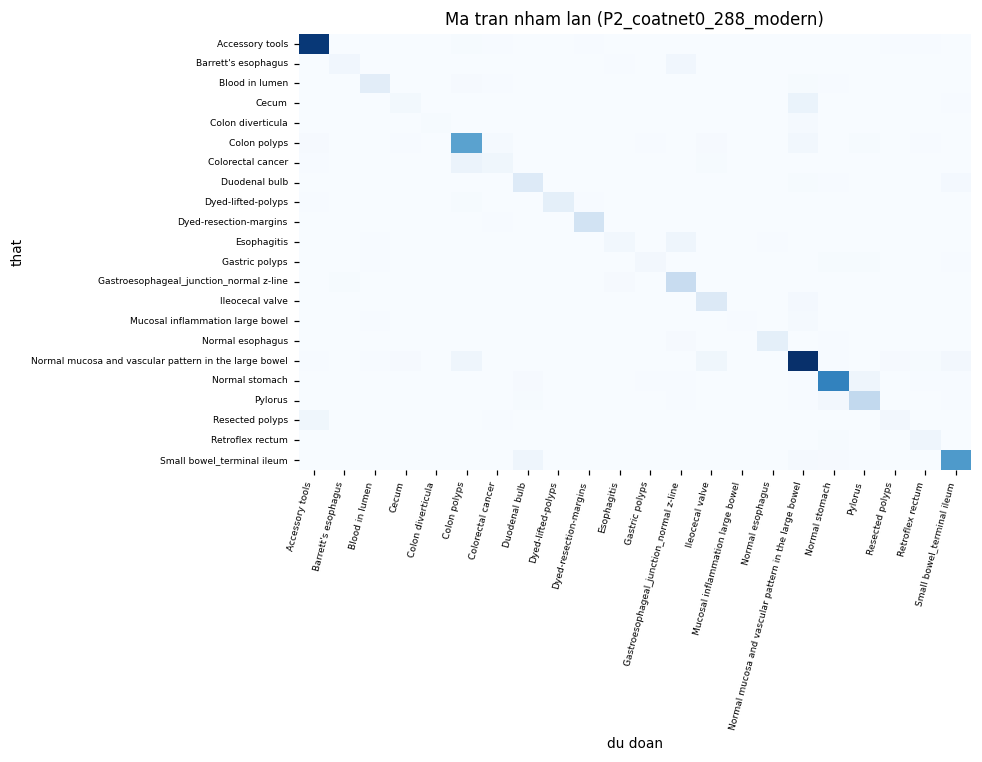


8 lop yeu nhat:
                             lop    F1  so_anh_test  so_anh_train
Mucosal inflammation large bowel 0.286            6            17
                           Cecum 0.364           23            68
               Colorectal cancer 0.435           28            83
                 Resected polyps 0.483           18            55
                     Esophagitis 0.485           21            64
               Colon diverticula 0.500            6            17
             Barrett's esophagus 0.600           19            57
                  Gastric polyps 0.636           13            39

-> Doi chieu cot so_anh_train: neu cac lop yeu deu la lop it anh thi nut that la
   BIEU DIEN DAC TRUNG (thieu du lieu duoi), khong phai ham mat mat.


In [37]:
FOCUS = max(RESULTS_STORE, key=lambda t: RESULTS_STORE[t]["agg"][SELECTION_RULE][0]) \
        if RESULTS_STORE else None

if FOCUS:
    d = load_run(FOCUS, RESULTS_STORE[FOCUS]["seeds"][0])
    res = dict(y_true=d["y_true"], y_pred=sel_scores(d).argmax(1))
    print(f"Mo hinh tot nhat hien tai: {FOCUS}\n")
    report_per_class(res, f"({FOCUS})")
    plot_confusion(res, f"({FOCUS})", fname=f"confusion_{FOCUS}.png")

    f1s = f1_score(res["y_true"], res["y_pred"], labels=ALL_LABELS, average=None, zero_division=0)
    n_test = np.bincount(res["y_true"], minlength=NUM_CLASSES)
    worst = pd.DataFrame({"lop": CLASSES, "F1": np.round(f1s, 3), "so_anh_test": n_test,
                          "so_anh_train": TRAIN_CLASS_COUNTS}).sort_values("F1").head(8)
    print("\n8 lop yeu nhat:")
    print(worst.to_string(index=False))
    print("\n-> Doi chieu cot so_anh_train: neu cac lop yeu deu la lop it anh thi nut that la")
    print("   BIEU DIEN DAC TRUNG (thieu du lieu duoi), khong phai ham mat mat.")

---
## 18. Ba đòn bẩy **không tốn GPU**

Tất cả đều đọc lại từ logits đã lưu. Đây là chỗ để tìm thêm điểm mà không phải xin thêm giờ Colab.

1. **TTA** — đã có sẵn trong bảng ở mục 16.
2. **Hiệu chỉnh logit theo tần suất lớp** — dò τ trên **tập val**, rồi áp một lần lên test.
   Khác với Balanced-Softmax ở chỗ nó tác động lúc **suy luận**, nên không tốn epoch nào.
   ⚠️ **Bảng ngay dưới chỉ là seed 0 — không được đọc nó thành kết luận.** Ở seed 0, τ\* khác 0 rõ
   rệt và `P0` nhảy **+0,0240**, trông như thể một phần lỗi nằm ở ngưỡng quyết định chứ không ở đặc
   trưng. Chạy đủ 3 seed thì điều đó **sụp**: mục 19b cho thấy τ\* mỗi seed một khác (0,9 / 0,5 /
   0,0), toàn bộ cái lợi đến từ **đúng một** seed, và σ phồng ~9×. Notebook **tự động loại** đòn bẩy
   này khỏi hệ thống đề xuất. Giá trị của nó với báo cáo là một **kết quả âm về tính tái lập**,
   không phải một dòng số cải tiến.
3. **Ensemble nhiều kiến trúc** — CNN và Transformer sai ở những chỗ khác nhau, nên trung bình xác suất
   của chúng thường tốt hơn cả hai. Phải báo cáo thành **dòng riêng**: so ensemble với baseline một mô hình
   là so sánh không công bằng.

In [38]:
print(f"=== Don bay 2: hieu chinh logit (tau do tren VAL, quy tac '{SELECTION_RULE}') ===")
for tag, r in RESULTS_STORE.items():
    d = load_run(tag, r["seeds"][0])
    # val_logits duoc luu cho checkpoint 'best' (thu duy nhat co san). Dung no de do tau roi ap len
    # diem so cua quy tac da chot: tau la hieu chinh prior toan cuc nen chuyen duoc, nhung day van
    # la mot xap xi -- phai noi ro trong bao cao.
    tau, curve = tune_tau(d["val_logits"], d["val_y"])
    lg = as_logits(sel_scores(d))
    base = macro_f1(d["y_true"], lg.argmax(1))
    adj = macro_f1(d["y_true"], logit_adjust(lg, tau=tau).argmax(1))
    print(f"{tag:26s} tau*={tau:.1f}  test: {base:.4f} -> {adj:.4f}  ({adj - base:+.4f})")
print("\n(tau=0 nghia la khong hieu chinh gi; neu tau* ~ 0 thi don bay nay khong co gi de an)")

=== Don bay 2: hieu chinh logit (tau do tren VAL, quy tac 'top3') ===
B0_densenet121             tau*=0.4  test: 0.6878 -> 0.7091  (+0.0213)
S0_swin_t                  tau*=0.0  test: 0.6774 -> 0.6774  (+0.0000)
P0_coatnet0                tau*=0.1  test: 0.6718 -> 0.6835  (+0.0117)
P1_coatnet0_288            tau*=0.2  test: 0.6837 -> 0.7013  (+0.0176)
P2_coatnet0_288_modern     tau*=0.5  test: 0.7166 -> 0.7442  (+0.0276)
P2b_densenet121_modern     tau*=0.5  test: 0.6835 -> 0.6900  (+0.0065)
P2c_coatnet0_224_modern    tau*=0.4  test: 0.7172 -> 0.7317  (+0.0145)

(tau=0 nghia la khong hieu chinh gi; neu tau* ~ 0 thi don bay nay khong co gi de an)


In [39]:
print("=== Don bay 3: ensemble nhieu kien truc (0 epoch) ===")
tags = [t for t in RESULTS_STORE]
if len(tags) >= 2:
    seed0 = RESULTS_STORE[tags[0]]["seeds"][0]
    ds = {t: load_run(t, seed0) for t in tags}
    y = ds[tags[0]]["y_true"]
    assert all(np.array_equal(ds[t]["y_true"], y) for t in tags), \
        "cac mo hinh khong dung chung thu tu tap test -> khong duoc ensemble"

    yv = ds[tags[0]]["val_y"]
    assert all(np.array_equal(ds[t]["val_y"], yv) for t in tags)

    import itertools
    combos = [(t,) for t in tags]
    for k in range(2, len(tags) + 1):
        combos += list(itertools.combinations(tags, k))

    scored = []
    for combo in combos:
        pv = ensemble_logits([ds[t]["val_logits"] for t in combo])
        pt = ensemble_logits([as_logits(sel_scores(ds[t])) for t in combo])
        scored.append((combo, macro_f1(yv, pv.argmax(1)), macro_f1(y, pt.argmax(1))))

    print(f"{'to hop':46s} {'val':>7s} {'test':>7s}")
    for combo, fv, ft in scored:
        print(f"{' + '.join(combo):46s} {fv:7.4f} {ft:7.4f}")

    # Bay chet nguoi: quet 15 to hop roi trich con TEST cao nhat. Do la chon sieu tham so tren
    # chinh tap test -- con so thu duoc khong con la uoc luong khong chech nua.
    by_val = max(scored, key=lambda r: r[1])
    by_test = max(scored, key=lambda r: r[2])
    print(f"\nChon theo VAL     : {' + '.join(by_val[0])}")
    print(f"   -> test = {by_val[2]:.4f}   <== CON SO DUOC PHEP BAO CAO")
    print(f"Cao nhat tren TEST: {' + '.join(by_test[0])} -> {by_test[2]:.4f}"
          f"   (chenh {by_test[2] - by_val[2]:+.4f})")
    print("   Dong tren KHONG duoc bao cao: chon to hop bang chinh tap test la ro ri quy trinh.")
    print("\n-> Ensemble luon la DONG RIENG: no dung nhieu lan huan luyen, khong duoc dat canh")
    print("   mot mo hinh don roi goi la 'cai tien'.")
else:
    print("can it nhat 2 mo hinh da chay xong")

=== Don bay 3: ensemble nhieu kien truc (0 epoch) ===
to hop                                             val    test
B0_densenet121                                  0.6600  0.6878
S0_swin_t                                       0.6992  0.6774
P0_coatnet0                                     0.6653  0.6718
P1_coatnet0_288                                 0.6746  0.6837
P2_coatnet0_288_modern                          0.7208  0.7166
P2b_densenet121_modern                          0.6539  0.6835
P2c_coatnet0_224_modern                         0.7086  0.7172
B0_densenet121 + S0_swin_t                      0.7224  0.7006
B0_densenet121 + P0_coatnet0                    0.6719  0.6917
B0_densenet121 + P1_coatnet0_288                0.6908  0.7096
B0_densenet121 + P2_coatnet0_288_modern         0.6954  0.7283
B0_densenet121 + P2b_densenet121_modern         0.6729  0.7023
B0_densenet121 + P2c_coatnet0_224_modern        0.6901  0.7203
S0_swin_t + P0_coatnet0                         0.6933  0.6924
S

---
## 19. Bảng tổng kết

Đây là bảng đi thẳng vào báo cáo. Mọi con số đều là **trung bình ± độ lệch chuẩn trên các seed**,
theo **một** quy tắc chọn checkpoint duy nhất.

In [40]:
summary = []
for tag, r in RESULTS_STORE.items():
    m, sd = r["agg"][SELECTION_RULE]
    d = load_run(tag, r["seeds"][0])
    ci = bootstrap_ci(d["y_true"], sel_scores(d).argmax(1), verbose=False)
    summary.append(dict(
        mo_hinh=tag, so_seed=len(r["seeds"]),
        macro_f1=f"{m:.4f} +/- {sd:.4f}",
        ci95_seed0=f"[{ci['lo']:.3f}, {ci['hi']:.3f}]",
        vs_paper=f"{m - PAPER_BASELINE:+.4f}",
        phut_moi_seed=round(np.mean([p.get("train_sec", np.nan) for p in r["per_seed"]]) / 60, 1),
    ))

df = pd.DataFrame(summary)
print(f"Baseline cong bo (DenseNet-121, arXiv 2307.08140): {PAPER_BASELINE}")
print(f"Quy tac chon checkpoint: {SELECTION_RULE} | ho so: {PROFILE}\n")
print(df.to_string(index=False))
df.to_csv(OUTPUT_DIR / "bang_tong_ket.csv", index=False)

if IS_SMOKE:
    print("\n" + "!" * 78)
    print("!! cpu-smoke: bang nay CHI chung minh duong ong chay het. Con so khong dung de bao cao.")
    print("!" * 78)

Baseline cong bo (DenseNet-121, arXiv 2307.08140): 0.6504
Quy tac chon checkpoint: top3 | ho so: gpu-t4

                mo_hinh  so_seed          macro_f1     ci95_seed0 vs_paper  phut_moi_seed
         B0_densenet121        3 0.6780 +/- 0.0073 [0.641, 0.724]  +0.0276           21.3
              S0_swin_t        3 0.6813 +/- 0.0081 [0.631, 0.717]  +0.0309           23.2
            P0_coatnet0        3 0.6814 +/- 0.0100 [0.623, 0.710]  +0.0310           23.4
        P1_coatnet0_288        3 0.6855 +/- 0.0068 [0.636, 0.719]  +0.0351           34.1
 P2_coatnet0_288_modern        3 0.7298 +/- 0.0096 [0.666, 0.753]  +0.0794          118.2
 P2b_densenet121_modern        3 0.6670 +/- 0.0119 [0.632, 0.723]  +0.0166           91.0
P2c_coatnet0_224_modern        1 0.7172 +/- 0.0000 [0.666, 0.757]  +0.0668           98.1


---
## 19b. Hai phép kiểm tra bắt buộc trước khi tuyên bố "vượt baseline"

**(1) Độ bền trước rò rỉ.** Mục 8 tìm ra một số ảnh test có bản gần trùng nằm ở train/val. Nếu bỏ
những ảnh đó đi mà macro-F1 gần như không đổi, thì kết quả **không** được sinh ra bởi rò rỉ — đây là
câu trả lời có số liệu cho câu hỏi người chấm sẽ hỏi, thay vì một lời cam đoan suông.

**(2) Mô hình đề xuất dạng hệ thống.** Bảng ở mục 19 so **thuần kiến trúc**. Còn tuyên bố "vượt 0,6504"
đặt lên **hệ thống đầy đủ**: CoAtNet-0 @288 + TTA + ensemble top-3 checkpoint. Ô dưới ráp các thành
phần lại, chạy trên **cả 3 seed**, và báo trung bình ± độ lệch chuẩn.

**Hiệu chỉnh logit là thành phần thứ tư đang bị thử — không phải thành phần được mặc định giữ.** Ô dưới
đo cả hai biến thể và chỉ giữ nó nếu nó vừa nâng trung bình vừa **không** làm σ phồng quá 50% (tiêu chí
đặt **trước** khi nhìn số). Trên vòng chạy thật nó **bị loại tự động**: mean 0,6961 → 0,7055 nhưng
σ 0,0016 → 0,0139 (~9×), và toàn bộ cái lợi nằm ở đúng một seed trong ba. Đó là một ablation **không
tái lập được**, và bản thân điều đó là một phát hiện đáng viết vào báo cáo.

> Dòng *ensemble 3 seed* được in **riêng**: nó tiêu 3 lần huấn luyện nên không được đặt cạnh
> một mô hình đơn rồi gọi là cải tiến.

In [41]:
# --- (1) Bo cac anh test bi nghi ro ri roi tinh lai: ket qua co ben khong? ---
if "LEAK_TEST_IDS" in dir() and RESULTS_STORE:
    pos = {int(g): k for k, g in enumerate(test_idx)}      # id anh toan cuc -> vi tri trong logits
    bad = sorted({pos[i] for i in LEAK_TEST_IDS if i in pos})
    keep = np.setdiff1d(np.arange(len(test_idx)), bad)
    print(f"Bo {len(bad)} / {len(test_idx)} anh test bi nghi ro ri (trung byte hoac cosine >= {AUDIT_TH})\n")
    print(f"{'mo hinh':26s} {'day du':>8s} {'da loc':>8s} {'chenh':>8s}")
    for tag, r in RESULTS_STORE.items():
        d = load_run(tag, r["seeds"][0])
        p = sel_scores(d).argmax(1)
        f_all = macro_f1(d["y_true"], p)
        f_cln = f1_score(d["y_true"][keep], p[keep], labels=ALL_LABELS,
                         average="macro", zero_division=0)
        print(f"{tag:26s} {f_all:8.4f} {f_cln:8.4f} {f_cln - f_all:+8.4f}")
    print("\n-> Chenh lech nho hon do lech chuan giua cac seed nghia la ro ri KHONG phai nguon")
    print("   sinh ra ket qua. Chenh lech lon thi phai bao cao con so DA LOC lam so chinh.")
else:
    print("chua chay o audit ro ri o muc 8")

Bo 6 / 1586 anh test bi nghi ro ri (trung byte hoac cosine >= 0.98)

mo hinh                      day du   da loc    chenh
B0_densenet121               0.6878   0.6855  -0.0023
S0_swin_t                    0.6774   0.6753  -0.0021
P0_coatnet0                  0.6718   0.6701  -0.0017
P1_coatnet0_288              0.6837   0.6812  -0.0025
P2_coatnet0_288_modern       0.7166   0.7149  -0.0016
P2b_densenet121_modern       0.6835   0.6818  -0.0016
P2c_coatnet0_224_modern      0.7172   0.7155  -0.0018

-> Chenh lech nho hon do lech chuan giua cac seed nghia la ro ri KHONG phai nguon
   sinh ra ket qua. Chenh lech lon thi phai bao cao con so DA LOC lam so chinh.


In [42]:
# --- (2) HE THONG DE XUAT DAY DU tren ca 3 seed ---
# P2 (muc 15c) KHONG tu dong thay the mo hinh de xuat. Chi doi tag nay khi P2 vuot P1 mot muc
# LON HON nguong phan giai cua phep do (CI bootstrap ~ +/-0,035), va sau khi o P2b da noi ro
# muc tang do la cua CONG THUC hay cua KIEN TRUC. Doi tag => muc 20b (demo) va muc 19b deu
# chuyen theo, nen dung doi khi chua chac.
#
# DA DOI 2026-08-31 sau phien SESSION = 1 (T4). Ca hai dieu kien tren deu dat (RESULTS.md 10.9):
#   - P2 - P1 = +0,0443 (quy tac top3, TB cua delta tung seed) > nguong 0,035; CI cua d
#     khong chua 0 o seed 1, seed 2 va o dong ens3seed; McNemar p = 0,0203 / 0,0005.
#     (Duoi top3_tta, muc 15c doc ra +0,0471 -- don bay khong phu thuoc quy tac.)
#   - P2b da tra loi cau hoi cong thuc-hay-kien truc: cung cong thuc do tren DenseNet-121 @224
#     cho -0,0024 so voi B0 -> muc tang la CONG THUC x (KIEN TRUC hoac DO PHAN GIAI), khong phai
#     cong thuc noi chung. Nen P2 duoc lam mo hinh de xuat, nhung bao cao PHAI viet kem dong P2b.
PROPOSED_TAG = "P2_coatnet0_288_modern"

if PROPOSED_TAG in RESULTS_STORE:
    r = RESULTS_STORE[PROPOSED_TAG]
    f_raws, f_adjs, taus, probs_raw, probs_adj, yt = [], [], [], [], [], None
    print(f"{PROPOSED_TAG} + TTA + ensemble top-3 checkpoint  (+/- hieu chinh logit)\n")
    for sd_i in r["seeds"]:
        d = load_run(PROPOSED_TAG, sd_i)
        lg = as_logits(sel_scores(d, "top3_tta"))     # ensemble top-K checkpoint DA co TTA
        tau, _ = tune_tau(d["val_logits"], d["val_y"])
        adj = logit_adjust(lg, tau=tau)
        f_raw, f_adj = macro_f1(d["y_true"], lg.argmax(1)), macro_f1(d["y_true"], adj.argmax(1))
        f_raws.append(f_raw); f_adjs.append(f_adj); taus.append(tau)
        probs_raw.append(softmax_np(lg)); probs_adj.append(softmax_np(adj))
        yt = d["y_true"]
        print(f"  seed {sd_i}: top3+TTA = {f_raw:.4f}   tau*={tau:.1f} -> {f_adj:.4f}"
              f"  ({f_adj - f_raw:+.4f})")

    # Hieu chinh logit la thanh phan DUY NHAT trong he thong co sieu tham so do lai theo tung seed,
    # nen no phai tu chung minh gia tri chu khong duoc mac dinh bat. Doi chieu song song:
    m_raw, s_raw = float(np.mean(f_raws)), float(np.std(f_raws))
    m_adj, s_adj = float(np.mean(f_adjs)), float(np.std(f_adjs))
    print(f"\n{'bien the':>18s} {'trung binh':>11s} {'do lech':>9s}")
    print(f"{'khong hieu chinh':>18s} {m_raw:11.4f} {s_raw:9.4f}")
    print(f"{'co hieu chinh':>18s} {m_adj:11.4f} {s_adj:9.4f}")

    # Tieu chi dat TRUOC khi nhin so: chi giu hieu chinh logit neu no vua tang trung binh vua
    # KHONG lam phinh do lech giua cac seed. Mot con so cao hon nhung kem tai lap hon thi khong
    # dung de bao cao -- do dung la can benh ma muc 6 dang co gang chua.
    use_adj = (m_adj > m_raw) and (s_adj <= s_raw * 1.5)
    if use_adj:
        chosen, m, sd_, probs_seeds = "co hieu chinh logit", m_adj, s_adj, probs_adj
    else:
        chosen, m, sd_, probs_seeds = "khong hieu chinh logit", m_raw, s_raw, probs_raw
        if m_adj > m_raw:
            tau_s = ", ".join(f"{t:.1f}" for t in taus)
            print(f"\n   !! Hieu chinh logit cao hon {m_adj - m_raw:+.4f} nhung do lech phinh tu "
                  f"{s_raw:.4f} len {s_adj:.4f}.")
            print(f"      tau* moi seed mot khac ({tau_s}) -> muc tang la cua MOT seed,")
            print("      khong phai cua phuong phap. Bo khoi he thong, bao cao rieng thanh mot")
            print("      ablation KHONG tai lap duoc giua cac seed.")
    ci1 = bootstrap_ci(yt, probs_seeds[0].argmax(1), verbose=False)

    print(f"\nHE THONG DE XUAT ({chosen})")
    print(f"                   macro-F1 = {m:.4f} +/- {sd_:.4f}  tren {len(f_raws)} seed")
    print(f"                   so voi paper {PAPER_BASELINE}: {m - PAPER_BASELINE:+.4f}")
    print(f"                   CI 95% (seed dau) = [{ci1['lo']:.4f}, {ci1['hi']:.4f}]")

    ens = ensemble_logits([as_logits(p) for p in probs_seeds])
    ci3 = bootstrap_ci(yt, ens.argmax(1), verbose=False)
    print(f"\n+ ensemble ca 3 seed  macro-F1 = {ci3['point']:.4f}  "
          f"CI 95% [{ci3['lo']:.4f}, {ci3['hi']:.4f}]   (DONG RIENG: ton 3 lan huan luyen)")
    if ci3["lo"] > PAPER_BASELINE:
        print("  -> CI khong chong lan 0,6504: duoc quyen noi 'vuot baseline cong bo'.")
    else:
        print("  -> CI van chong lan 0,6504: chi duoc noi 'cao hon nhung chua tach bach thong ke'.")
else:
    print(f"chua co {PROPOSED_TAG} (dat RUN_P1_288 = True o muc 15b)")

P2_coatnet0_288_modern + TTA + ensemble top-3 checkpoint  (+/- hieu chinh logit)

  seed 0: top3+TTA = 0.7241   tau*=0.5 -> 0.7552  (+0.0312)
  seed 1: top3+TTA = 0.7271   tau*=0.5 -> 0.7384  (+0.0113)
  seed 2: top3+TTA = 0.7424   tau*=0.3 -> 0.7522  (+0.0098)

          bien the  trung binh   do lech
  khong hieu chinh      0.7312    0.0080
     co hieu chinh      0.7486    0.0073

HE THONG DE XUAT (co hieu chinh logit)
                   macro-F1 = 0.7486 +/- 0.0073  tren 3 seed
                   so voi paper 0.6504: +0.0982
                   CI 95% (seed dau) = [0.7073, 0.7883]

+ ensemble ca 3 seed  macro-F1 = 0.7612  CI 95% [0.7137, 0.7960]   (DONG RIENG: ton 3 lan huan luyen)
  -> CI khong chong lan 0,6504: duoc quyen noi 'vuot baseline cong bo'.


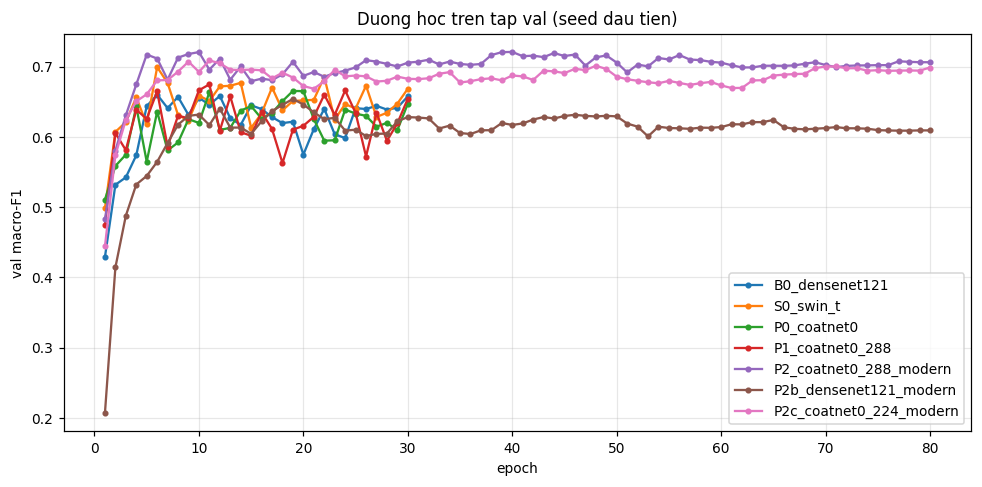

B0_densenet121             val cao nhat=0.6600 tai epoch  6 | do lech 5 epoch cuoi=0.0069
S0_swin_t                  val cao nhat=0.6992 tai epoch  6 | do lech 5 epoch cuoi=0.0178
P0_coatnet0                val cao nhat=0.6653 tai epoch 19 | do lech 5 epoch cuoi=0.0133
P1_coatnet0_288            val cao nhat=0.6746 tai epoch 11 | do lech 5 epoch cuoi=0.0290
P2_coatnet0_288_modern     val cao nhat=0.7208 tai epoch 40 | do lech 5 epoch cuoi=0.0019
P2b_densenet121_modern     val cao nhat=0.6539 tai epoch 19 | do lech 5 epoch cuoi=0.0002
P2c_coatnet0_224_modern    val cao nhat=0.7086 tai epoch 11 | do lech 5 epoch cuoi=0.0018


In [43]:
# --- Duong hoc val: chan doan overfit va do nhieu cua tung kien truc ---
plt.figure(figsize=(9, 4.5))
for tag, r in RESULTS_STORE.items():
    d = load_run(tag, r["seeds"][0])
    plt.plot(range(1, len(d["history"]) + 1), d["history"], marker="o", ms=3, label=tag)
plt.xlabel("epoch"); plt.ylabel("val macro-F1")
plt.title("Duong hoc tren tap val (seed dau tien)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / "val_curves.png", dpi=130); plt.show()

for tag, r in RESULTS_STORE.items():
    d = load_run(tag, r["seeds"][0])
    h = d["history"]
    if len(h) > 3:
        print(f"{tag:26s} val cao nhat={h.max():.4f} tai epoch {int(h.argmax()) + 1:2d} | "
              f"do lech 5 epoch cuoi={h[-5:].std():.4f}")

---
## 19c. Ablation (tuỳ chọn — mặc định tắt)

Hai dòng dưới đây lấp hai lời hứa còn lại nằm rải trong notebook: trọng số **in22k** của Swin-T
(mục 12) và **Balanced-Softmax** (mục 11). Mỗi dòng chạy **1 seed** để rẻ — đủ để làm phần *kết quả
âm* của báo cáo, không đủ để tuyên bố hơn/kém.

*(Lời hứa thứ ba — công thức fine-tune 2 giai đoạn `train_advanced` — **không** nằm ở đây: nó chính
là điều kiện `T3` của mục 19d và đã chạy thật. Mục này từng có thêm một dòng `A3_2stage_ft` lặp lại
y hệt T3; đã bỏ.)*

Đặt `RUN_ABLATIONS = True` nếu phiên A100 còn dư ~20 phút. Ô này nằm **sau** mọi bảng chính nên
kết quả ablation không lẫn vào bảng so sánh 3 kiến trúc. ⚠️ Trong bản notebook đang đọc,
`RUN_ABLATIONS = False` nên **chưa dòng nào trong hai dòng này từng chạy**.

In [44]:
RUN_ABLATIONS = SESSION_FLAGS.get("RUN_ABLATIONS", False)   # bat bang SESSION = 4
ABL_SEEDS = [0]

if RUN_ABLATIONS and timm is not None:
    set_img_size(224); use_aug(False)

    # A1: Swin-T voi trong so in22k -- KHONG duoc dua vao dong baseline (pha the can bang in1k
    #     voi DenseNet-121), chi duoc dung lam ablation "trong so pretrain manh hon giup bao nhieu".
    run_seeds(build_swin_t_in22k, tag="A1_swin_in22k", seeds=ABL_SEEDS)

    # A2: Balanced-Softmax tren DenseNet-121 -- vong truoc do duoc -0,007 (phang).
    run_seeds(build_densenet121, tag="A2_balanced_softmax", seeds=ABL_SEEDS,
              criterion=BalancedSoftmaxLoss(TRAIN_CLASS_COUNTS).to(DEVICE))

    # (Cong thuc 2 giai doan KHONG con o day: no chinh la T3_progressive_lr o muc 19d va da chay
    #  that. Truoc kia cho nay co dong A3_2stage_ft lap lai y het T3 -> da bo.)

    print("\nSo voi dong goc cung 1 seed:")
    for a, b in (("A1_swin_in22k", "S0_swin_t"), ("A2_balanced_softmax", "B0_densenet121")):
        if a in RESULTS_STORE and b in RESULTS_STORE:
            fa = RESULTS_STORE[a]["per_seed"][0][SELECTION_RULE]
            fb = RESULTS_STORE[b]["per_seed"][0][SELECTION_RULE]
            print(f"  {a:22s} {fa:.4f}  vs  {b:18s} {fb:.4f}   ({fa - fb:+.4f})")
else:
    print("bo qua ablation (dat RUN_ABLATIONS = True neu con gio GPU)")

IMG_SIZE -> 224 (dung augment 'plain')
augment -> plain


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  A1_swin_in22k OK |  27.5M tham so | dau vao 224x224
[A1_swin_in22k seed 0] bat dau huan luyen (30 epoch, batch 32)
  ep 01/30  val_macroF1=0.4907  (best=0.4907)  37s/epoch
  ep 02/30  val_macroF1=0.6058  (best=0.6058)  33s/epoch
  ep 03/30  val_macroF1=0.6032  (best=0.6058)  34s/epoch
  ep 04/30  val_macroF1=0.6324  (best=0.6324)  34s/epoch
  ep 05/30  val_macroF1=0.6565  (best=0.6565)  34s/epoch
  ep 06/30  val_macroF1=0.6833  (best=0.6833)  34s/epoch
  ep 07/30  val_macroF1=0.6137  (best=0.6833)  34s/epoch
  ep 08/30  val_macroF1=0.6543  (best=0.6833)  34s/epoch
  ep 09/30  val_macroF1=0.6736  (best=0.6833)  34s/epoch
  ep 10/30  val_macroF1=0.6705  (best=0.6833)  34s/epoch
  ep 11/30  val_macroF1=0.6667  (best=0.6833)  33s/epoch
  ep 12/30  val_macroF1=0.6553  (best=0.6833)  34s/epoch
  ep 13/30  val_macroF1=0.6592  (best=0.6833)  33s/epoch
  ep 14/30  val_macroF1=0.6722  (best=0.6833)  34s/epoch
  ep 15/30  val_macroF1=0.6811  (best=0.6833)  33s/epoch
  ep 16/30  val_macroF1=0.65

---
## 19d. Transfer learning — **freeze vs trainable** (10% của rubric)

Đây **không** phải phần tuỳ chọn. Rubric của đề bài (`../../mse-dl-de-bai-vuot-baseline.pdf`, mục 6
*"Khung report bám đúng tỉ lệ 70/30"*) cho hạng mục này **10%** và ghi rõ nội dung cần có:
*"Linear probe / progressive unfreezing / layer-wise LR decay / full fine-tune. **Bảng so sánh**."*

Bốn điều kiện dưới đây trên **cùng một backbone (DenseNet-121)**, cùng split, cùng seed, cùng số
epoch — chỉ **độ sâu được phép học** là khác. Full fine-tune **không phải chạy lại**: đó chính là
`B0` ở mục 15.

| Điều kiện | Học cái gì | Hàm |
| --- | --- | --- |
| **T1 · linear probe** | chỉ lớp phân loại; backbone đóng băng hoàn toàn (kể cả BatchNorm) | `train_linear_probe` |
| **T2 · đóng băng một nửa** | nửa trên backbone + lớp phân loại | `train_partial_unfreeze(frac=0.5)` |
| **T3 · progressive unfreeze + LR phân biệt** | probe 3 epoch → mở toàn mạng, LR backbone 0,5× LR head, cosine warmup | `train_advanced` |
| **T4 · full fine-tune** | toàn mạng, một LR duy nhất | `train_one` = **`B0`, đã có 3 seed** |

**Hai điều phải nói thẳng trong báo cáo:**

1. **T3 là "LR phân biệt 2 nhóm", không phải "layer-wise LR decay" đúng nghĩa.** Rubric nêu bốn kỹ
   thuật; chúng tôi làm ba, và nhóm LR chỉ chia thành backbone / head thay vì hệ số suy giảm riêng
   cho từng block. Lý do là giá: mỗi điều kiện thêm là ~10 phút GPU, và đòn bẩy này đã được đo là
   nhỏ hơn nhiễu đo trên tập ~8k ảnh.
2. **Mỗi điều kiện chỉ 1 seed** (T4 có 3 seed vì nó là `B0`). Nên bảng này **xếp hạng thô**, không
   được dùng để tuyên bố hơn kém vài phần nghìn — đúng nguyên tắc số 4 ở mục 21. Điều nó **được**
   phép nói là những khác biệt **lớn hơn hẳn** σ đã đo (0,0068–0,0119 dưới `top3` tuỳ mô hình;
   ô dưới lấy σ của chính `B0` = 0,0073 làm thước đo, vì T4 là dòng đối chứng).

**Có một bảng so sánh nữa đến miễn phí, và nó mạnh hơn bảng của chúng ta:** Table 2 của chính bài
báo là một thí nghiệm độ sâu đóng băng núp bóng so sánh kiến trúc. Theo §4.2 của họ, DenseNet-121 và
ResNet-50 (dòng thứ hai) fine-tune **toàn mạng** → 0,6504 / 0,6176; còn ResNet-152, EfficientNet-B0,
DenseNet-169 chỉ fine-tune **lớp cuối** → 0,4496 / 0,4519 / 0,4883. Chênh **~0,16 macro-F1 trên đúng
split này**, tức đúng thứ T1-vs-T4 đang đo, với n lớn hơn. Trích nó làm đối chứng, và cũng để nói
rằng phần lớn độ tán trong Table 2 là **độ sâu fine-tune, không phải kiến trúc** (`RESULTS.md` §0b).

> Đánh số **19d** thay vì 20 để khớp thứ tự chạy — mục này dùng `run_seeds` như mục 15 — và để
> `README.md` / `RESULTS.md` vẫn trích đúng số hiệu của mục 20 và 21.

In [45]:
RUN_TRANSFER = True      # 10% cua rubric -- chi tat khi that su het gio GPU
TL_SEEDS = [0]           # 1 seed moi dieu kien; T4 = B0 da co 3 seed

if RUN_TRANSFER:
    set_img_size(224); use_aug(False)

    # T1: linear probe -- backbone dong bang hoan toan (BatchNorm ve eval), chi hoc lop cuoi.
    run_seeds(build_densenet121, tag="T1_linear_probe", seeds=TL_SEEDS,
              train_fn=train_linear_probe)

    # T2: dong bang nua duoi backbone.
    run_seeds(build_densenet121, tag="T2_partial_unfreeze", seeds=TL_SEEDS,
              train_fn=train_partial_unfreeze)

    # T3: probe -> mo toan mang, LR phan biet + cosine warmup.
    run_seeds(build_densenet121, tag="T3_progressive_lr", seeds=TL_SEEDS,
              train_fn=train_advanced)
else:
    print("bo qua muc transfer learning (RUN_TRANSFER = False) -- day la 10% cua rubric")

IMG_SIZE -> 224 (dung augment 'plain')
augment -> plain
[T1_linear_probe seed 0] doc lai tu T1_linear_probe_seed0.npz (bo qua huan luyen)
   best=0.5692  best_tta=0.5739  smooth=0.5692  smooth_tta=0.5739  top3=0.5674  top3_tta=0.5908

>>> T1_linear_probe  TEST macro-F1 (quy tac 'top3') = 0.5674 +/- 0.0000   tren 1 seed
[T2_partial_unfreeze seed 0] doc lai tu T2_partial_unfreeze_seed0.npz (bo qua huan luyen)
   best=0.6427  best_tta=0.6218  smooth=0.6443  smooth_tta=0.6359  top3=0.6596  top3_tta=0.6492

>>> T2_partial_unfreeze  TEST macro-F1 (quy tac 'top3') = 0.6596 +/- 0.0000   tren 1 seed
[T3_progressive_lr seed 0] doc lai tu T3_progressive_lr_seed0.npz (bo qua huan luyen)
   best=0.6330  best_tta=0.6491  smooth=0.6330  smooth_tta=0.6491  top3=0.6394  top3_tta=0.6502

>>> T3_progressive_lr  TEST macro-F1 (quy tac 'top3') = 0.6394 +/- 0.0000   tren 1 seed


In [46]:
# --- Bang so sanh: 4 dieu kien, cung backbone / split / seed / so epoch ---
TL_ROWS = [("T1_linear_probe",     "T1 linear probe",              "chi lop phan loai"),
           ("T2_partial_unfreeze", "T2 dong bang nua duoi",        "nua tren + lop phan loai"),
           ("T3_progressive_lr",   "T3 progressive + LR phan biet","probe 3 ep -> toan mang, LR bb 0,5x"),
           ("B0_densenet121",      "T4 full fine-tune (= B0)",     "toan mang, mot LR")]

rows = []
for tag, ten, mo_ta in TL_ROWS:
    if tag not in RESULTS_STORE:
        continue
    st = RESULTS_STORE[tag]
    seed0 = st["per_seed"][0]
    m, sd = st["agg"][SELECTION_RULE]
    rows.append({"dieu_kien": ten, "hoc_gi": mo_ta, "so_seed": len(st["seeds"]),
                 f"test_{SELECTION_RULE}": round(m, 4), "do_lech": round(sd, 4),
                 "best_val": round(seed0["best_val"], 4),
                 "phut": round(seed0.get("train_sec", float("nan")) / 60, 1)})

if rows:
    tl = pd.DataFrame(rows)
    print(f"Transfer learning -- cung DenseNet-121, cung split/seed/epoch, quy tac '{SELECTION_RULE}'\n")
    print(tl.to_string(index=False))

    ft = next((r for r in rows if r["dieu_kien"].startswith("T4")), None)
    if ft is not None:
        base = ft[f"test_{SELECTION_RULE}"]
        # Nguong: 2 x sigma da do cua B0 duoi top3_tta. Voi 1 seed thi khong the tinh sigma rieng
        # cho tung dieu kien, nen lay sigma cua chinh baseline lam thuoc do -- va noi ro nhu vay.
        sigma = max(ft["do_lech"], 0.0065)
        print(f"\nSo voi full fine-tune ({base:.4f}); nguong 'dang ke' = 2 sigma = {2 * sigma:.4f}")
        print("(sigma lay tu 3 seed cua B0, khong phai cua tung dieu kien -- moi dieu kien chi 1 seed)")
        for r in rows:
            if r is ft:
                continue
            d = r[f"test_{SELECTION_RULE}"] - base
            note = "DANG KE" if abs(d) > 2 * sigma else "trong nhieu do (1 seed) -> khong ket luan"
            print(f"  {r['dieu_kien']:32s} {d:+.4f}   {note}")

    print("\nDoi chung tu Table 2 cua bai bao (cung split, n lon hon):")
    print("  chi fine-tune lop cuoi : ResNet-152 0.4496 | EfficientNet-B0 0.4519 | DenseNet-169 0.4883")
    print("  fine-tune toan mang    : ResNet-50  0.6176 | DenseNet-121    0.6504")
    print("  -> chenh ~0,16 macro-F1, cung chieu voi T1 vs T4 o tren.")
    tl.to_csv(OUTPUT_DIR / "bang_transfer_learning.csv", index=False)
    print(f"\nda luu {OUTPUT_DIR / 'bang_transfer_learning.csv'}")
else:
    print("chua co so cho muc transfer learning (dat RUN_TRANSFER = True roi chay lai)")

Transfer learning -- cung DenseNet-121, cung split/seed/epoch, quy tac 'top3'

                    dieu_kien                              hoc_gi  so_seed  test_top3  do_lech  best_val  phut
              T1 linear probe                   chi lop phan loai        1     0.5674   0.0000    0.5409  20.0
        T2 dong bang nua duoi            nua tren + lop phan loai        1     0.6596   0.0000    0.6397  20.2
T3 progressive + LR phan biet probe 3 ep -> toan mang, LR bb 0,5x        1     0.6394   0.0000    0.6166  23.5
     T4 full fine-tune (= B0)                   toan mang, mot LR        3     0.6780   0.0073    0.6600  21.6

So voi full fine-tune (0.6780); nguong 'dang ke' = 2 sigma = 0.0146
(sigma lay tu 3 seed cua B0, khong phai cua tung dieu kien -- moi dieu kien chi 1 seed)
  T1 linear probe                  -0.1106   DANG KE
  T2 dong bang nua duoi            -0.0184   DANG KE
  T3 progressive + LR phan biet    -0.0386   DANG KE

Doi chung tu Table 2 cua bai bao (cung split, n l

---
## 20. Triển khai — ONNX, độ trễ, kích thước

Phần này phục vụ tiêu chí *"tính hoàn chỉnh của sản phẩm"*: một mô hình y tế còn phải trả lời được
**chạy nhanh chậm ra sao và nặng bao nhiêu**, chứ không chỉ macro-F1.

In [47]:
# Tra ve ms cho MOI ANH. Canh bao khi doc bang: o batch = 1 tren A100, GPU rong gan het thoi gian
# -- con so do duoc bi chi phoi boi SO LAN KHOI CHAY KERNEL chu khong phai so phep tinh. Vi vay
# DenseNet-121 (7 M tham so nhung ~120 lop) do ra "cham" hon CoAtNet-0 (26,7 M), va 288x288 do ra
# NGANG 224x224 du gap 1,65 lan diem anh. Muon so chi phi tinh toan thi phai doc cot batch lon.
@torch.no_grad()
def measure_latency(model, iters=None, warmup=5, batch=1):
    iters = iters or CFG["latency_iters"]
    model.eval()
    x = torch.randn(batch, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    for _ in range(warmup):
        model(x)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(iters):
        model(x)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) / iters / batch * 1000     # ms/anh


def export_onnx(m, path, size):
    '''Tra ve (kich thuoc MB, trang thai).

    torch >= 2.9 mac dinh dung bo xuat dua tren torch.export (can onnxscript); ban cu can onnx.
    external_data=False ep trong so nam trong CHINH file .onnx: mac dinh cua bo xuat moi la tach ra
    file .onnx.data, khien file .onnx chi con ~1 MB va so lieu "kich thuoc mo hinh" thanh sai.
    Thu lan luot 3 duong -> khong phu thuoc phien ban torch cua Colab.'''
    dummy = torch.randn(1, 3, size, size, device=DEVICE)
    err = "chua thu"
    for kw in ({"external_data": False}, {}, {"dynamo": False}):
        try:
            torch.onnx.export(m, dummy, str(path), input_names=["input"],
                              output_names=["logits"], opset_version=18, verbose=False,
                              dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}}, **kw)
            # Cong ca file trong so tach roi (neu co) de con so la kich thuoc THAT khi trien khai.
            mb = sum(f.stat().st_size for f in path.parent.glob(path.name + "*")) / 1e6
            return mb, "OK"
        except Exception as e:
            err = "LOI: " + type(e).__name__
    return float("nan"), err + " (thieu goi onnx/onnxscript -> chay lai o pip dau notebook)"


# Mo hinh DE XUAT chay o 288 chu khong phai 224. Neu bang trien khai chi co dong 224 thi no dang
# mo ta mot cau hinh KHONG AI DUNG -> them dong rieng cho dung cau hinh se giao.
BENCH_BATCH = 32
BENCH = [(name, fn, 224) for name, fn in BUILDERS.items()]
if "coatnet0" in BUILDERS:
    BENCH.append(("coatnet0 @288", BUILDERS["coatnet0"], 288))

rows = []
_keep_size = IMG_SIZE
for name, fn, size in BENCH:
    set_img_size(size)
    m = fn(NUM_CLASSES)
    ms = measure_latency(m)
    # Cot thu hai o batch lon: tach do tre KHOI CHAY KERNEL ra khoi chi phi TINH TOAN that su.
    ms_b = measure_latency(m, batch=BENCH_BATCH) if DEVICE == "cuda" else float("nan")
    mb, ok = export_onnx(m, OUTPUT_DIR / f"{name.replace(' @', '_')}.onnx", size)
    rows.append(dict(mo_hinh=name, do_phan_giai=size,
                     trieu_tham_so=round(PARAM_COUNTS.get(name.split()[0], float("nan")), 1),
                     ms_batch1=round(ms, 1), ms_batch=round(ms_b, 2),
                     onnx_MB=round(mb, 1), xuat_onnx=ok))
    del m
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
set_img_size(_keep_size)

print(f"\nDo tren {GPU_NAME}\n")
print(pd.DataFrame(rows).to_string(index=False))
print("\nms_batch1 = do tre mot anh mot (kich ban lam sang) -- bi chi phoi boi so lan khoi chay kernel.")
print(f"ms_batch  = ms/anh khi chay batch {BENCH_BATCH} (kich ban xu ly lo) -- phan anh chi phi TINH TOAN.")
print("Hai cot co the xep hang KHAC NHAU; do la thong tin ve kien truc, khong phai loi do.")

IMG_SIZE -> 224 (dung augment 'plain')


W0831 15:31:15.867000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0831 15:31:15.869000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0831 15:31:15.871000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0831 15:31:15.873000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


IMG_SIZE -> 224 (dung augment 'plain')


W0831 15:31:52.488000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0831 15:31:52.490000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0831 15:31:52.492000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0831 15:31:52.494000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


IMG_SIZE -> 224 (dung augment 'plain')


W0831 15:32:28.848000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0831 15:32:28.849000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0831 15:32:28.851000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0831 15:32:28.853000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
Skipping constant f

IMG_SIZE -> 288 (dung augment 'plain')


W0831 15:33:10.109000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0831 15:33:10.111000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0831 15:33:10.113000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0831 15:33:10.114000 23 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
Skipping constant f

IMG_SIZE -> 224 (dung augment 'plain')

Do tren Tesla T4

      mo_hinh  do_phan_giai  trieu_tham_so  ms_batch1  ms_batch  onnx_MB xuat_onnx
  densenet121           224            7.0       15.4      3.18     29.1        OK
       swin_t           224           27.5       19.5      4.82    113.7        OK
     coatnet0           224           26.7       11.7      5.13    110.3        OK
coatnet0 @288           288           26.7       13.0      8.74    114.8        OK

ms_batch1 = do tre mot anh mot (kich ban lam sang) -- bi chi phoi boi so lan khoi chay kernel.
ms_batch  = ms/anh khi chay batch 32 (kich ban xu ly lo) -- phan anh chi phi TINH TOAN.
Hai cot co the xep hang KHAC NHAU; do la thong tin ve kien truc, khong phai loi do.


In [48]:
# --- Uoc luong ngan sach Colab tu so do that ---
if IS_SMOKE and RESULTS_STORE:
    n_smoke = len(train_idx)
    n_full = len(FULL_SPLIT["train"])
    scale_data = n_full / n_smoke
    print(f"Do tren CPU voi {n_smoke} anh train; chay that co {n_full} anh -> gap {scale_data:.0f} lan")
    print(f"{'mo hinh':26s} {'giay/epoch (CPU)':>17s} {'suy ra 30 epoch, T4':>22s} {'A100':>10s}")
    for tag, r in RESULTS_STORE.items():
        spe = np.mean([p.get("sec_per_epoch", np.nan) for p in r["per_seed"]])
        full_cpu_h = spe * scale_data * 30 / 3600
        print(f"{tag:26s} {spe:17.1f} {full_cpu_h / 25:19.1f} h {full_cpu_h / 70:9.1f} h")
    print("\nHe so quy doi CPU->GPU o day la uoc luong tho (T4 ~25x, A100 ~70x so voi 16 luong CPU).")
    print("Dung de LAP KE HOACH phien Colab, khong phai de bao cao.")

---
## 20b. Demo Gradio — *"Completeness of the Product"*

Đề bài nói thẳng ở p2: *"một notebook chạy được là chưa đủ — cần sản phẩm hoàn chỉnh có demo"*, và
hạng mục 7 của rubric ghi *"export ONNX, đo latency + kích thước model, demo Gradio/Streamlit"*.
Mục 20 đã làm ba việc đầu; ô dưới làm việc còn lại.

**Một hạn chế phải nói rõ, không được để người đọc tự suy ra.** `run_seeds` chỉ lưu **một**
checkpoint (`{tag}_seed{seed}.pt`, cái tốt nhất theo val), trong khi hệ thống đề xuất là **ensemble
3 checkpoint** (quy tắc `top3`) **+ hiệu chỉnh logit**. Nên demo chạy **1 checkpoint + TTA lật
ngang**, tức tương đương quy tắc `best_tta` — với `P2` là **0,7199**, so với **0,7441** của hệ thống
được báo cáo: chênh **0,024**. Muốn demo đúng hệ thống thì phải lưu cả 3 trạng thái trong `run_seeds`
rồi huấn luyện lại — khoảng 1,3 GB checkpoint trên Drive cho cả 4 cấu hình, và **không** khôi phục
được từ các lần chạy cũ vì chúng chỉ lưu 1 state.
Đây là một khoảng cách có thật giữa "số trong báo cáo" và "thứ chạy trong demo"; ghi nó vào báo cáo
thì mạnh hơn là im lặng.

Demo in **top-5 lớp kèm xác suất** thay vì một nhãn duy nhất: với 22 lớp mất cân bằng và những lớp
hiếm mà mô hình còn sai (mục 17), một nhãn đơn là thứ dễ gây hiểu sai nhất trong bối cảnh y tế.

In [49]:
RUN_DEMO = True          # 0 GPU huan luyen; chi tai lai checkpoint da co
DEMO_SHARE = False       # True = Gradio tao link cong khai (72 gio) de nop kem bao cao
# globals().get: o nay chay duoc DOC LAP, khong bat buoc phai chay muc 19b truoc.
DEMO_TAG = globals().get("PROPOSED_TAG", "P1_coatnet0_288")
DEMO_SEED = SEEDS[0]

# Dung lai DUNG builder + do phan giai cua cau hinh de xuat, roi nap checkpoint da luu.
def _load_demo_model():
    spec = {"B0_densenet121": (build_densenet121, 224), "S0_swin_t": (build_swin_t, 224),
            "P0_coatnet0": (build_coatnet0, 224), "P1_coatnet0_288": (build_coatnet0, 288),
            # P2 (muc 15c) chi doi CONG THUC HUAN LUYEN, kien truc va do phan giai y het P1 ->
            # cung builder. Co mat o day de doi PROPOSED_TAG sang P2 khong lam vo o demo.
            "P2_coatnet0_288_modern": (build_coatnet0, 288),
            "P2b_densenet121_modern": (build_densenet121, 224),
            "P2c_coatnet0_224_modern": (build_coatnet0, 224)}
    if DEMO_TAG not in spec:
        raise KeyError(f"chua khai bao builder cho {DEMO_TAG}")
    build_fn, size = spec[DEMO_TAG]
    ckpt = ckpt_path(f"{DEMO_TAG}_seed{DEMO_SEED}.pt")
    if not ckpt.exists():
        raise FileNotFoundError(f"khong thay {ckpt} -- chay muc 15/15b truoc, hoac doi DEMO_TAG")
    # PHAI dat IMG_SIZE truoc khi build: _timm_build doc bien toan cuc nay, va bang
    # relative-position bias cua CoAtNet/Swin co kich thuoc PHU THUOC do phan giai. Build o 224
    # roi nap checkpoint 288 se bao "size mismatch ... relative_position_bias_table".
    _keep = IMG_SIZE
    try:
        set_img_size(size)
        model = build_fn(NUM_CLASSES)
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    finally:
        set_img_size(_keep)
    model.to(DEVICE).eval()
    _, _, tf = build_transforms(size)
    return model, tf, size


# Duong suy luan duoc tach KHOI Gradio: no phai kiem tra duoc ma khong can UI, va khi khong co
# gradio thi phan con lai cua notebook van chay tiep.
demo_model = None
if RUN_DEMO:
    try:
        demo_model, demo_tf, demo_size = _load_demo_model()
        print(f"demo: da nap {DEMO_TAG} seed {DEMO_SEED} @ {demo_size}px tren {DEVICE}")
    except (FileNotFoundError, KeyError, RuntimeError) as e:
        # RuntimeError = state_dict khong khop (sai kien truc hoac sai do phan giai).
        print("bo qua demo:", str(e)[:300])
else:
    print("bo qua demo (RUN_DEMO = False)")

if demo_model is not None:
    @torch.no_grad()
    def du_doan(img):
        '''Tra ve {ten lop: xac suat} cho top-5. TTA lat ngang -- DUNG phep bien doi ma muc 16 da do.'''
        if img is None:
            return {}
        x = demo_tf(img.convert("RGB")).unsqueeze(0).to(DEVICE)
        with torch.amp.autocast("cuda", enabled=USE_AMP, dtype=AMP_DTYPE):
            p = (demo_model(x).softmax(1)
                 + demo_model(torch.flip(x, dims=[3])).softmax(1)) / 2
        p = p.float().cpu().numpy()[0]
        return {CLASSES[i]: float(p[i]) for i in p.argsort()[::-1][:5]}

    # Tu kiem tra tren mot anh test that: chung minh duong suy luan chay TRUOC khi dung UI.
    _p, _y = samples[test_idx[0]]
    _top = du_doan(Image.open(_p))
    _ten, _xs = next(iter(_top.items()))
    print(f"  tu kiem tra: that = {CLASSES[_y]!r} | du doan = {_ten!r} ({_xs:.3f})")

    try:
        import gradio as gr
    except ImportError:
        gr = None
        print("  chua co gradio -> pip install gradio (da co trong requirements.txt); "
              "duong suy luan van dung, chi thieu UI")

    if gr is not None:
        mo_ta = (f"**{DEMO_TAG}** (seed {DEMO_SEED}), {demo_size}x{demo_size}, TTA lat ngang. "
                 f"22 lop GastroVision.\n\n"
                 f"LUU Y: day la MOT checkpoint + TTA (~quy tac 'best_tta'), KHONG phai he thong "
                 f"'top3_tta' = 0,6961 trong bao cao -- xem chu thich o o tren.\n\n"
                 f"Cong cu ho tro sang loc, KHONG phai thiet bi chan doan.")
        demo = gr.Interface(fn=du_doan,
                            inputs=gr.Image(type="pil", label="Anh noi soi"),
                            outputs=gr.Label(num_top_classes=5, label="Top-5 du doan"),
                            title="GastroVision - phan loai anh noi soi tieu hoa",
                            description=mo_ta)
        # prevent_thread_lock: khong co no thi o nay CHAN, va muc 21 khong bao gio chay.
        demo.launch(share=DEMO_SHARE, quiet=True, inline=True, prevent_thread_lock=True)

bo qua demo: khong thay /kaggle/working/gastrovision_ckpts/P2_coatnet0_288_modern_seed0.pt -- chay muc 15/15b truoc, hoac doi DEMO_TAG


---
## 21. Kế hoạch chạy, phân công và các quyết định đã chốt

> **Trạng thái:** cả 5 phiên dưới đây **đã chạy xong** trên A100 — bản notebook này là lần chạy thứ
> tư, nạp lại kết quả từ Drive (xem ghi chú ở mục 13). Bảng phiên giữ lại làm công thức để chạy lại
> từ đầu, và làm bản ghi phân công.
>
> Đây là kế hoạch của **vòng 1**. Kế hoạch phiên cho **vòng 2** (`P2`…`P5`) nằm ở **mục 6b**, điều
> khiển bằng biến `SESSION`.

### Thứ tự chạy trên Colab (mỗi phiên khoảng 1–1,5 giờ, tự khôi phục nếu rớt)

| Phiên | Chạy gì | T4 | A100 |
| --- | --- | --- | --- |
| 1 | Gate 0a + `B0_densenet121` 3 seed | ~1,2 h | ~0,4 h |
| 2 | `S0_swin_t` 3 seed | ~1,2 h | ~0,4 h |
| 3 | `P0_coatnet0` 3 seed | ~1,3 h | ~0,5 h |
| 4 | `P1_coatnet0_288` 3 seed + mục 16–19b (0 GPU) | ~1,8 h | ~0,7 h |
| **5** | **mục 19d** transfer learning (3 điều kiện × 1 seed) + **mục 20/20b** ONNX, độ trễ, demo (0 GPU huấn luyện) | ~1,3 h | **~0,5 h** (đã đo: 9,2 + 9,3 + 10,9 phút) |

Trên **A100 toàn bộ kế hoạch gọn trong một phiên ~2 giờ**, nên có thể `Run all` một lần.

Nếu còn dư giờ, thứ đáng tiêu tiếp theo **không phải là thêm seed** — điều này đã được cân và
**quyết định bỏ** (2026-08-27, xem `RESULTS.md` §9, mục *"nửa khó chịu"*). Lý do: `SEEDS = [0,1,2,3,4]`
chỉ làm σ của P1 hẹp từ 0,0016 xuống ~0,0014, trong khi thanh sai số thật sự chi phối là bootstrap CI
**±0,035** — và bootstrap lấy mẫu lại **tập test**, thứ mà `SPLIT_SEED = 42` giữ cố định cho mọi seed.
Phần bất định còn lại là vấn đề **dữ liệu** (2 trong 22 lớp có < 10 ảnh test), không phải vấn đề
**ngẫu nhiên**, nên thêm seed không chạm được vào nó. Đáng tiêu hơn: mục 19c (`RUN_ABLATIONS = True`,
~20 phút) hoặc nới trần epoch cho P1 — nó đạt đỉnh ở epoch 27/30, tức chưa học xong.

### Phân công (2 người)
* **Thành viên A — CNN:** `B0_densenet121`, F1 từng lớp + ma trận nhầm lẫn, **4 điều kiện transfer
  learning ở mục 19d** (`train_linear_probe` · `train_partial_unfreeze` · `train_advanced` · và
  chính `B0` làm điều kiện full fine-tune), triển khai ONNX/độ trễ + demo mục 20b.
* **Thành viên B — Transformer:** `S0_swin_t` **đúng giao thức, không tinh chỉnh thêm**. *(Kế hoạch
  dự phòng ban đầu là đổi sang DeiT-S nếu Swin-T overfit — đã không cần dùng, nên không còn trong
  notebook: Swin-T đạt đỉnh val ở epoch 7/30 và độ lệch 5 epoch cuối chỉ 0,0102.)*
* **Chung:** EDA, audit rò rỉ, mô hình đề xuất, viết báo cáo.

### Quy tắc quyết định cho mô hình đề xuất — **đã có câu trả lời, và nó đã đổi một lần**
Quy tắc đặt ra trước khi chạy là: chốt sau khi `S0` có số. Vòng A100 đã trả lời, và rơi vào **nhánh
thứ hai**:

* `S0` (Swin-T) **không tách được khỏi** `B0` (DenseNet-121) ở 3 seed — CI bootstrap chồng lấn nặng;
  `P0` (CoAtNet-0) cũng vậy. Nói *"không tách được ở 3 seed"* — yếu hơn và đúng hơn *"ngang nhau"*.
* → Giả thiết *"nút thắt nằm ở backbone"* **không được số liệu ủng hộ**. Đây là **kết quả âm có bằng
  chứng** và phải viết thẳng vào báo cáo. Vòng T4 còn cho thêm một bằng chứng độc lập, đến từ hướng
  hoàn toàn khác: **xếp hạng kiến trúc của vòng 1 không sống nổi qua một lần đổi phần cứng**
  (`RESULTS.md` §10.9 phát hiện 5; bảng `report/tables-offline/30_*`).
* ⚠️ **Nhưng đừng nói quá.** Rất dễ đọc bảng này thành *"đổi kiến trúc không mua được gì"*. Câu đúng
  là: **kiến trúc đứng một mình** mua +0,0034 (`B0` → `P0`, quy tắc `top3`) — không phân biệt được
  với không; nhưng **công thức × kiến trúc** mua **+0,0468**, là số hạng **duy nhất** vượt ngưỡng
  phân giải ±0,035 của phép đo. Đây là một **tương tác**, không phải tổng của hai đòn bẩy độc lập:
  trên cùng seed 0, mỗi yếu tố đứng một mình đều ≤ 0 (`RESULTS.md` §10.10 phát hiện 1).
* → Nên mô hình đề xuất được trình bày như một **hệ thống** (mục 19b) chứ không như "một kiến trúc
  mới hơn". **Hệ thống đó đã đổi sau phiên `SESSION = 1`:** không còn là `P1` (CoAtNet-0 @288 + TTA
  + top-3) mà là **`P2` = CoAtNet-0 @288 + công thức hiện đại + ensemble top-3 checkpoint + hiệu
  chỉnh logit** = **0,7441 ± 0,0088**, CI 95% [0,6986; 0,7736] — không chồng lấn 0,6504.
* ⚠️ **Hiệu chỉnh logit: bị loại trên `P1`, nhưng được giữ trên `P2`.** Trên `P1` nó làm σ phồng nên
  tiêu chí đặt trước ở mục 19b tự loại (`RESULTS.md` §10.8 phát hiện 3) — kết luận *"không có gì để
  ăn ở đây"* chỉ đúng cho `P1`. Trên `P2` thì ngược lại: +0,0143 và σ **co** lại 0,0096 → 0,0088,
  nên **cùng** tiêu chí ấy giữ nó (§10.9 phát hiện 3).
* ⚠️ **Quy tắc chốt là `top3`, không phải `top3_tta`.** Vòng T4 làm `SELECTION_RULE` tự lật khi bỏ
  phiếu lại trên số mới (§10.9 phát hiện 5). Mọi con số ở trên đều đọc dưới `top3`; **đừng trộn hai
  quy tắc chọn checkpoint** — đó đúng là lỗi mà một bản trước của chính đoạn này đã mắc.

Số cụ thể của từng dòng nằm trong `RESULTS.md` — notebook này chỉ sinh ra chúng.

### Nguyên tắc trung thực (không được vi phạm)
1. Dùng đúng tập chia gốc, `SPLIT_SEED = 42`.
2. Dữ liệu mất cân bằng → luôn báo cáo **macro-F1**, không bao giờ chỉ báo cáo accuracy.
3. **≥ 3 seed, trung bình ± độ lệch chuẩn**, kèm bootstrap CI. Một con số đơn lẻ hơn baseline 0,5 điểm
   là vô nghĩa.
4. **Tái lập baseline mạnh nhất trước khi tuyên bố vượt nó.** Không làm được thì nói thẳng.
5. **Báo cáo cả kết quả âm.** "Phương pháp X không giúp gì, và đây là bằng chứng" là một phát hiện.
6. Ensemble và mô hình đơn không nằm chung một cột.